**Assignment 1**

**PART A**

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt

class DeterministicWarehouseEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.size = 6
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Tuple((spaces.Discrete(self.size), spaces.Discrete(self.size), spaces.Discrete(2)))
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.pickup = (1, 1)
        self.dropoff = (5, 5)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        self.carrying = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return (self.pos[0], self.pos[1], self.carrying)

    def step(self, action):
        x, y = self.pos

        # Define possible actions
        if action == 0:
            new_pos = (x, max(0, y - 1))
        elif action == 1:
            new_pos = (x, min(self.size - 1, y + 1))
        elif action == 2:
            new_pos = (max(0, x - 1), y)
        elif action == 3:
            new_pos = (min(self.size - 1, x + 1), y)
        elif action == 4 and self.pos == self.pickup and self.carrying == 0:
            self.carrying = 1
            return self._get_obs(), 25, False, False, {}
        elif action == 5 and self.pos == self.dropoff and self.carrying == 1:
            return self._get_obs(), 100, True, False, {}
        elif action in [4, 5]:
            return self._get_obs(), -5, False, False, {}

        # Check for obstacle
        if new_pos in self.obstacles:
            reward = -20
        else:
            self.pos = new_pos
            reward = -1

        return self._get_obs(), reward, False, False, {}

    def render(self):
        grid = np.zeros((self.size, self.size))
        for obs in self.obstacles:
            grid[obs] = -1
        grid[self.pickup] = 2
        grid[self.dropoff] = 3
        grid[self.pos] = 1

        plt.figure(figsize=(6,6))
        plt.imshow(grid, cmap='coolwarm', origin='upper')
        plt.xticks(range(self.size))
        plt.yticks(range(self.size))
        plt.grid(True, color='black', linewidth=0.5)
        plt.title("Deterministic Warehouse Environment")
        plt.colorbar()

        for i in range(self.size):
            for j in range(self.size):
                if grid[j, i] == -1:
                    plt.text(i, j, 'O', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 2:
                    plt.text(i, j, 'P', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 3:
                    plt.text(i, j, 'D', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 1:
                    plt.text(i, j, 'R', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

        plt.show()


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt

class StochasticWarehouseEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.size = 6
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Tuple((spaces.Discrete(self.size), spaces.Discrete(self.size), spaces.Discrete(2)))  # Position (x, y) + carrying status
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.pickup = (1, 1)
        self.dropoff = (5, 5)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        self.carrying = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return (self.pos[0], self.pos[1], self.carrying)

    def step(self, action):
        x, y = self.pos

        # Random event, 10% chance
        if random.random() < 0.1:
            return self._get_obs(), -1, False, False, {}
        # Define possible actions
        if action == 0:
            new_pos = (x, max(0, y - 1))
        elif action == 1:
            new_pos = (x, min(self.size - 1, y + 1))
        elif action == 2:
            new_pos = (max(0, x - 1), y)
        elif action == 3:
            new_pos = (min(self.size - 1, x + 1), y)
        elif action == 4 and self.pos == self.pickup and self.carrying == 0:
            self.carrying = 1
            return self._get_obs(), 25, False, False, {}
        elif action == 5 and self.pos == self.dropoff and self.carrying == 1:
            return self._get_obs(), 100, True, False, {}
        elif action in [4, 5]:
            return self._get_obs(), -5, False, False, {}

        # Check for obstacle
        if new_pos in self.obstacles:
            reward = -20
        else:
            self.pos = new_pos
            reward = -1

        return self._get_obs(), reward, False, False, {}

    def render(self):
        grid = np.zeros((self.size, self.size))
        for obs in self.obstacles:
            grid[obs] = -1
        grid[self.pickup] = 2
        grid[self.dropoff] = 3
        grid[self.pos] = 1

        plt.figure(figsize=(6,6))
        plt.imshow(grid, cmap='coolwarm', origin='upper')
        plt.xticks(range(self.size))
        plt.yticks(range(self.size))
        plt.grid(True, color='black', linewidth=0.5)
        plt.title("Stochastic Warehouse Environment")
        plt.colorbar()

        for i in range(self.size):
            for j in range(self.size):
                if grid[j, i] == -1:
                    plt.text(i, j, 'O', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 2:
                    plt.text(i, j, 'P', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 3:
                    plt.text(i, j, 'D', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 1:
                    plt.text(i, j, 'R', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

        plt.show()



Running Deterministic Environment
State: (0, 0, 0), Action: 2, Reward: -1


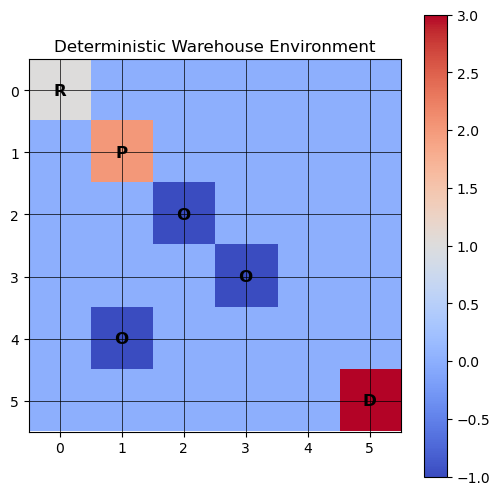

State: (0, 0, 0), Action: 2, Reward: -1


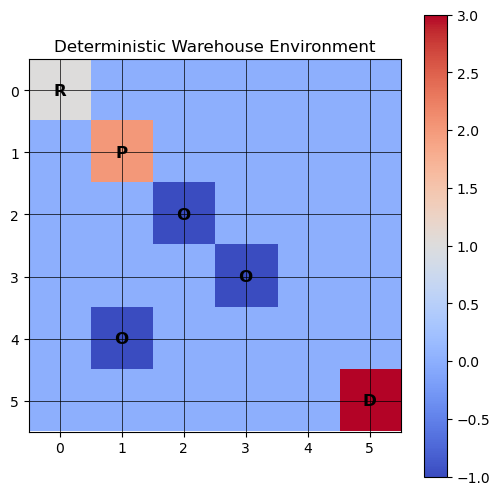

State: (0, 0, 0), Action: 0, Reward: -1


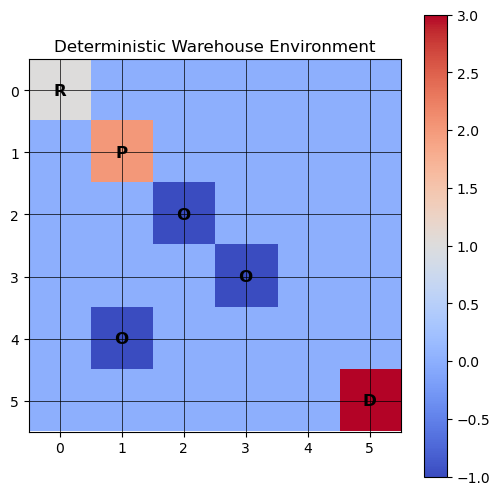

State: (0, 0, 0), Action: 2, Reward: -1


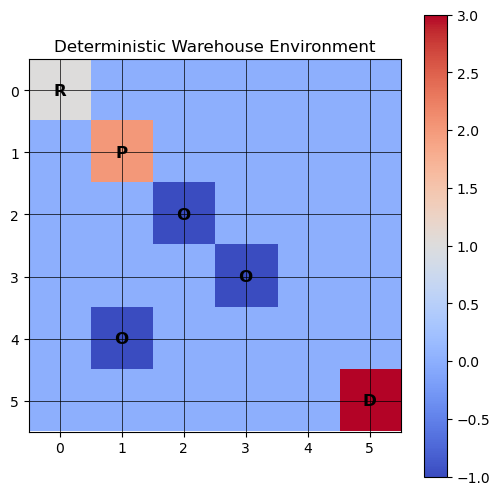

State: (0, 0, 0), Action: 2, Reward: -1


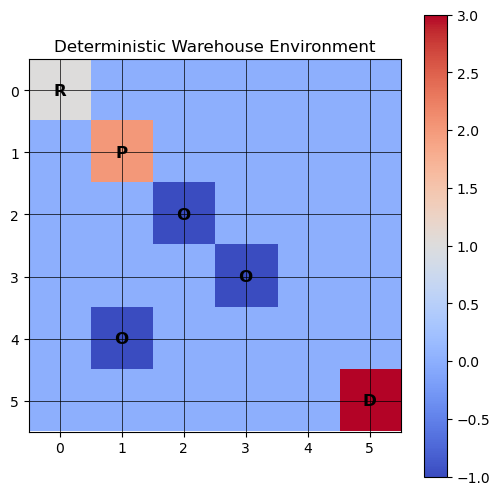

State: (0, 0, 0), Action: 2, Reward: -1


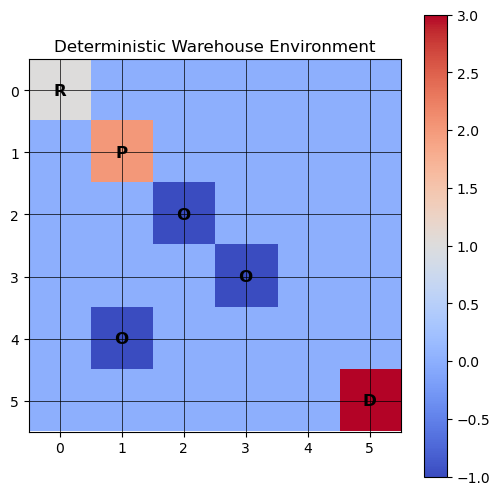

State: (0, 1, 0), Action: 1, Reward: -1


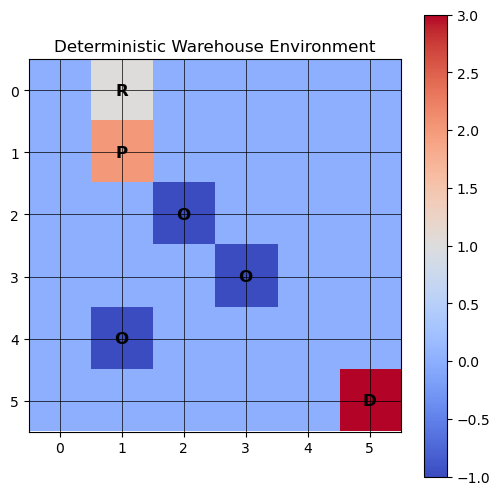

State: (0, 2, 0), Action: 1, Reward: -1


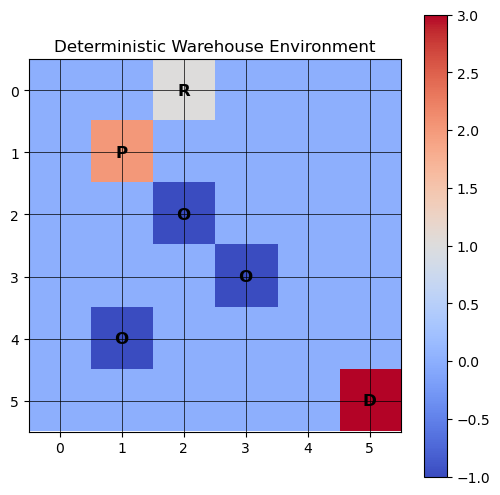

State: (0, 2, 0), Action: 2, Reward: -1


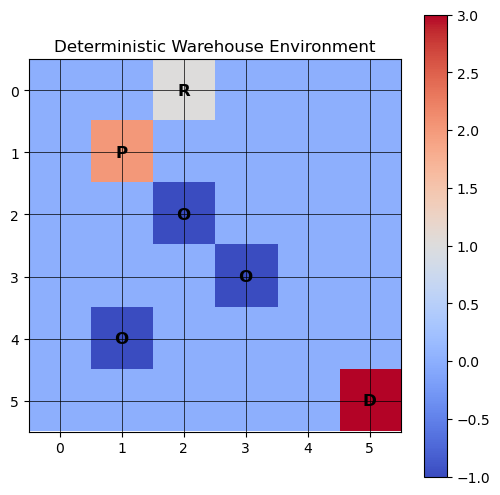

State: (1, 2, 0), Action: 3, Reward: -1


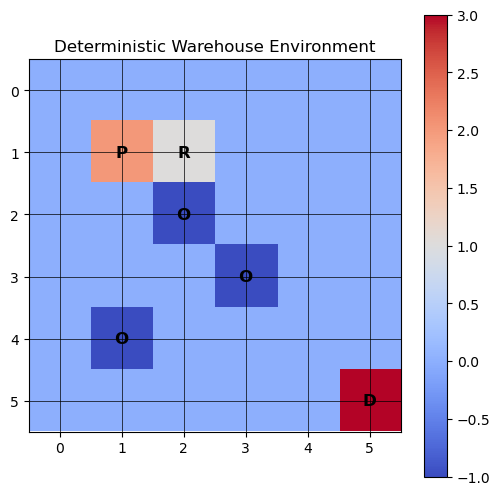

State: (1, 2, 0), Action: 3, Reward: -20


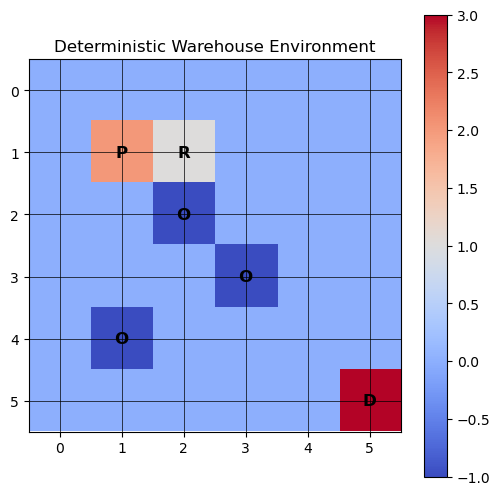

State: (1, 3, 0), Action: 1, Reward: -1


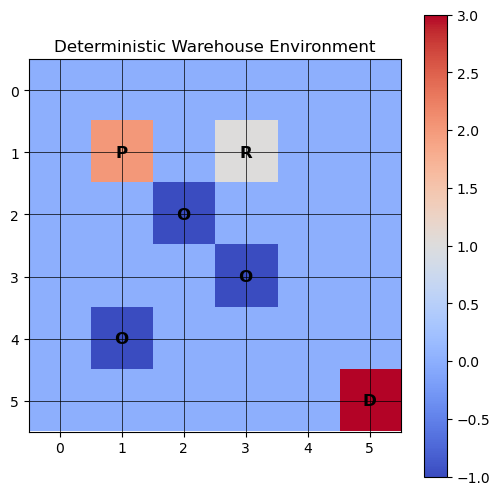

State: (1, 2, 0), Action: 0, Reward: -1


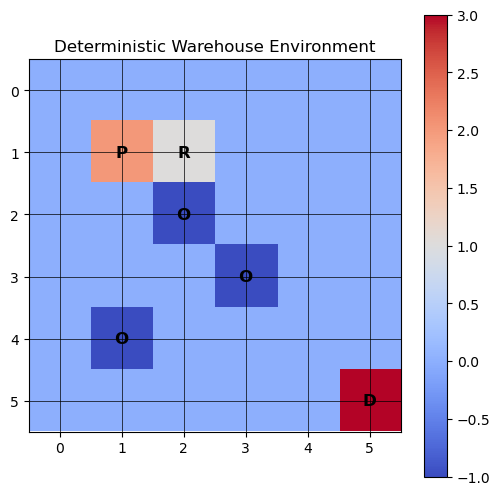

State: (1, 2, 0), Action: 3, Reward: -20


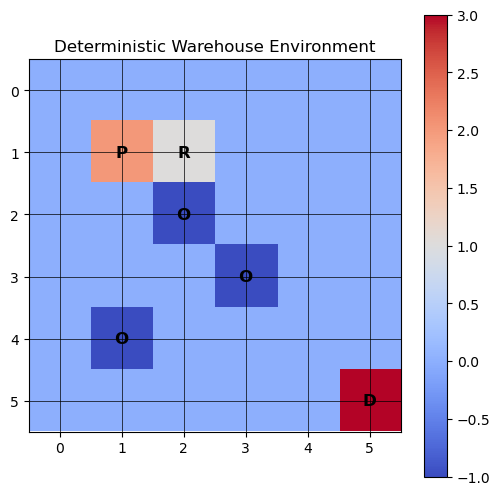

State: (1, 2, 0), Action: 3, Reward: -20


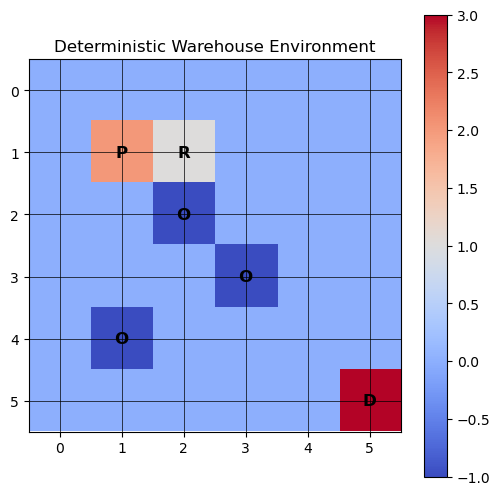

State: (1, 1, 0), Action: 0, Reward: -1


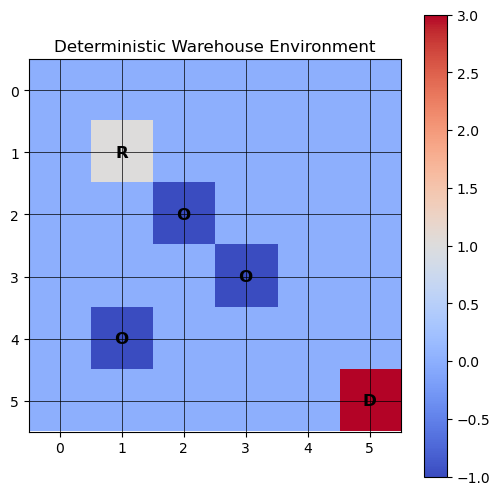

State: (1, 1, 1), Action: 4, Reward: 25


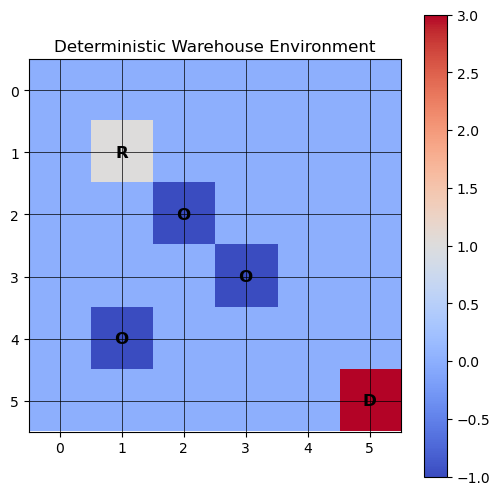

State: (1, 2, 1), Action: 1, Reward: -1


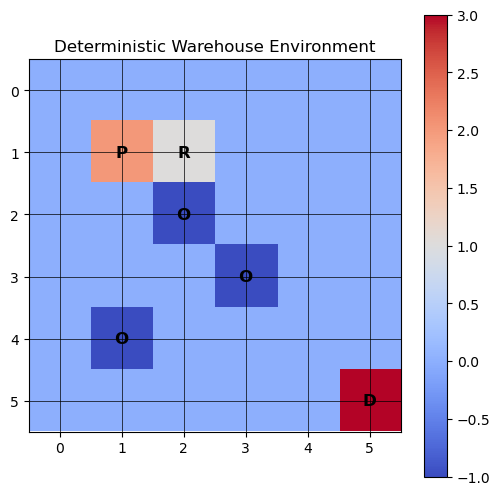

State: (1, 2, 1), Action: 3, Reward: -20


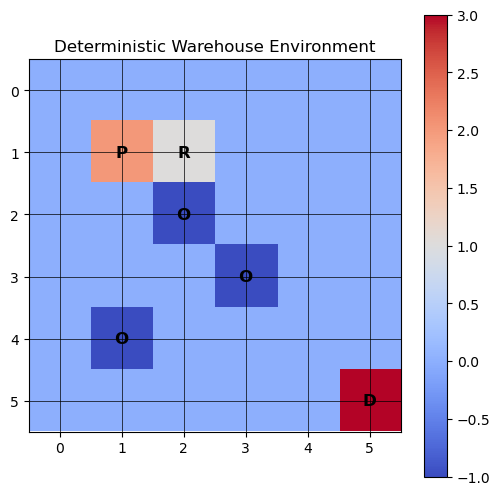

State: (0, 2, 1), Action: 2, Reward: -1


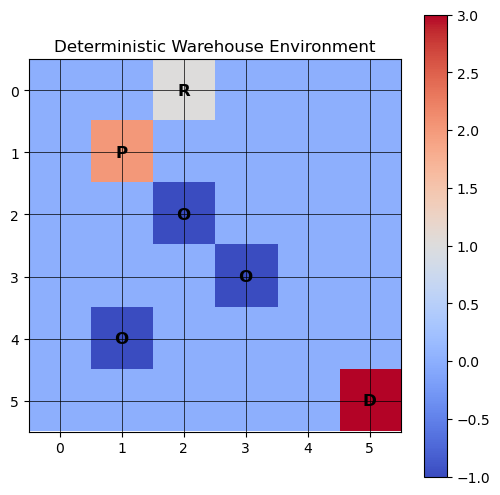

State: (0, 2, 1), Action: 2, Reward: -1


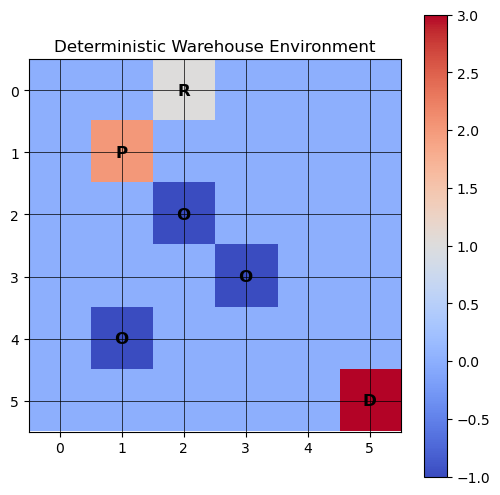

State: (0, 1, 1), Action: 0, Reward: -1


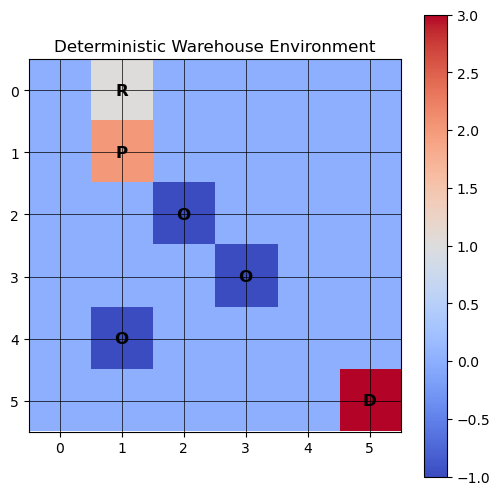

State: (0, 2, 1), Action: 1, Reward: -1


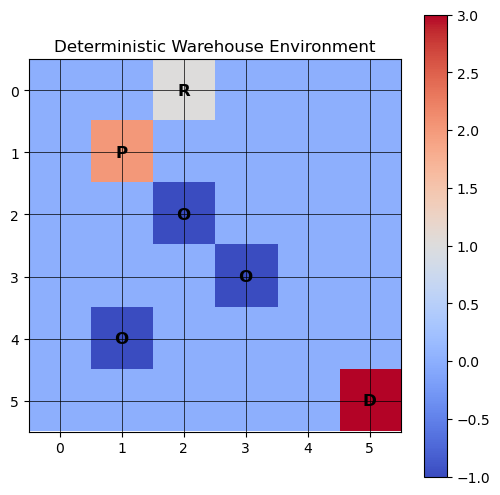

State: (1, 2, 1), Action: 3, Reward: -1


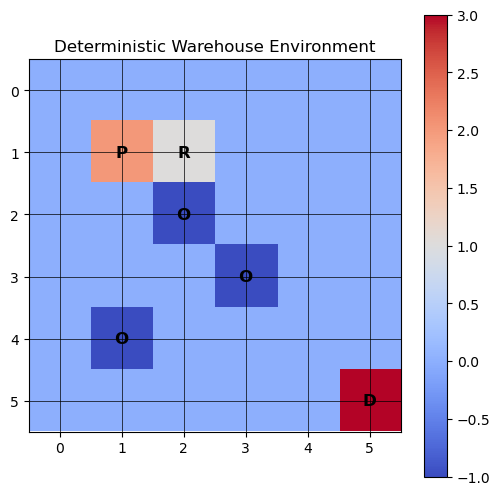

State: (1, 1, 1), Action: 0, Reward: -1


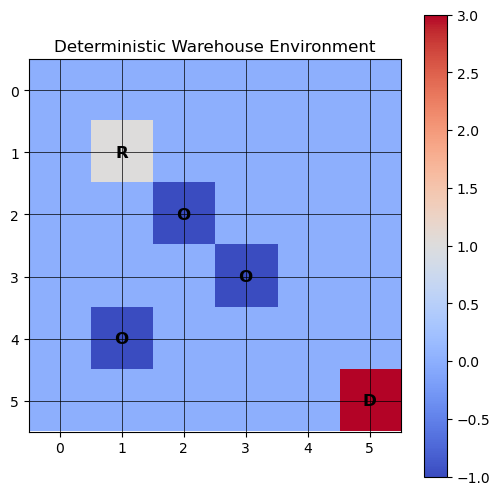

State: (1, 0, 1), Action: 0, Reward: -1


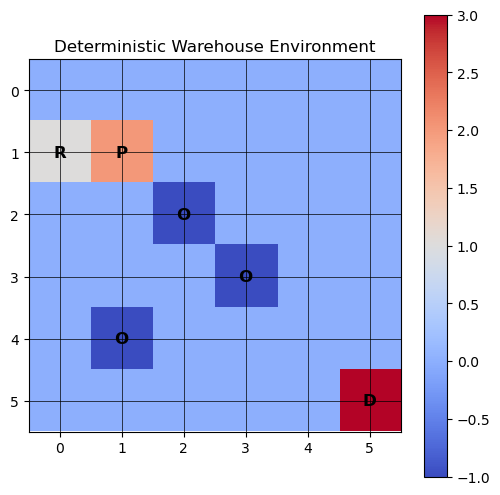

State: (1, 1, 1), Action: 1, Reward: -1


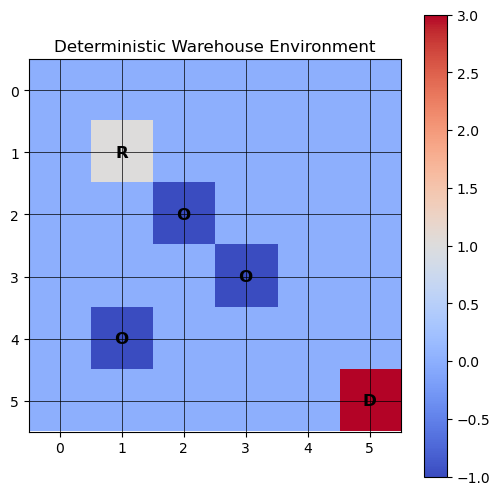

State: (1, 0, 1), Action: 0, Reward: -1


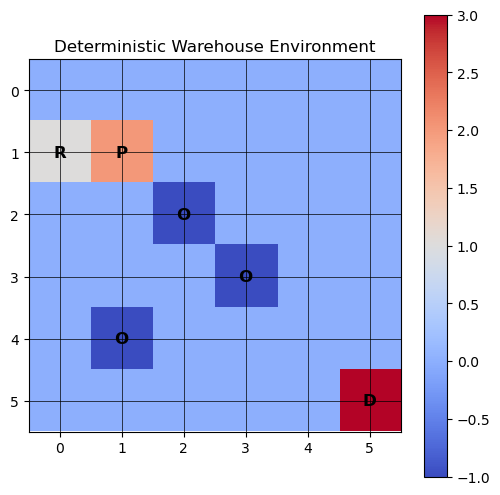

State: (1, 1, 1), Action: 1, Reward: -1


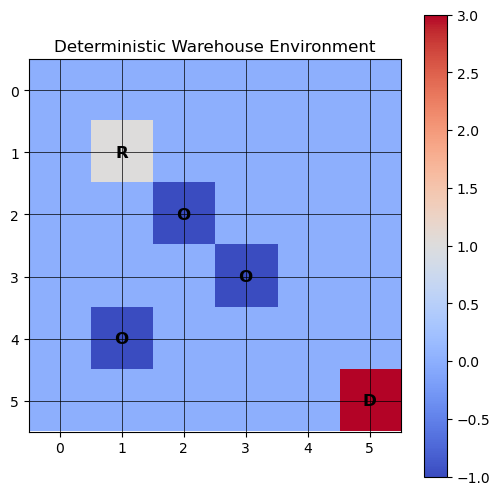

State: (1, 2, 1), Action: 1, Reward: -1


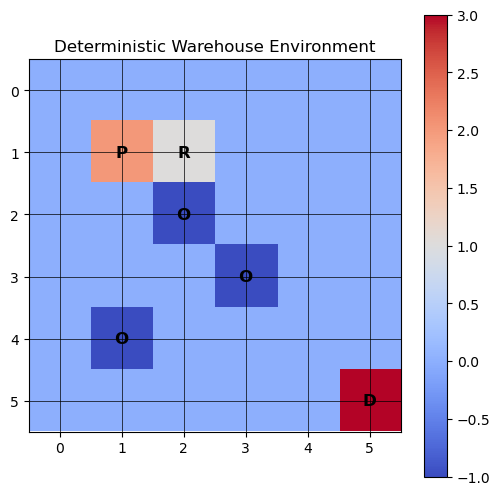

State: (1, 1, 1), Action: 0, Reward: -1


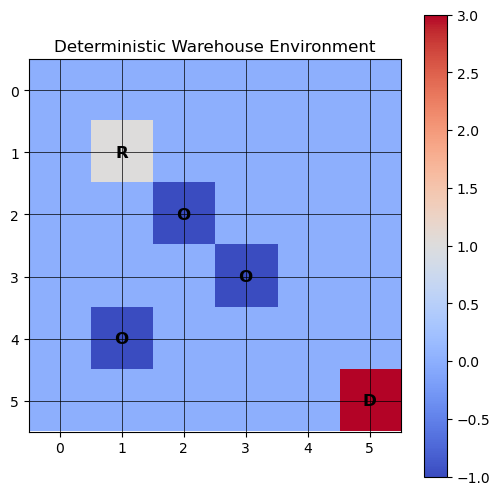

State: (2, 1, 1), Action: 3, Reward: -1


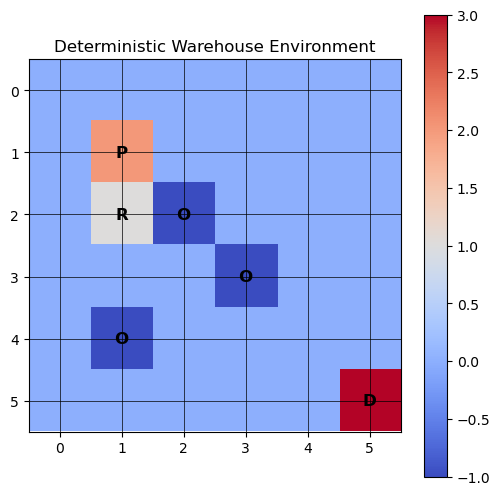

State: (2, 0, 1), Action: 0, Reward: -1


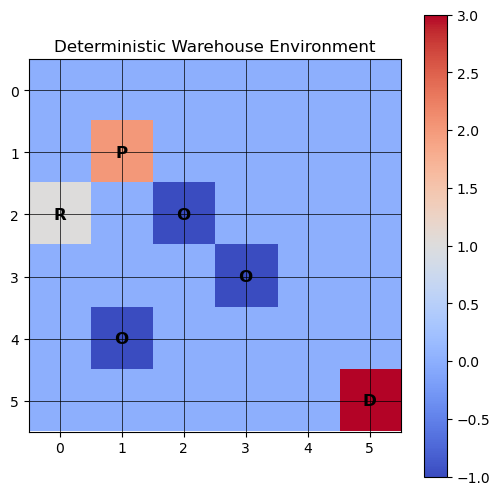

State: (2, 0, 1), Action: 0, Reward: -1


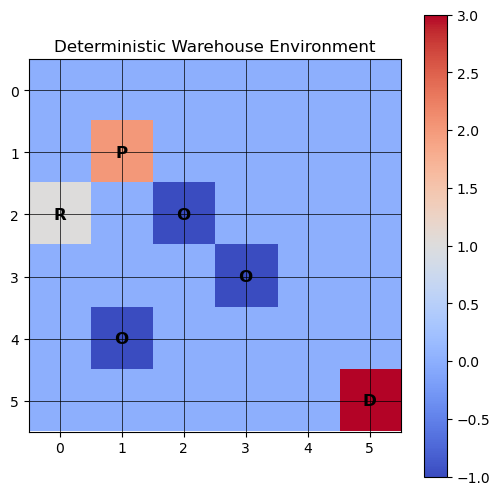

State: (3, 0, 1), Action: 3, Reward: -1


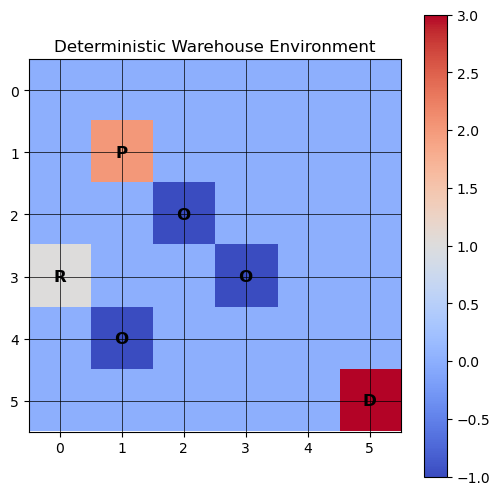

State: (2, 0, 1), Action: 2, Reward: -1


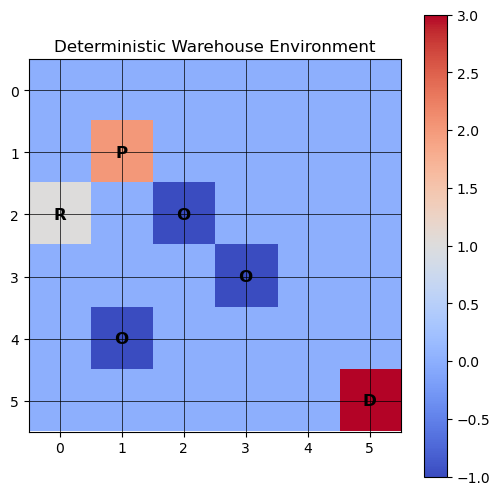

State: (3, 0, 1), Action: 3, Reward: -1


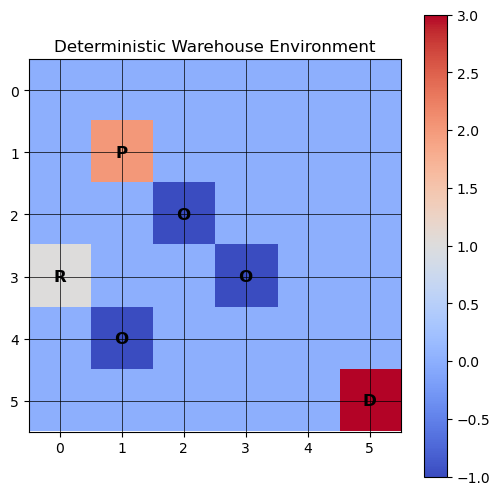

State: (2, 0, 1), Action: 2, Reward: -1


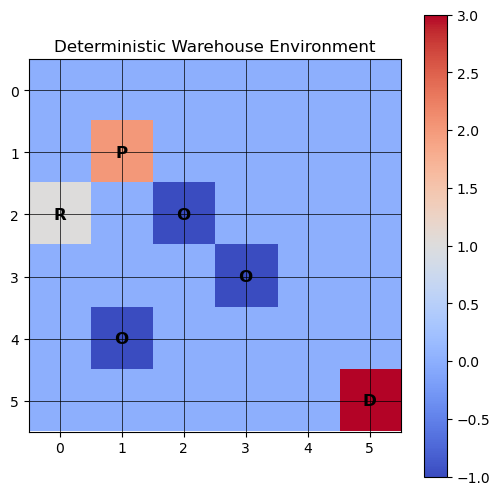

State: (1, 0, 1), Action: 2, Reward: -1


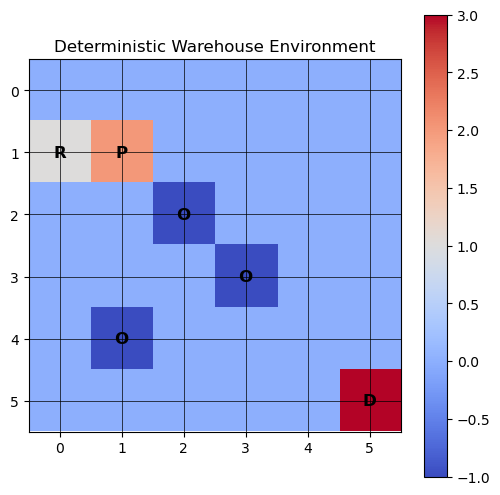

State: (0, 0, 1), Action: 2, Reward: -1


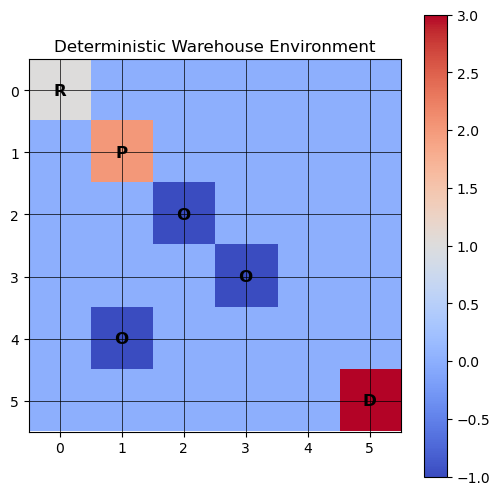

State: (1, 0, 1), Action: 3, Reward: -1


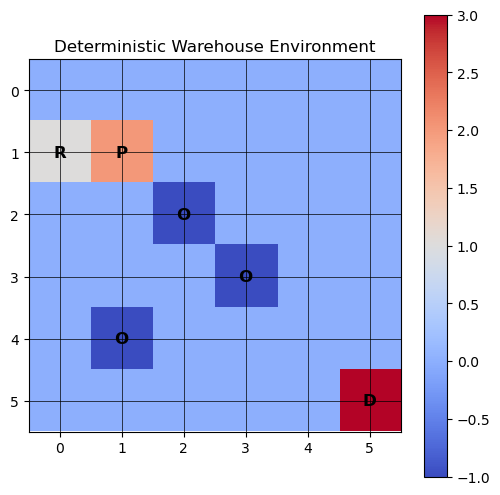

State: (2, 0, 1), Action: 3, Reward: -1


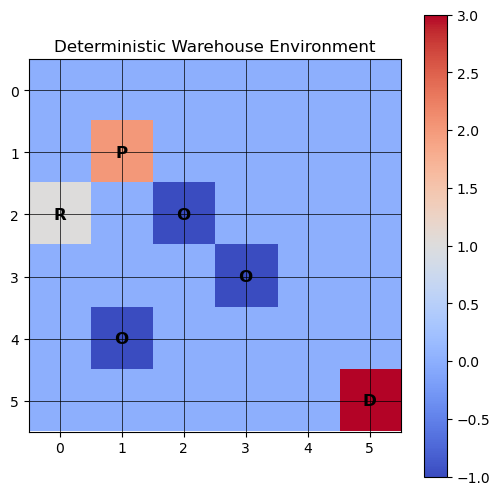

State: (3, 0, 1), Action: 3, Reward: -1


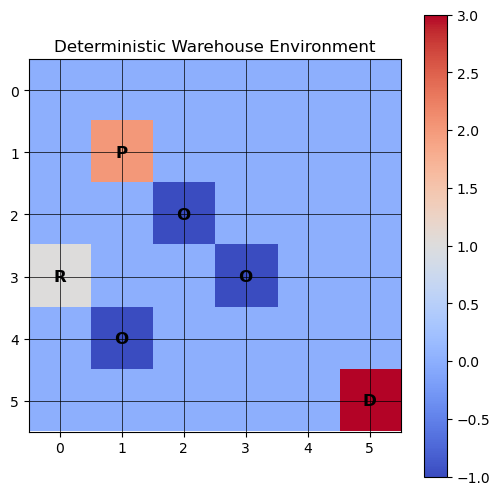

State: (4, 0, 1), Action: 3, Reward: -1


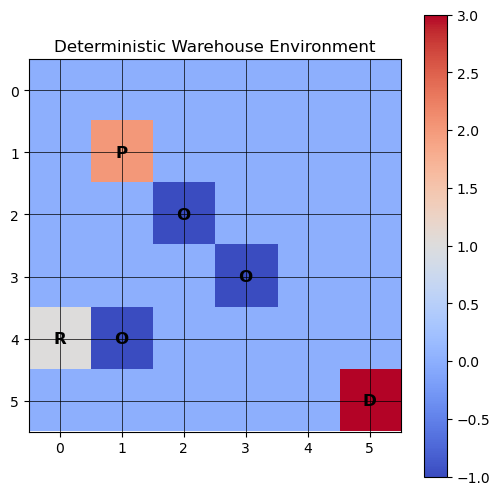

State: (5, 0, 1), Action: 3, Reward: -1


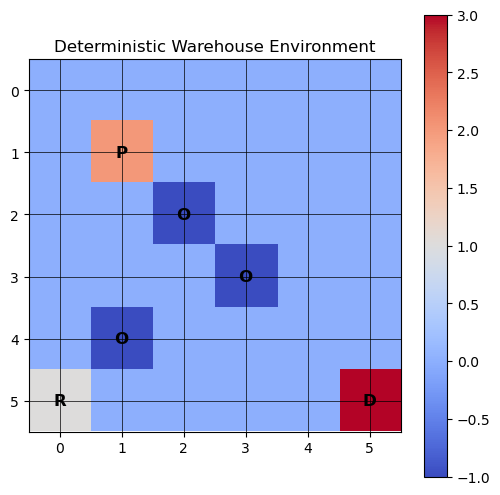

State: (5, 1, 1), Action: 1, Reward: -1


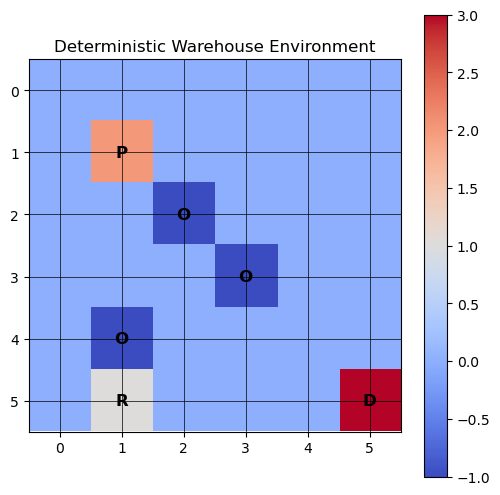

State: (5, 0, 1), Action: 0, Reward: -1


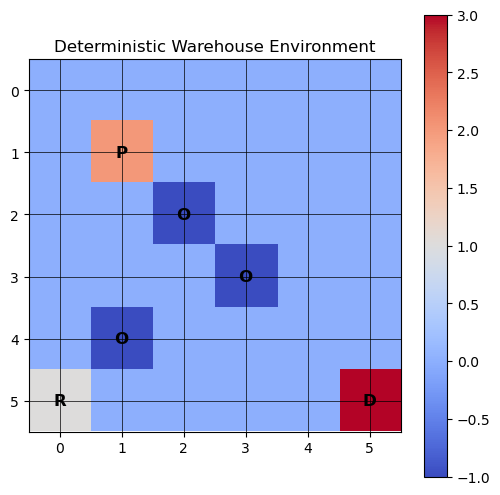

State: (5, 0, 1), Action: 3, Reward: -1


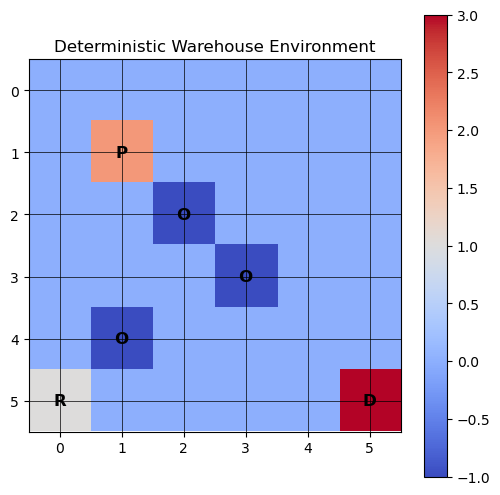

State: (4, 0, 1), Action: 2, Reward: -1


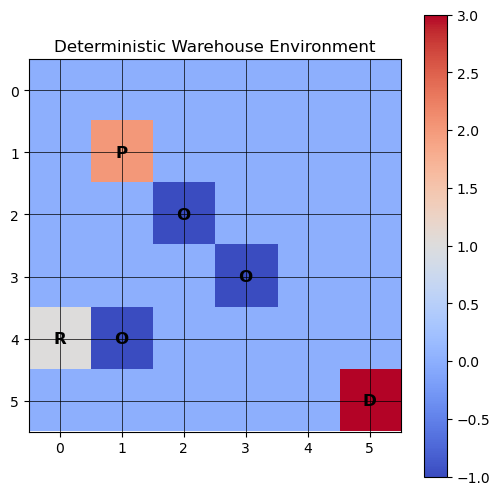

State: (3, 0, 1), Action: 2, Reward: -1


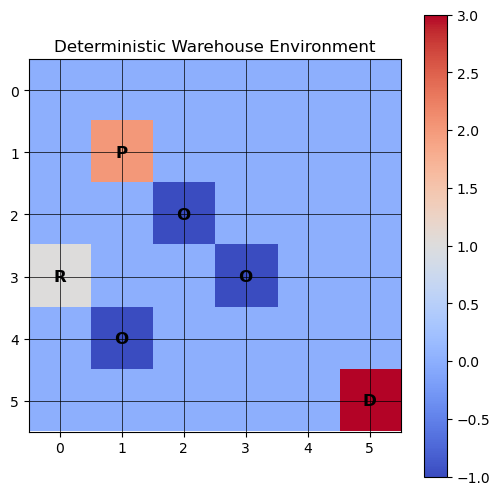

State: (2, 0, 1), Action: 2, Reward: -1


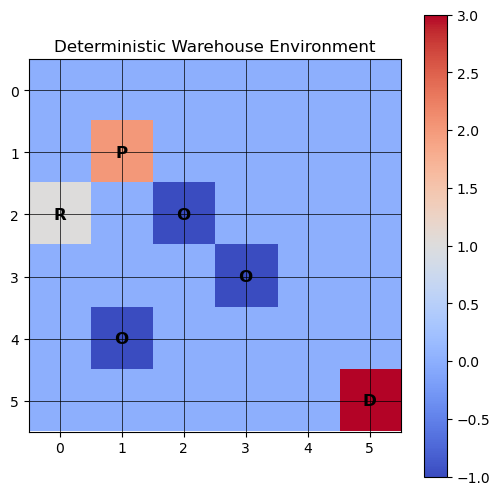

State: (1, 0, 1), Action: 2, Reward: -1


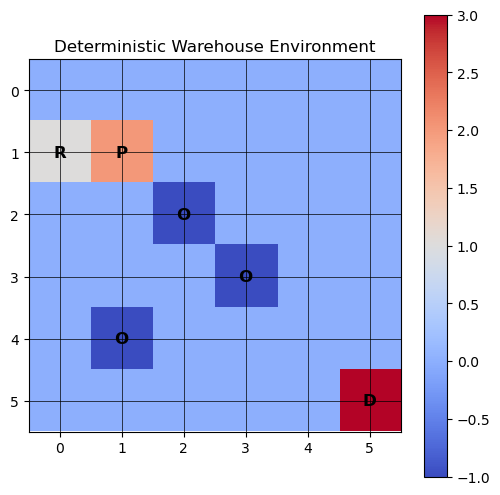

State: (1, 1, 1), Action: 1, Reward: -1


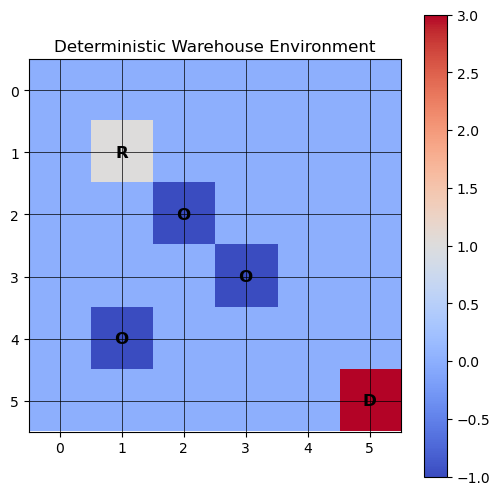

State: (0, 1, 1), Action: 2, Reward: -1


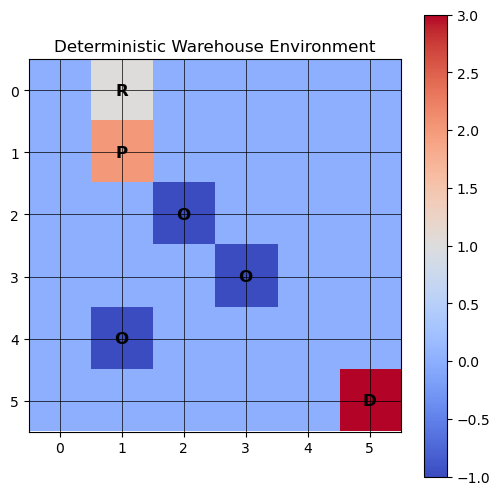

State: (0, 2, 1), Action: 1, Reward: -1


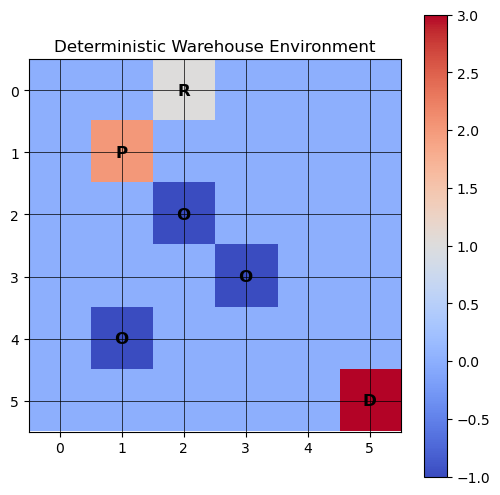

State: (0, 3, 1), Action: 1, Reward: -1


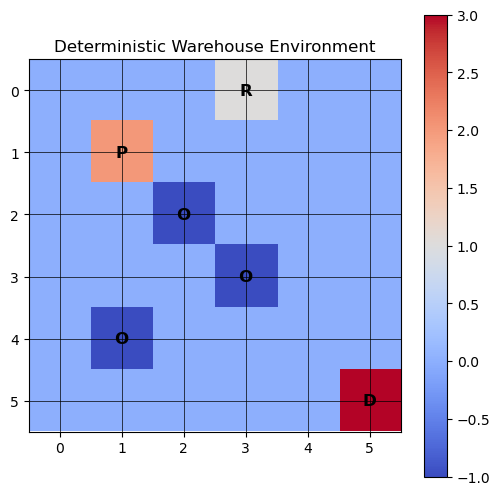

State: (1, 3, 1), Action: 3, Reward: -1


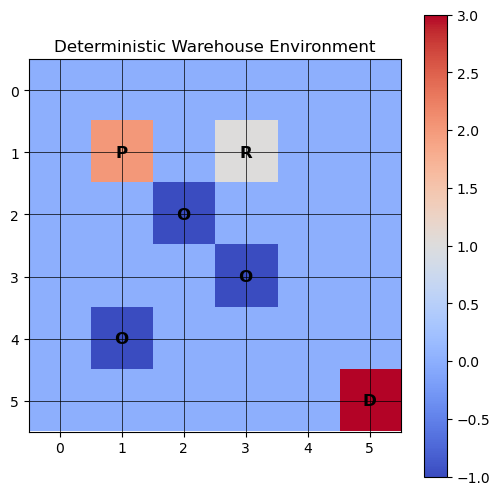

State: (1, 2, 1), Action: 0, Reward: -1


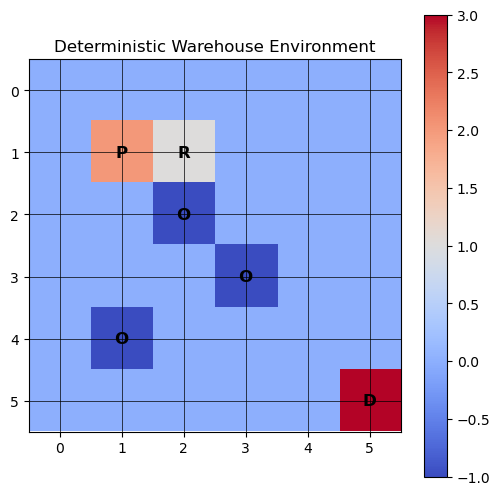

State: (1, 1, 1), Action: 0, Reward: -1


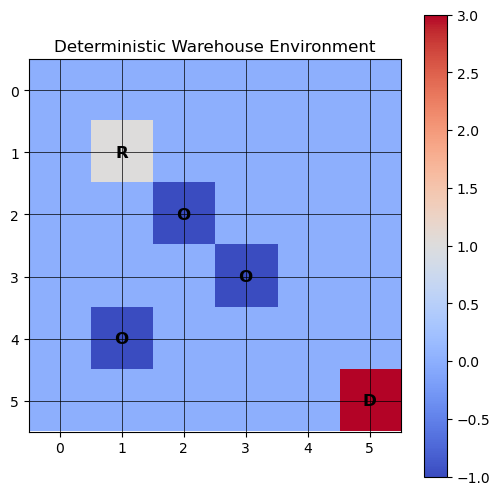

State: (1, 0, 1), Action: 0, Reward: -1


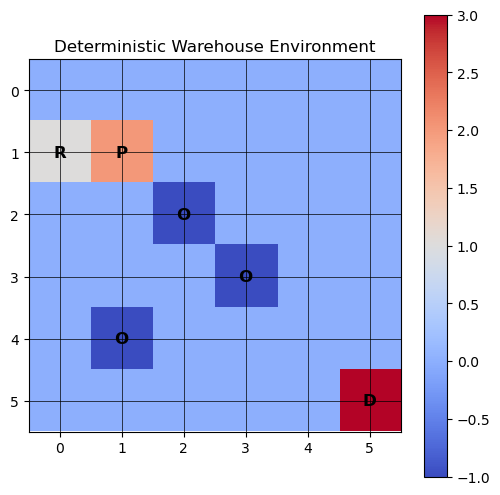

State: (1, 1, 1), Action: 1, Reward: -1


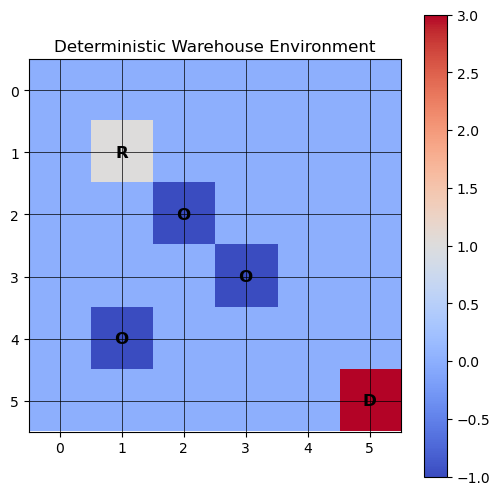

State: (1, 2, 1), Action: 1, Reward: -1


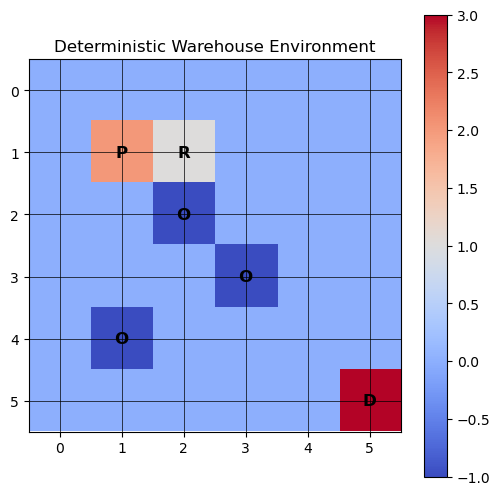

State: (1, 2, 1), Action: 3, Reward: -20


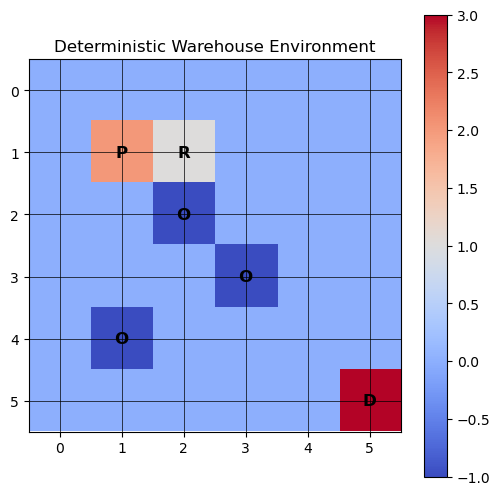

State: (1, 3, 1), Action: 1, Reward: -1


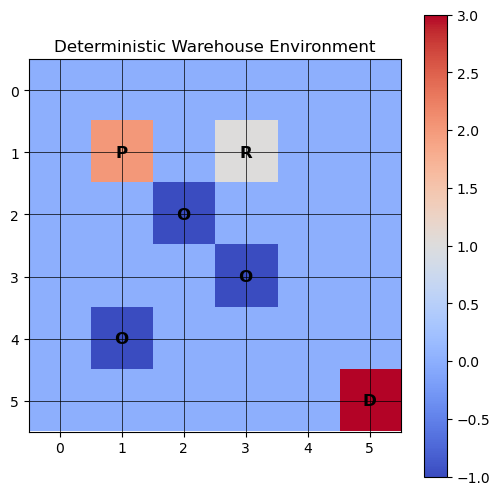

State: (1, 2, 1), Action: 0, Reward: -1


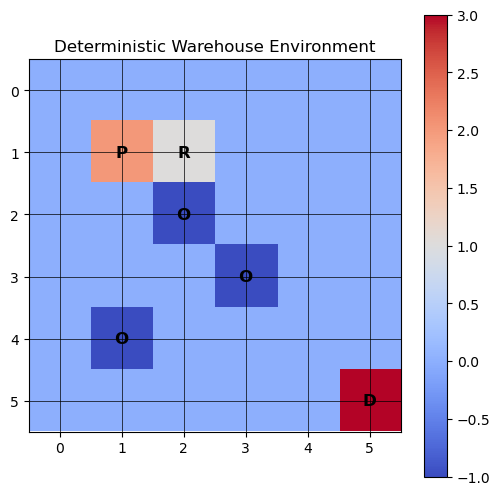

State: (0, 2, 1), Action: 2, Reward: -1


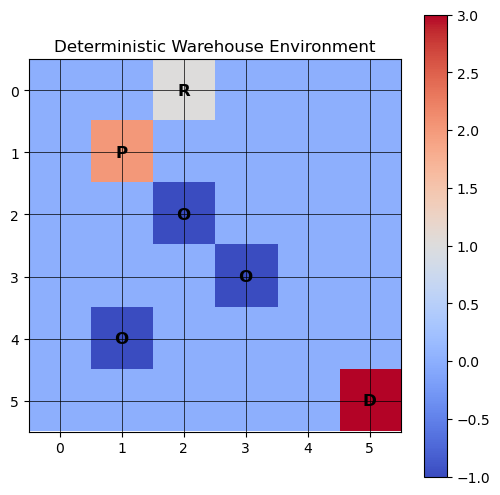

State: (0, 2, 1), Action: 2, Reward: -1


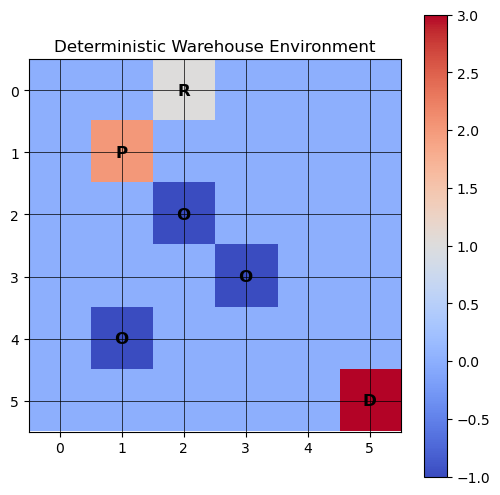

State: (0, 1, 1), Action: 0, Reward: -1


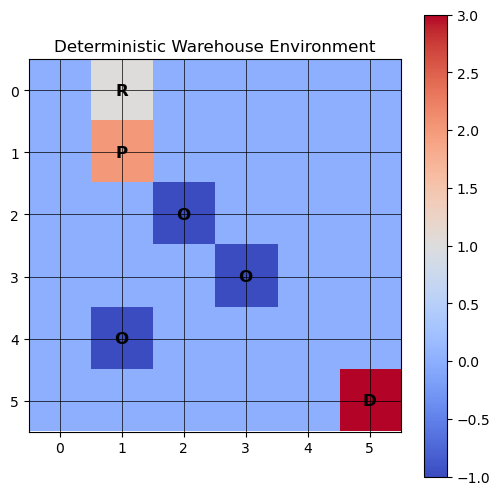

State: (1, 1, 1), Action: 3, Reward: -1


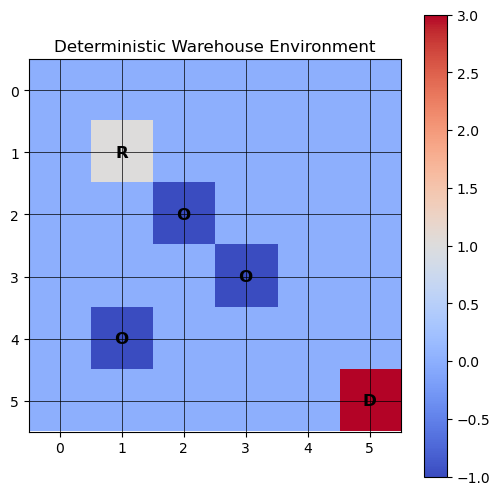

State: (2, 1, 1), Action: 3, Reward: -1


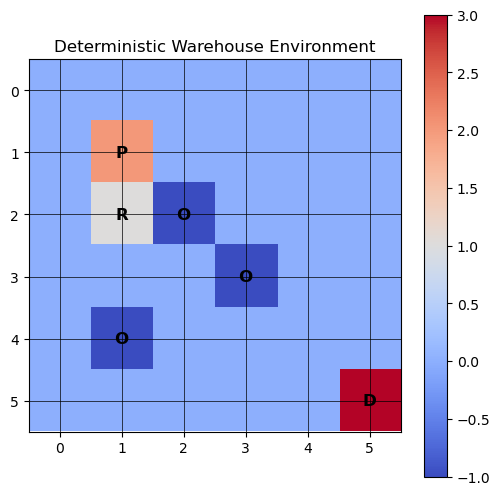

State: (2, 1, 1), Action: 1, Reward: -20


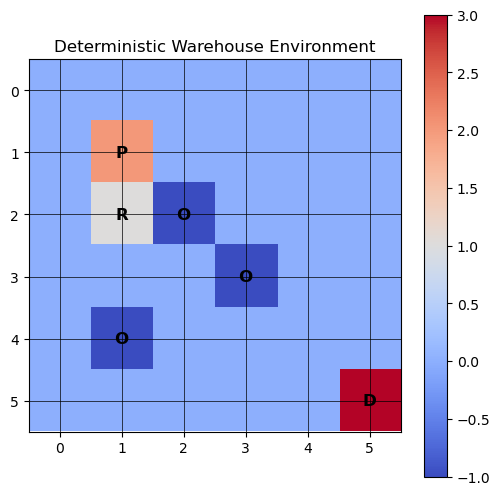

State: (2, 0, 1), Action: 0, Reward: -1


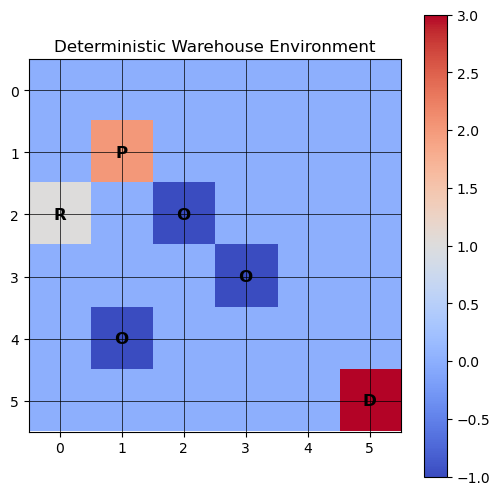

State: (2, 1, 1), Action: 1, Reward: -1


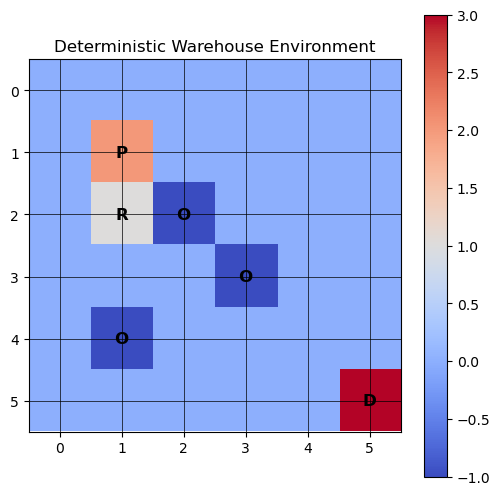

State: (1, 1, 1), Action: 2, Reward: -1


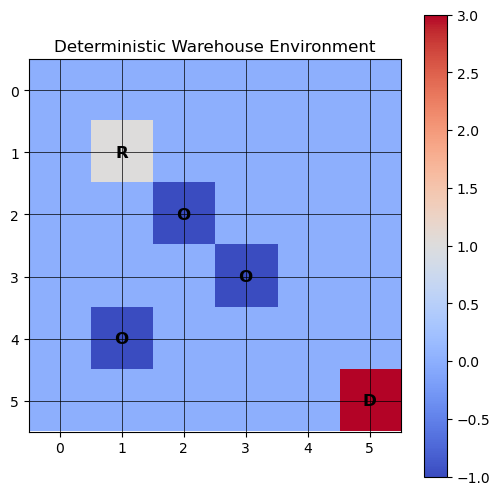

State: (0, 1, 1), Action: 2, Reward: -1


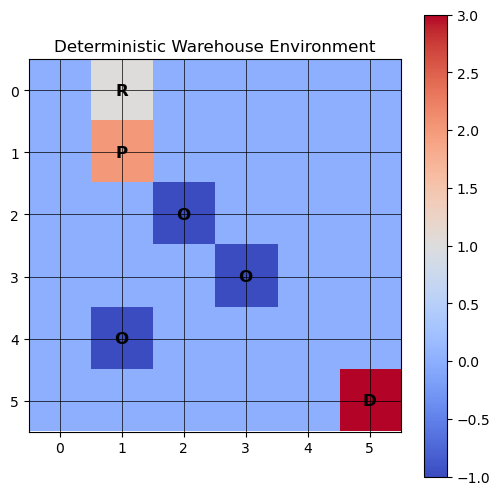

State: (0, 0, 1), Action: 0, Reward: -1


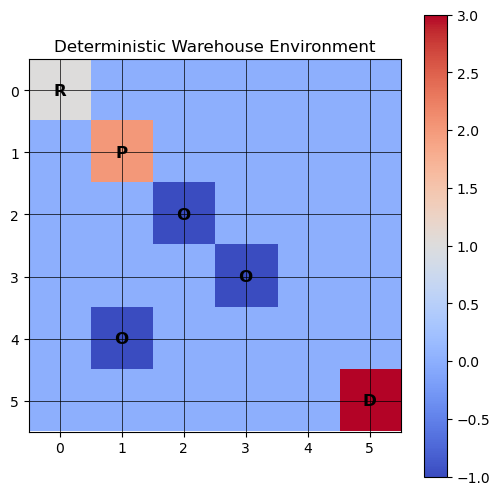

State: (0, 1, 1), Action: 1, Reward: -1


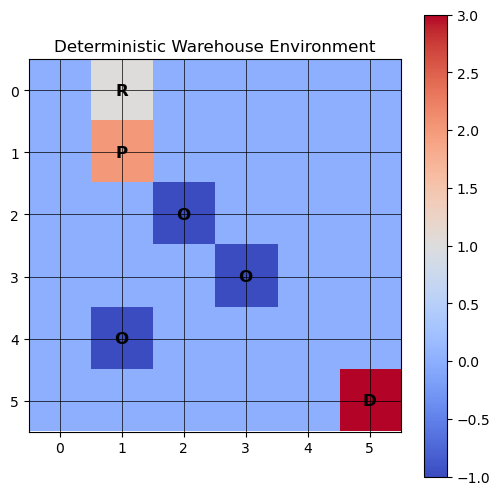

State: (0, 2, 1), Action: 1, Reward: -1


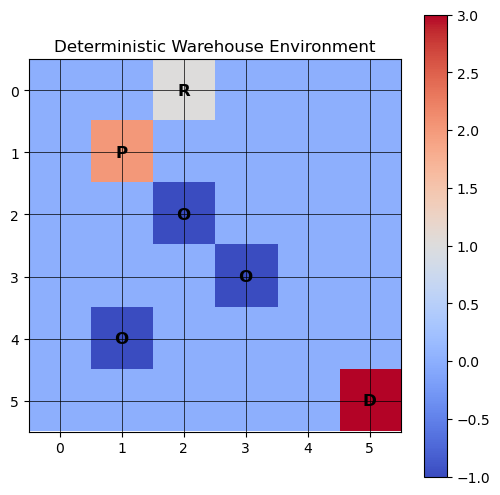

State: (0, 2, 1), Action: 2, Reward: -1


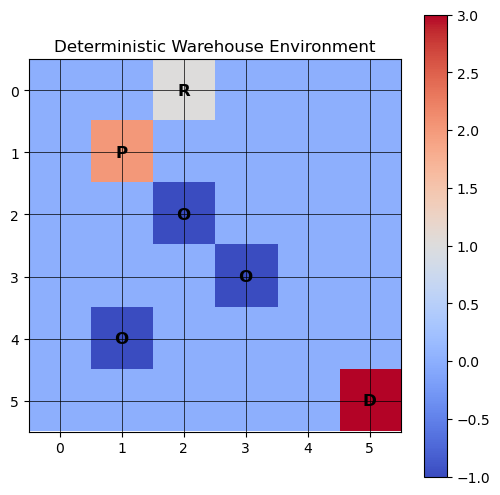

State: (0, 3, 1), Action: 1, Reward: -1


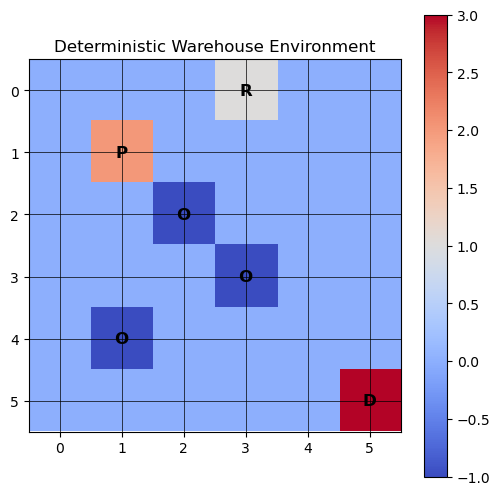

State: (0, 2, 1), Action: 0, Reward: -1


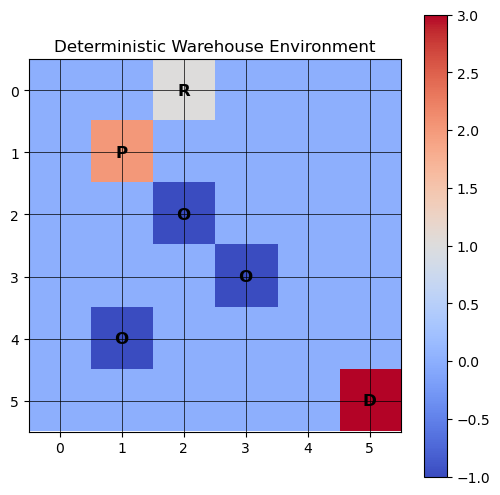

State: (0, 3, 1), Action: 1, Reward: -1


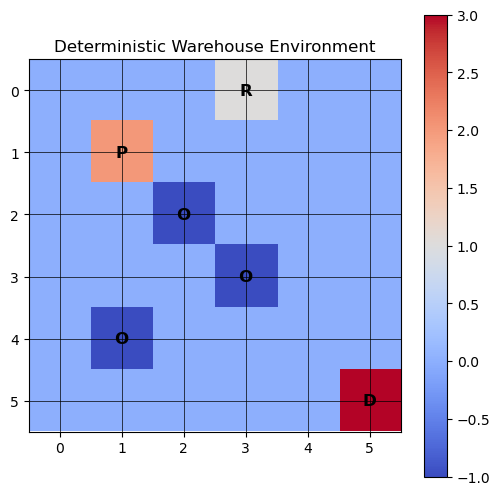

State: (1, 3, 1), Action: 3, Reward: -1


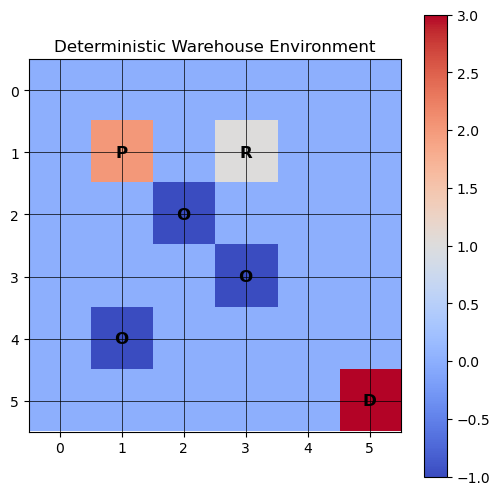

State: (1, 4, 1), Action: 1, Reward: -1


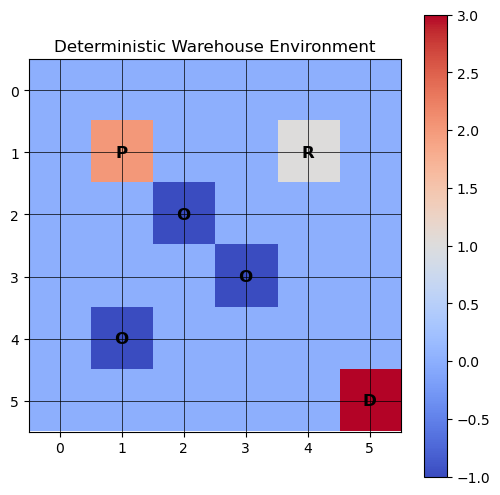

State: (2, 4, 1), Action: 3, Reward: -1


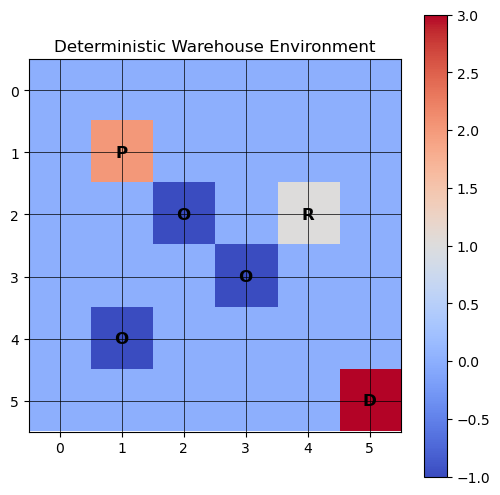

State: (1, 4, 1), Action: 2, Reward: -1


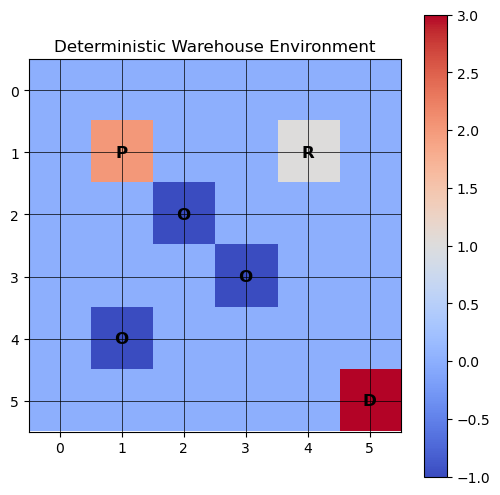

State: (1, 5, 1), Action: 1, Reward: -1


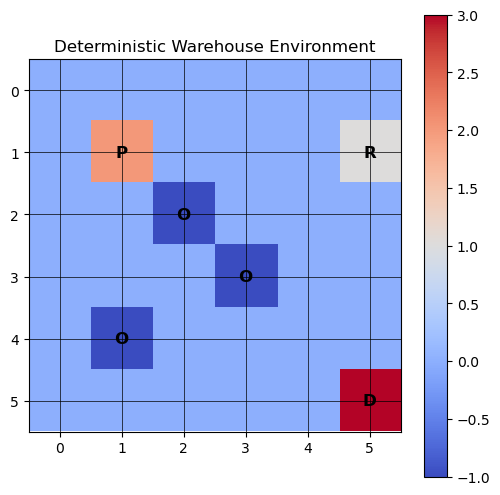

State: (1, 5, 1), Action: 1, Reward: -1


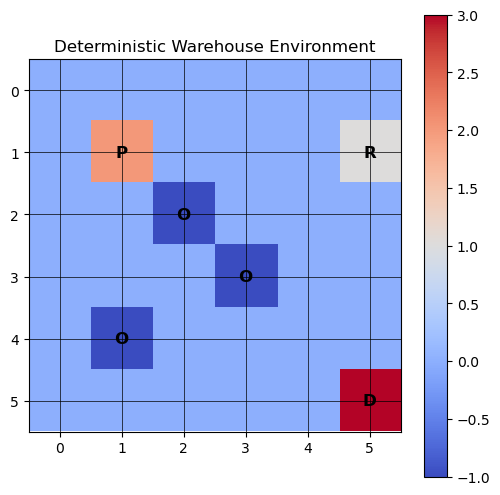

State: (0, 5, 1), Action: 2, Reward: -1


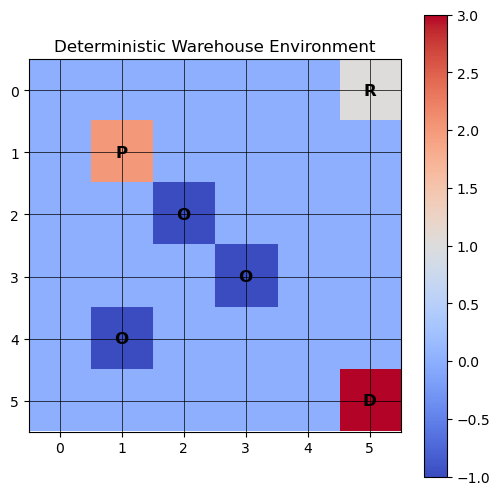

State: (0, 5, 1), Action: 2, Reward: -1


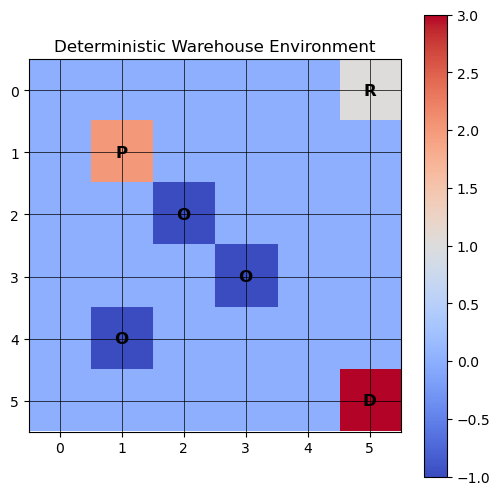

State: (0, 5, 1), Action: 1, Reward: -1


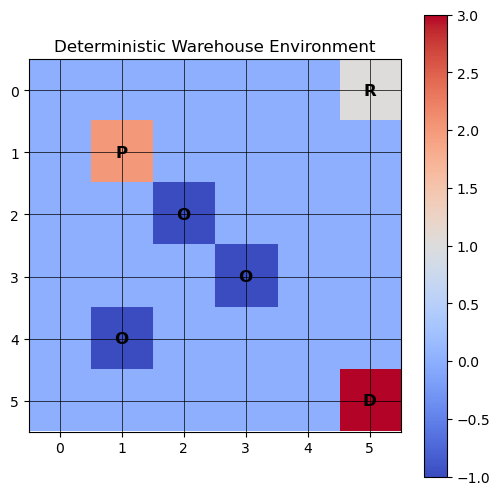

State: (0, 5, 1), Action: 2, Reward: -1


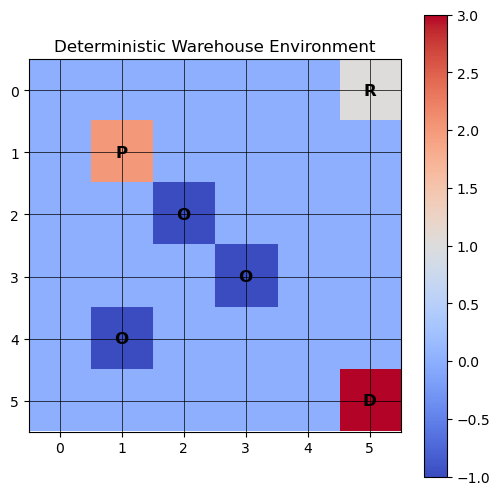

State: (0, 5, 1), Action: 1, Reward: -1


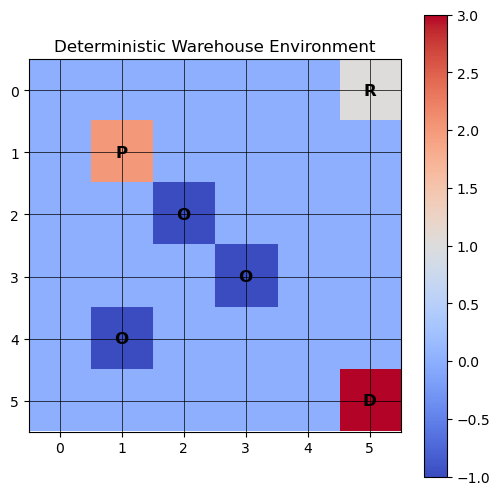

State: (1, 5, 1), Action: 3, Reward: -1


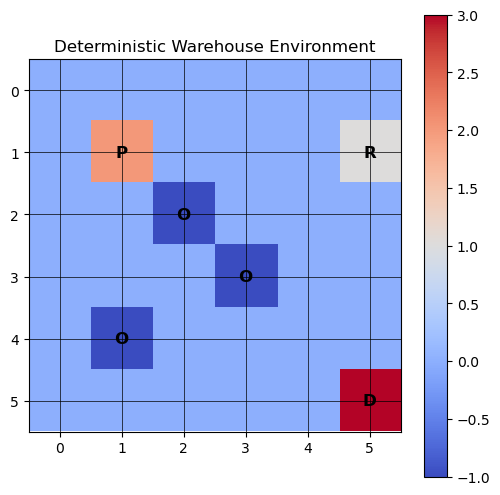

State: (2, 5, 1), Action: 3, Reward: -1


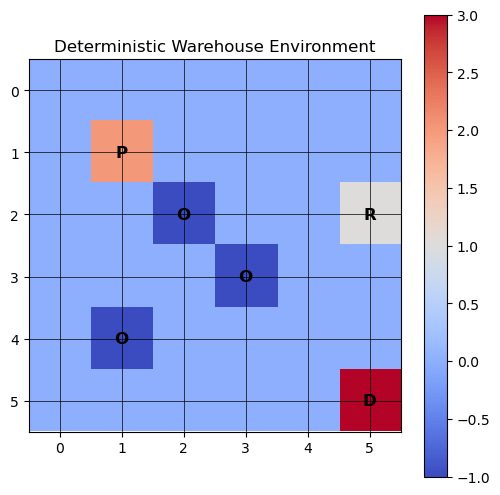

State: (3, 5, 1), Action: 3, Reward: -1


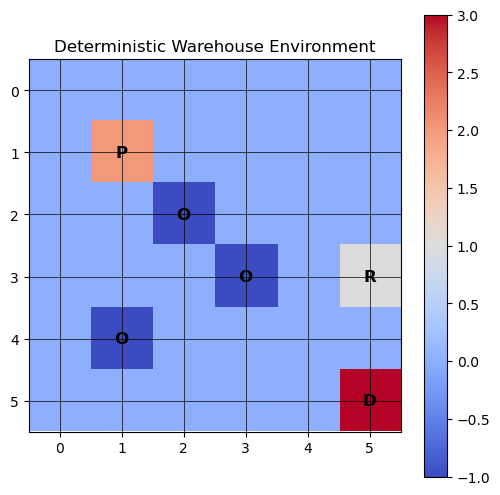

State: (4, 5, 1), Action: 3, Reward: -1


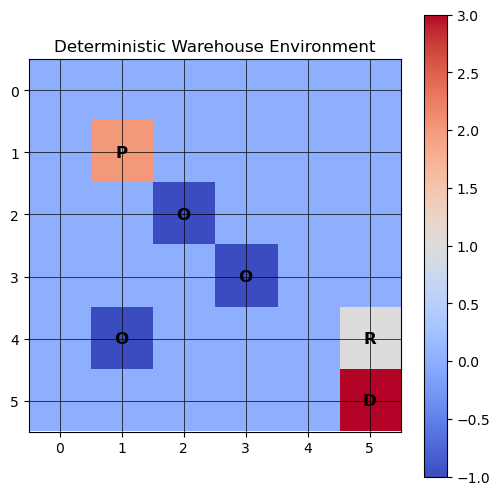

State: (5, 5, 1), Action: 3, Reward: -1


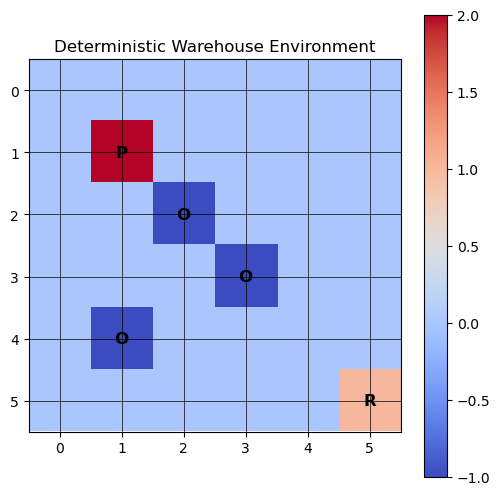

State: (5, 5, 1), Action: 5, Reward: 100


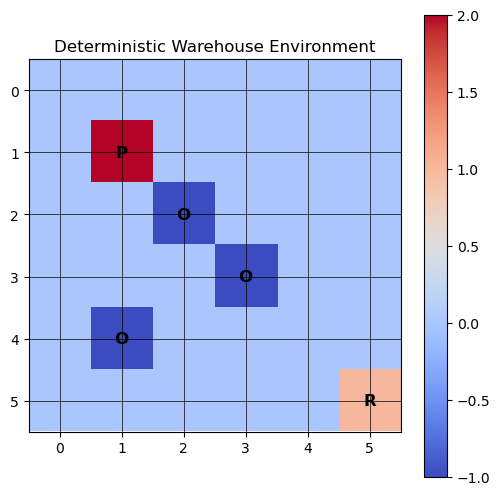

NameError: name 'StochasticWarehouseEnv' is not defined

In [ ]:
# Running the Agent for both environments
def run_agent(env):
    env.reset()
    done = False
    while not done:
        if env.pos == env.pickup and env.carrying == 0:
            action = 4
        elif env.pos == env.dropoff and env.carrying == 1:
            action = 5
        else:
            action = random.choice([0, 1, 2, 3])

        obs, reward, done, _, _ = env.step(action)
        print(f"State: {obs}, Action: {action}, Reward: {reward}")
        env.render()

# Initialize environments
det_env = DeterministicWarehouseEnv()
print("\nRunning Deterministic Environment")
run_agent(det_env)

stoch_env = StochasticWarehouseEnv()
print("\nRunning Stochastic Environment")
run_agent(stoch_env)


**BONUS**


Running Multi-task Warehouse Environment
Step 1: State: (1, 0, 0), Action: 3, Reward: -1


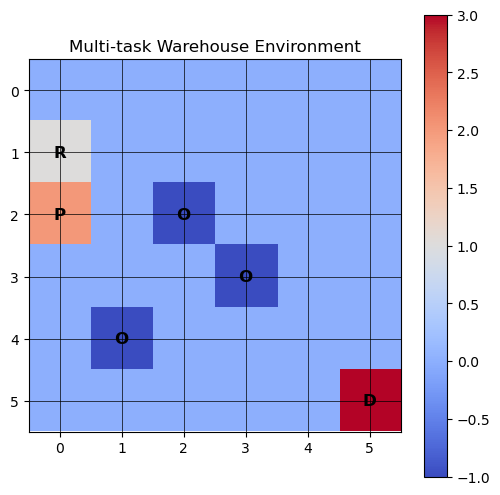

Step 2: State: (2, 0, 0), Action: 3, Reward: -1


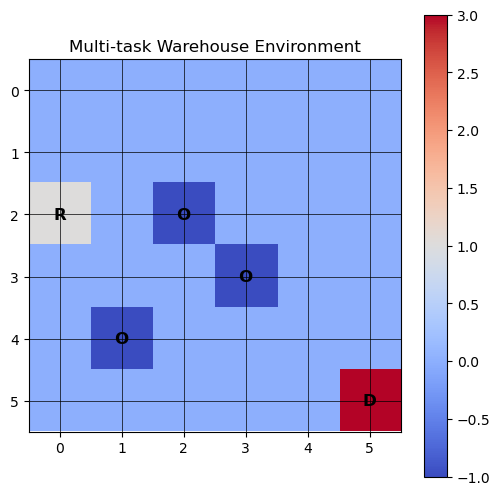

Step 3: State: (2, 0, 1), Action: 4, Reward: 25


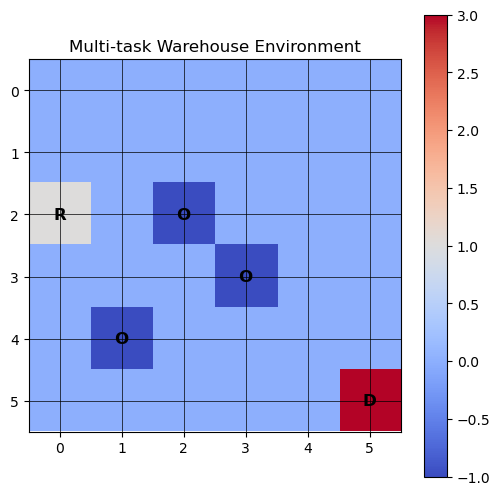

Step 4: State: (3, 0, 1), Action: 3, Reward: -1


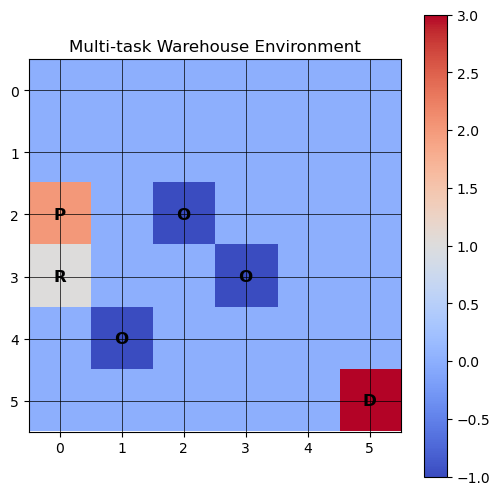

Step 5: State: (4, 0, 1), Action: 3, Reward: -1


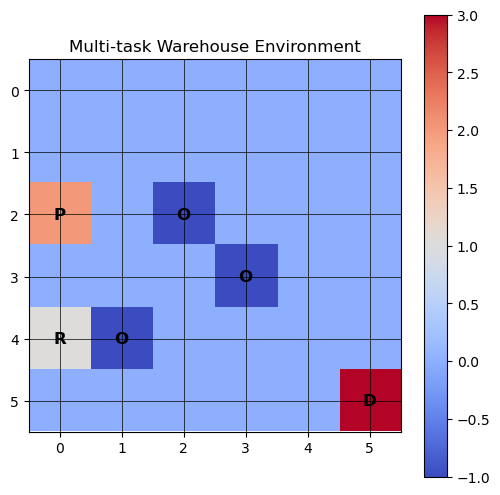

Step 6: State: (5, 0, 1), Action: 3, Reward: -1


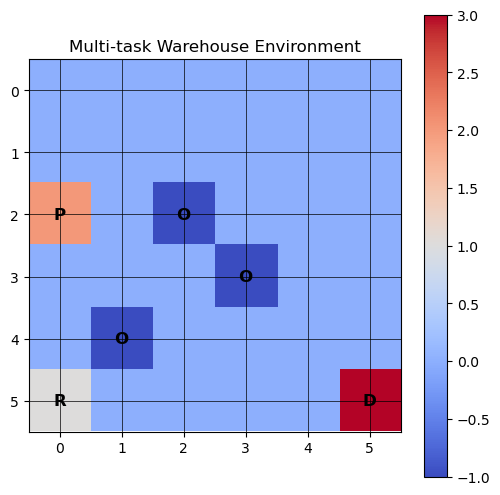

Step 7: State: (5, 1, 1), Action: 1, Reward: -1


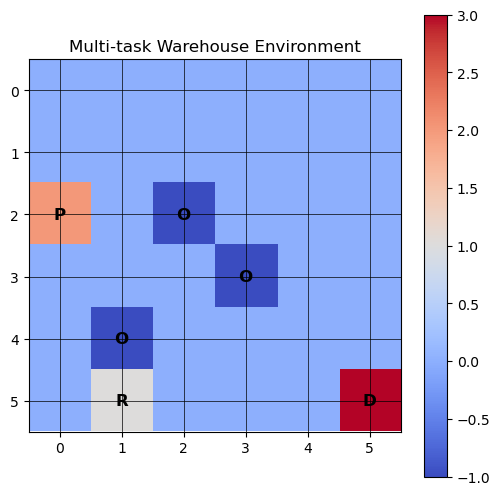

Step 8: State: (5, 2, 1), Action: 1, Reward: -1


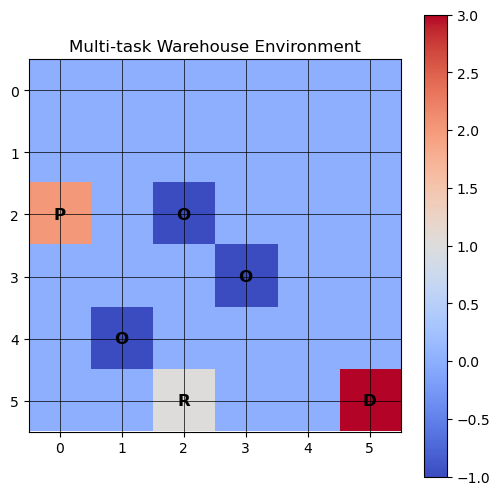

Step 9: State: (5, 3, 1), Action: 1, Reward: -1


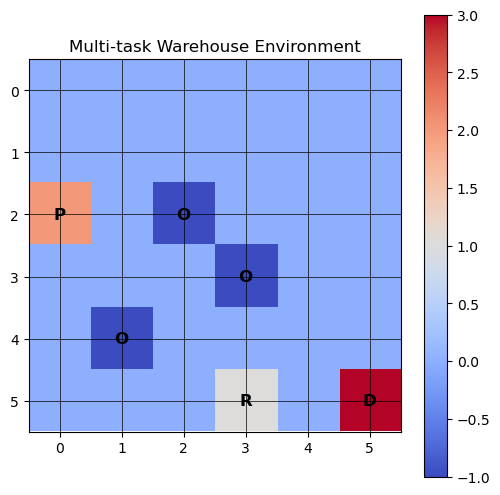

Step 10: State: (5, 4, 1), Action: 1, Reward: -1


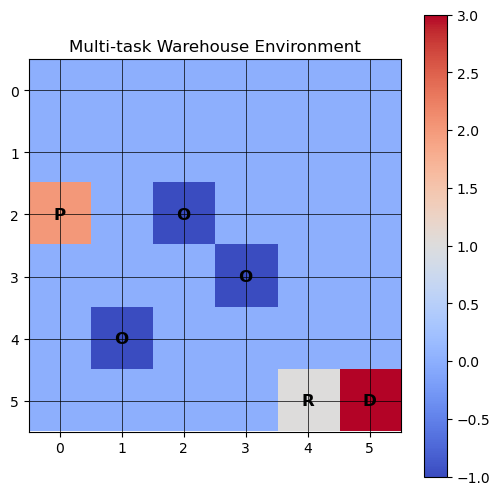

Step 11: State: (5, 5, 1), Action: 1, Reward: -1


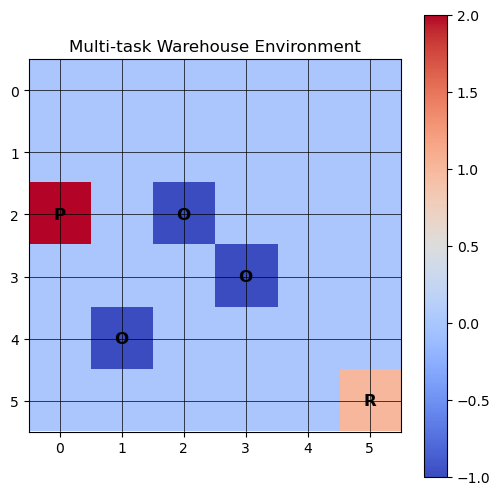

Step 12: State: (5, 5, 0), Action: 5, Reward: 50


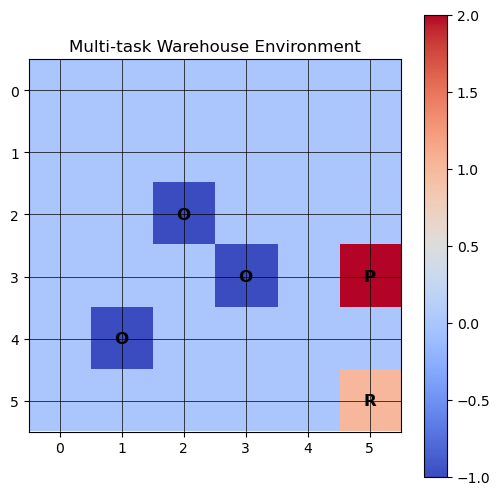

Step 13: State: (4, 5, 0), Action: 2, Reward: -1


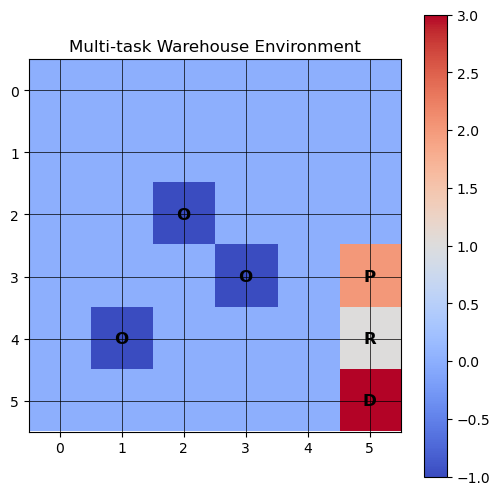

Step 14: State: (3, 5, 0), Action: 2, Reward: -1


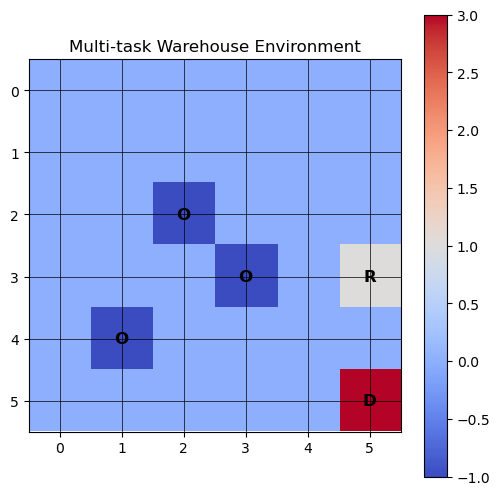

Step 15: State: (3, 5, 1), Action: 4, Reward: 25


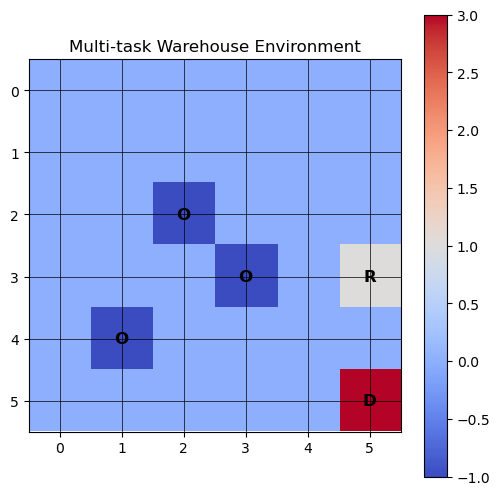

Step 16: State: (4, 5, 1), Action: 3, Reward: -1


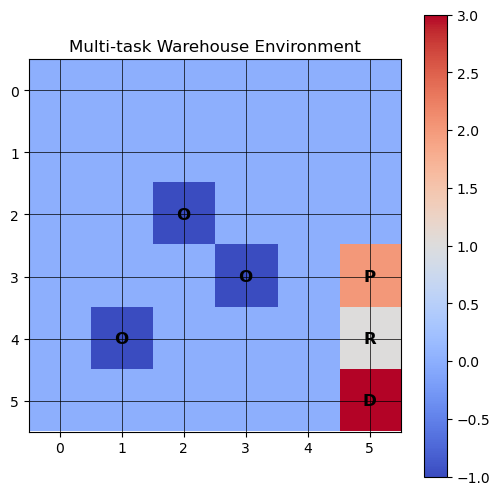

Step 17: State: (5, 5, 1), Action: 3, Reward: -1


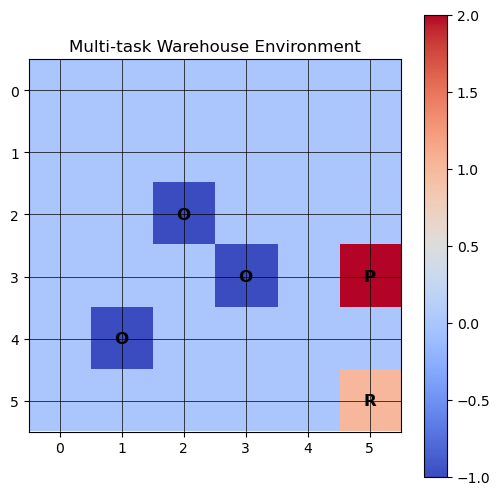

Step 18: State: (5, 5, 0), Action: 5, Reward: 50


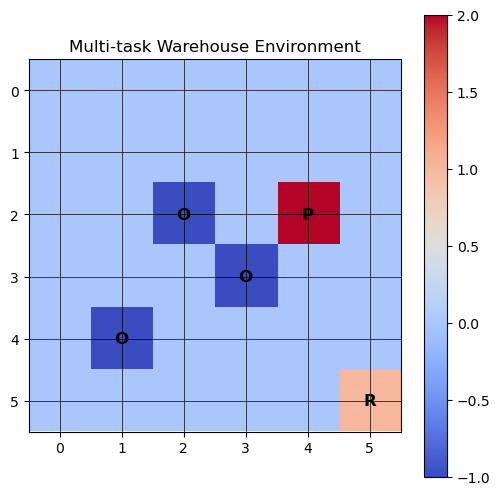

Step 19: State: (4, 5, 0), Action: 2, Reward: -1


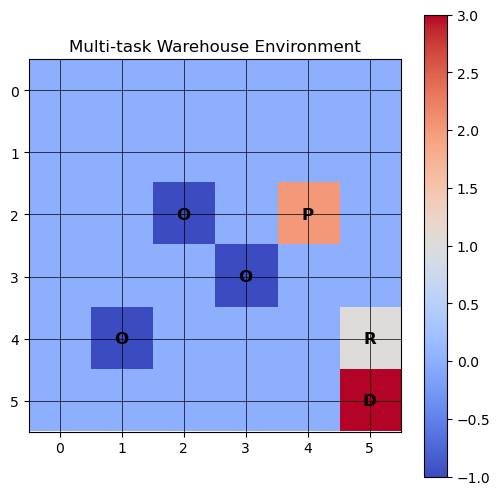

Step 20: State: (3, 5, 0), Action: 2, Reward: -1


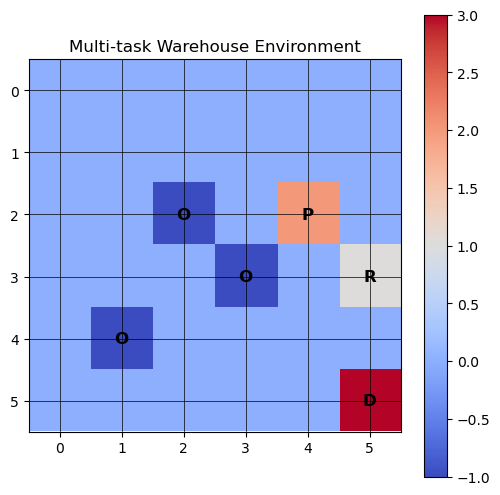

Step 21: State: (2, 5, 0), Action: 2, Reward: -1


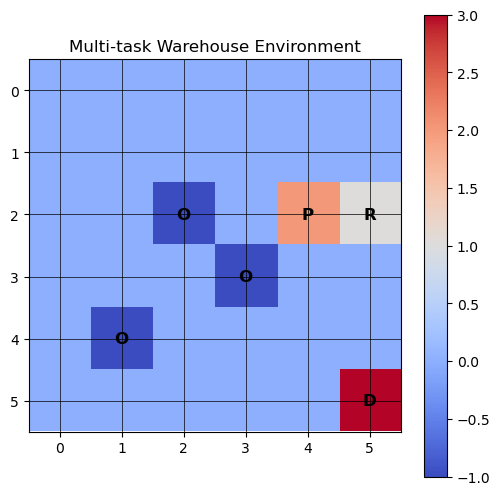

Step 22: State: (2, 4, 0), Action: 0, Reward: -1


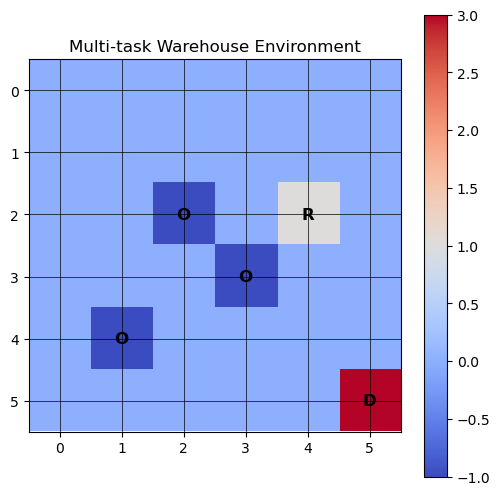

Step 23: State: (2, 4, 1), Action: 4, Reward: 25


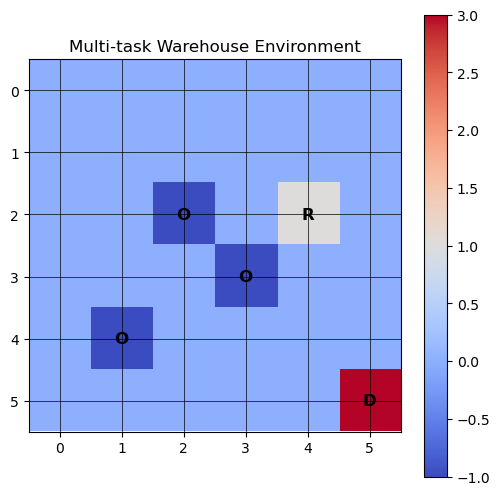

Step 24: State: (3, 4, 1), Action: 3, Reward: -1


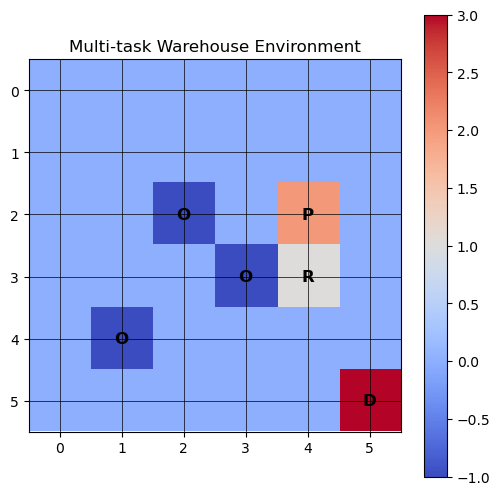

Step 25: State: (4, 4, 1), Action: 3, Reward: -1


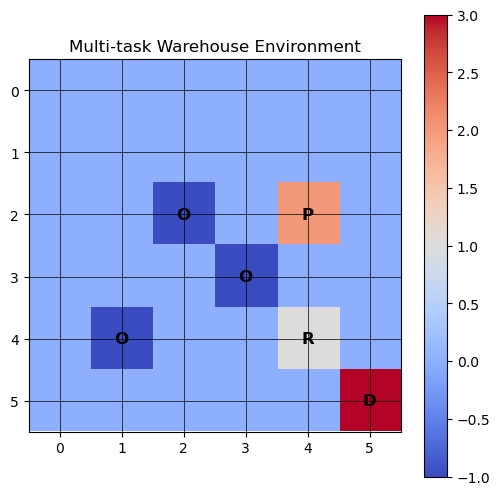

Step 26: State: (5, 4, 1), Action: 3, Reward: -1


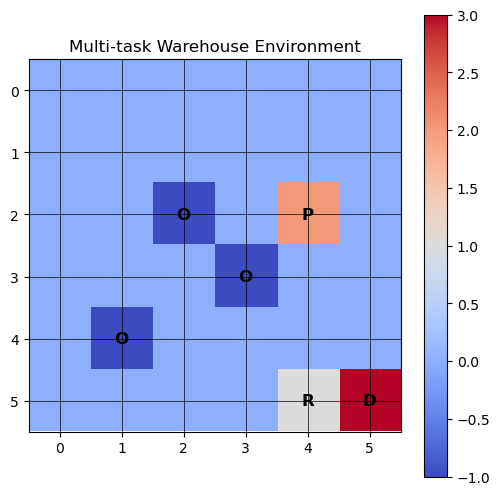

Step 27: State: (5, 5, 1), Action: 1, Reward: -1


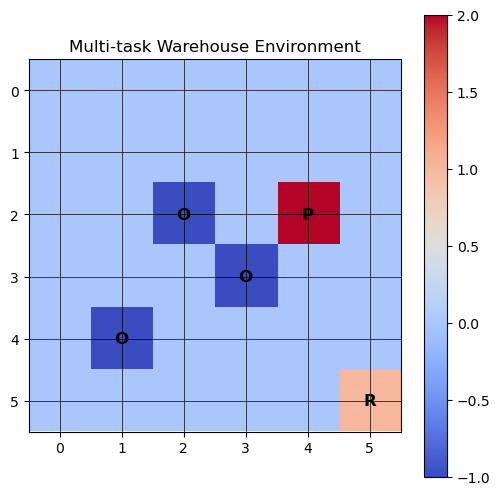

Step 28: State: (5, 5, 0), Action: 5, Reward: 50


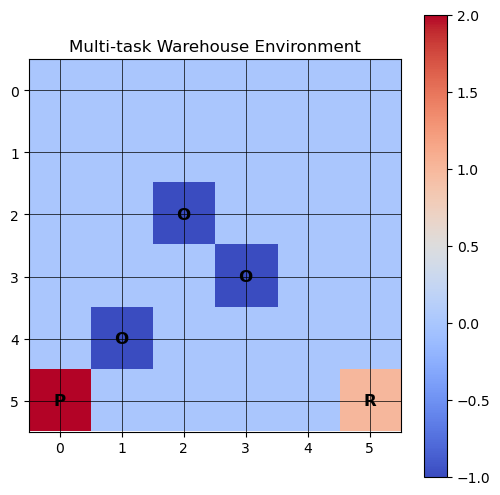

Step 29: State: (5, 4, 0), Action: 0, Reward: -1


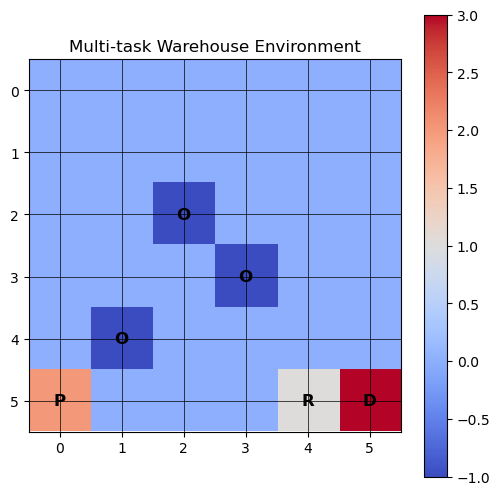

Step 30: State: (5, 3, 0), Action: 0, Reward: -1


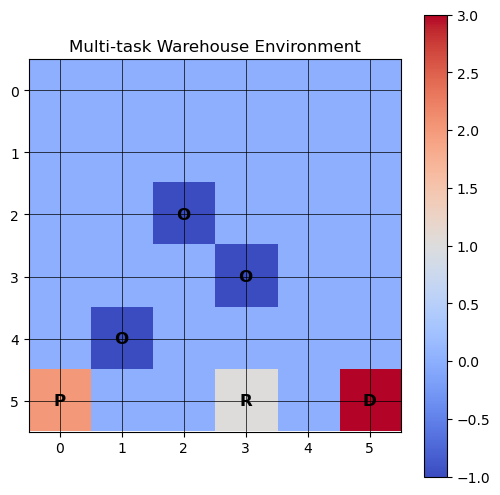

Step 31: State: (5, 2, 0), Action: 0, Reward: -1


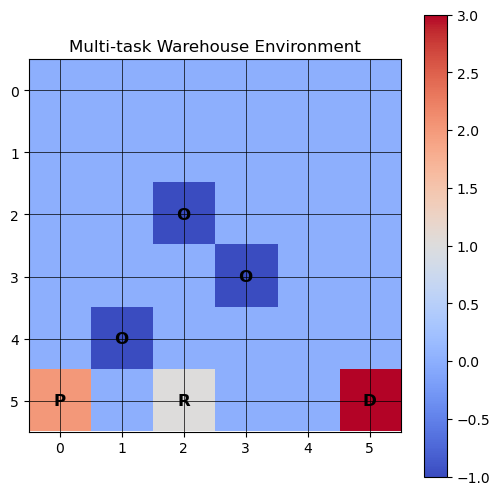

Step 32: State: (5, 1, 0), Action: 0, Reward: -1


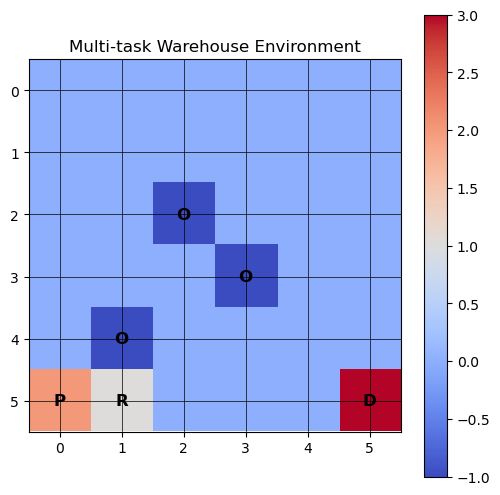

Step 33: State: (5, 0, 0), Action: 0, Reward: -1


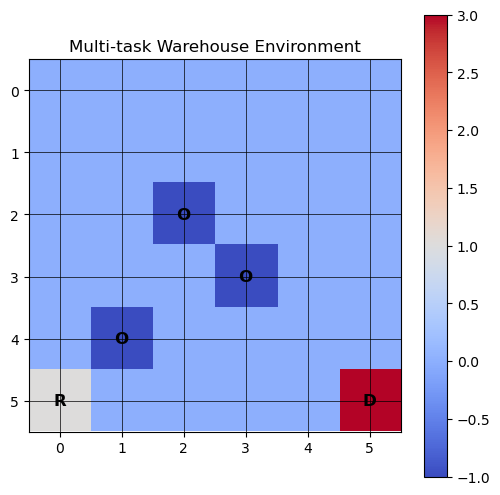

Step 34: State: (5, 0, 1), Action: 4, Reward: 25


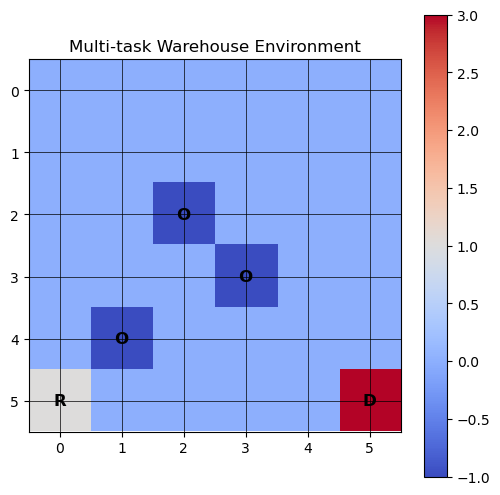

Step 35: State: (5, 1, 1), Action: 1, Reward: -1


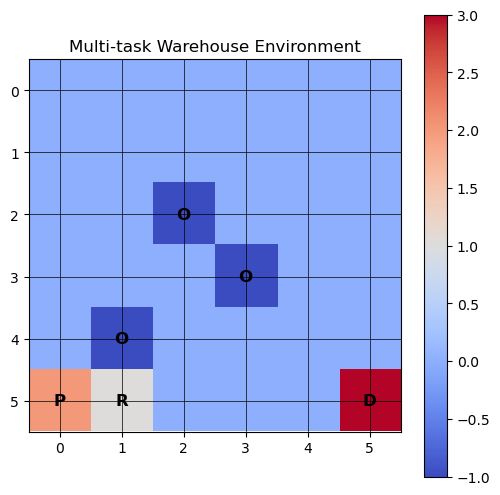

Step 36: State: (5, 2, 1), Action: 1, Reward: -1


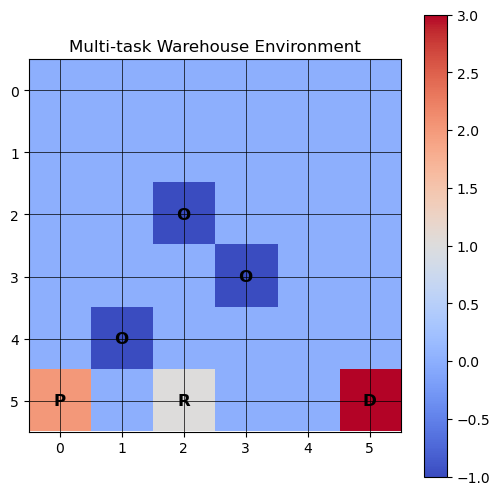

Step 37: State: (5, 3, 1), Action: 1, Reward: -1


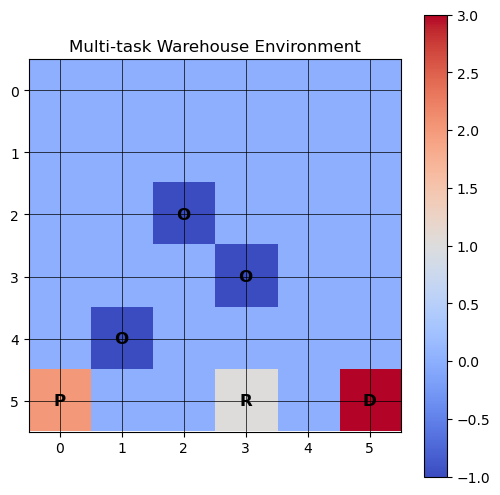

Step 38: State: (5, 4, 1), Action: 1, Reward: -1


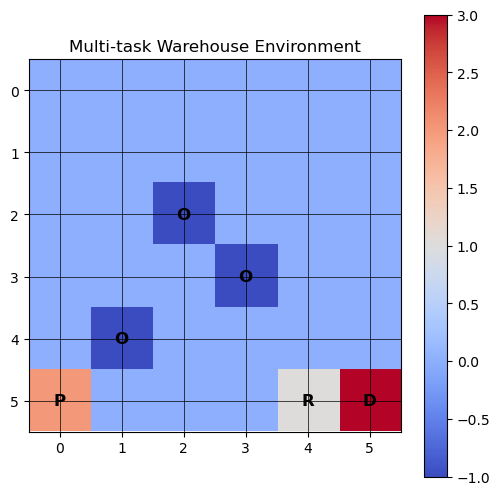

Step 39: State: (5, 5, 1), Action: 1, Reward: -1


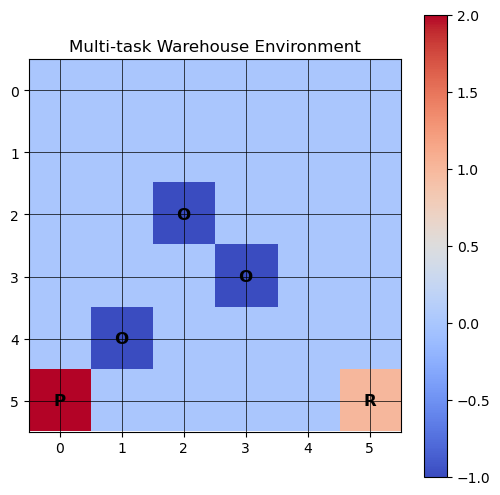

Step 40: State: (5, 5, 0), Action: 5, Reward: 50


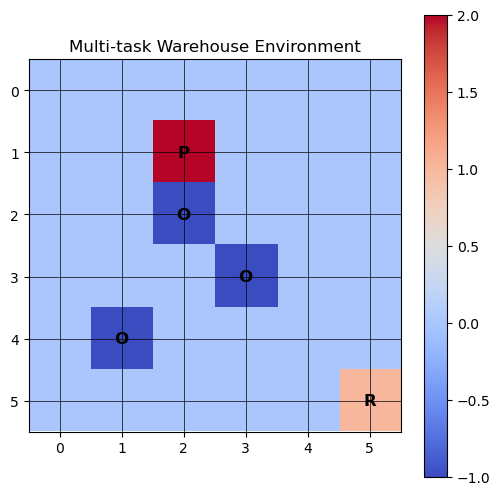

Step 41: State: (4, 5, 0), Action: 2, Reward: -1


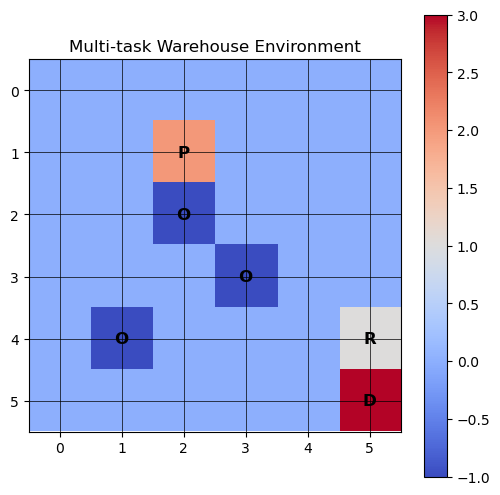

Step 42: State: (3, 5, 0), Action: 2, Reward: -1


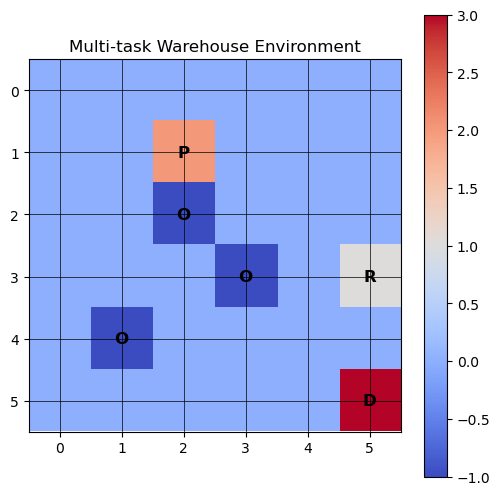

Step 43: State: (2, 5, 0), Action: 2, Reward: -1


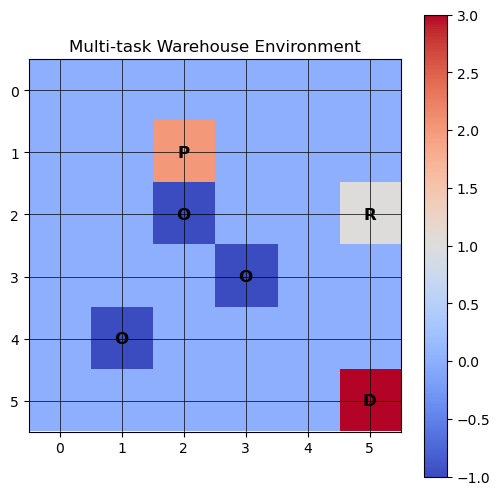

Step 44: State: (1, 5, 0), Action: 2, Reward: -1


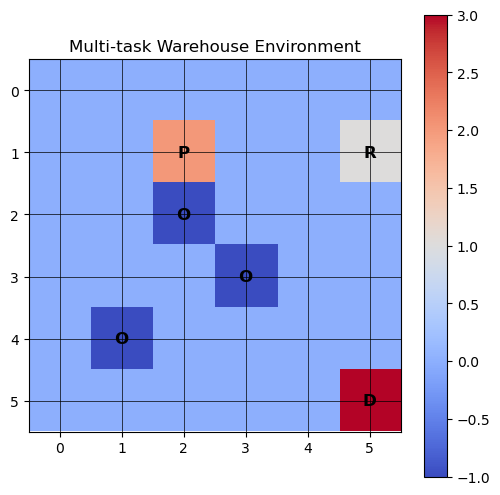

Step 45: State: (1, 4, 0), Action: 0, Reward: -1


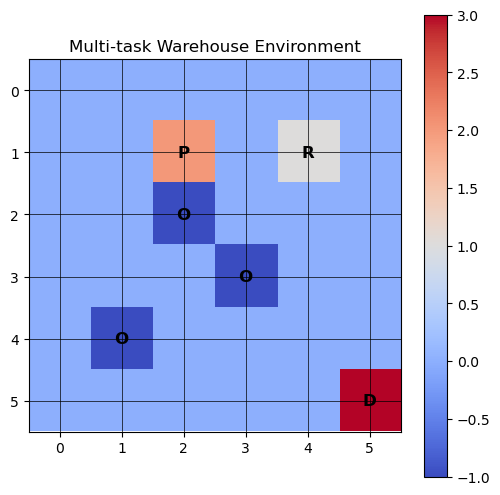

Step 46: State: (1, 3, 0), Action: 0, Reward: -1


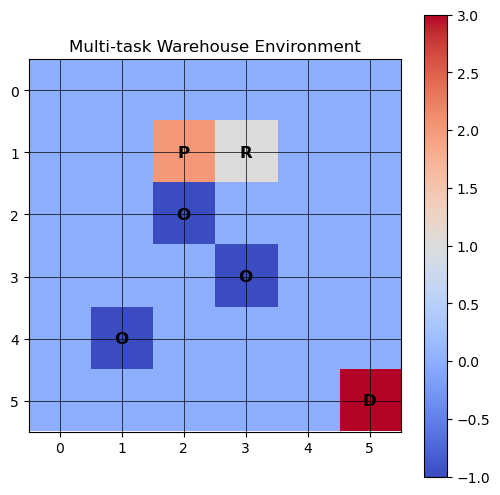

Step 47: State: (1, 2, 0), Action: 0, Reward: -1


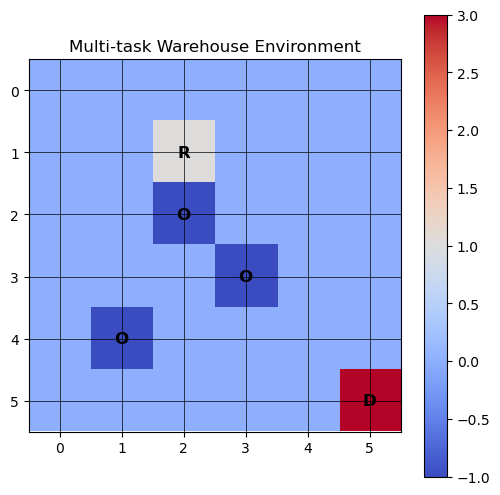

Step 48: State: (1, 2, 1), Action: 4, Reward: 25


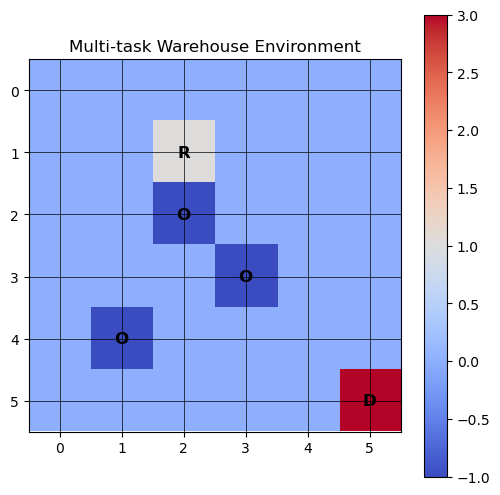

Step 49: State: (1, 2, 1), Action: 3, Reward: -20


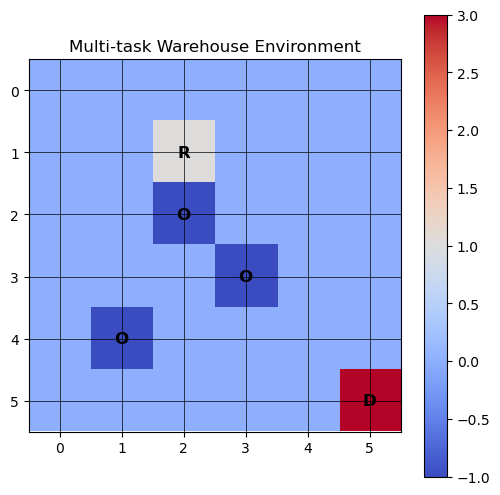

Step 50: State: (1, 2, 1), Action: 3, Reward: -20


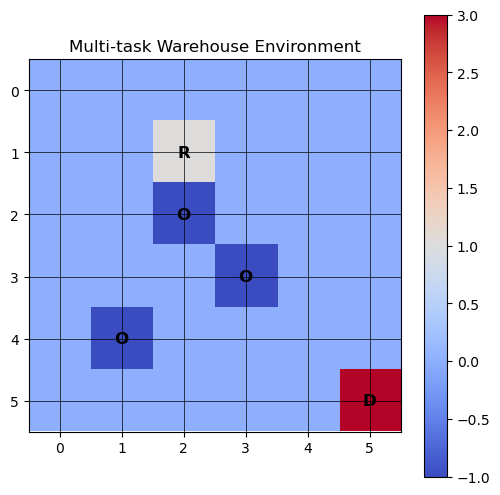

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt

class MultiTaskWarehouseEnv(gym.Env):
    def __init__(self, num_tasks=5, random_pickups=False):
        super().__init__()
        self.size = 6
        self.num_tasks = num_tasks
        self.completed_tasks = 0
        self.random_pickups = random_pickups
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Tuple((
            spaces.Discrete(self.size),
            spaces.Discrete(self.size),
            spaces.Discrete(2)
        ))
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.dropoff = (5, 5)
        self.pickup = self._generate_pickup_location()
        self.reset()

    def _generate_pickup_location(self):
        """Generate a pick-up location based on the mode."""
        if self.random_pickups:
            return self._generate_random_pickup()
        return (1, 1)

    def _generate_random_pickup(self):
        """Generate a random pick-up location avoiding obstacles and the drop-off location."""
        while True:
            new_pickup = (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            if new_pickup not in self.obstacles and new_pickup != self.dropoff:
                return new_pickup

    def reset(self):
        """Reset the environment with a new pickup location."""
        self.pos = (0, 0)
        self.carrying = 0
        self.completed_tasks = 0
        self.pickup = self._generate_pickup_location()
        return self._get_obs(), {}

    def _get_obs(self):
        return (self.pos[0], self.pos[1], self.carrying)

    def step(self, action):
        x, y = self.pos

        if action == 0: new_pos = (x, max(0, y - 1))
        elif action == 1: new_pos = (x, min(self.size - 1, y + 1))
        elif action == 2: new_pos = (max(0, x - 1), y)
        elif action == 3: new_pos = (min(self.size - 1, x + 1), y)
        elif action == 4 and self.pos == self.pickup and self.carrying == 0:
            self.carrying = 1
            return self._get_obs(), 25, False, False, {}
        elif action == 5 and self.pos == self.dropoff and self.carrying == 1:
            self.completed_tasks += 1
            self.carrying = 0
            if self.completed_tasks >= self.num_tasks:
                return self._get_obs(), 100, True, False, {}
            else:
                self.pickup = self._generate_pickup_location()
                return self._get_obs(), 50, False, False, {}
        elif action in [4, 5]:
            return self._get_obs(), -5, False, False, {}

        if new_pos in self.obstacles:
            reward = -20
        else:
            self.pos = new_pos
            reward = -1

        return self._get_obs(), reward, False, False, {}

    def render(self):
        grid = np.zeros((self.size, self.size))
        for obs in self.obstacles:
            grid[obs] = -1
        grid[self.pickup] = 2
        grid[self.dropoff] = 3
        grid[self.pos] = 1

        plt.figure(figsize=(6,6))
        plt.imshow(grid, cmap='coolwarm', origin='upper')
        plt.xticks(range(self.size))
        plt.yticks(range(self.size))
        plt.grid(True, color='black', linewidth=0.5)
        plt.title("Multi-task Warehouse Environment")
        plt.colorbar()

        for i in range(self.size):
            for j in range(self.size):
                if grid[j, i] == -1:
                    plt.text(i, j, 'O', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 2:
                    plt.text(i, j, 'P', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 3:
                    plt.text(i, j, 'D', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
                elif grid[j, i] == 1:
                    plt.text(i, j, 'R', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

        plt.show()

def run_multi_task_agent(env, max_steps=50):
    env.reset()
    done = False
    steps = 0
    while not done and steps < max_steps:
        x, y, carrying = env._get_obs()

        if carrying == 0:
            target_x, target_y = env.pickup
        else:
            target_x, target_y = env.dropoff

        if x < target_x:
            action = 3
        elif x > target_x:
            action = 2
        elif y < target_y:
            action = 1
        elif y > target_y:
            action = 0
        else:
            action = 4 if carrying == 0 else 5

        obs, reward, done, _, _ = env.step(action)
        print(f"Step {steps + 1}: State: {obs}, Action: {action}, Reward: {reward}")
        env.render()
        steps += 1

multi_task_env = MultiTaskWarehouseEnv(num_tasks=5, random_pickups=True)
print("\nRunning Multi-task Warehouse Environment")
run_multi_task_agent(multi_task_env)


**PART 2**

Base Model: Running Q-learning on Deterministic Environment with default hyperparameters
Episode 1: Total Reward = -172, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -100, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -201, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -72, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -137, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -186, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -162, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -106, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -164, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -110, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -114, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -110, Epsilon = 0.5403600876626365, Iterations = 50

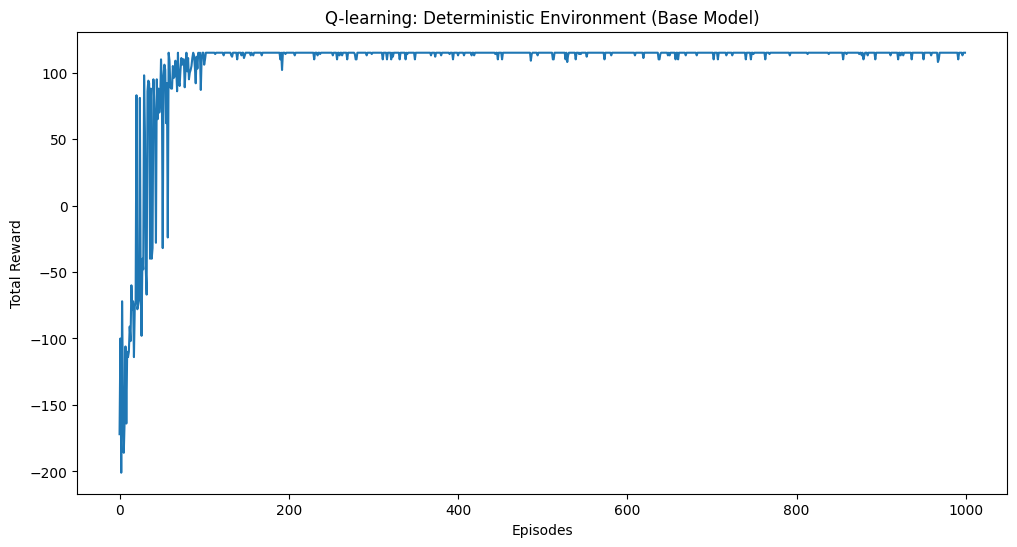

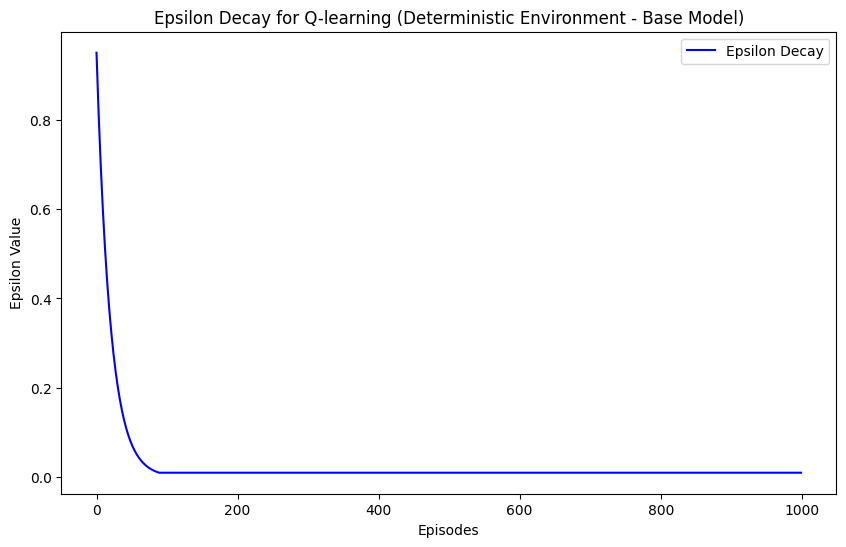

Base Model: Running Q-learning on Stochastic Environment with default hyperparameters
Episode 1: Total Reward = -142, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -215, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -122, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -117, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -101, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -186, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -68, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -128, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -193, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -72, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -102, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -136, Epsilon = 0.5403600876626365, Iterations = 50
Epi

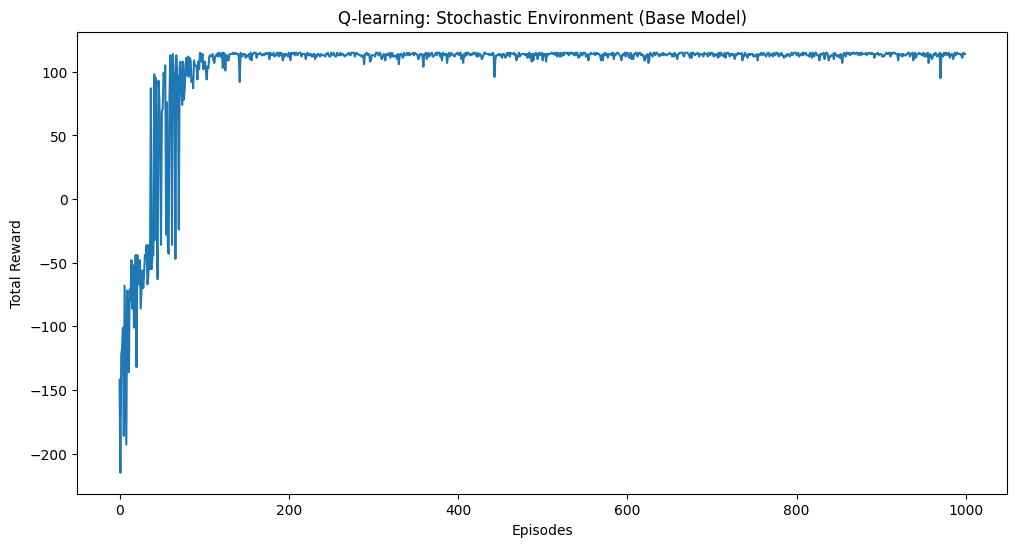

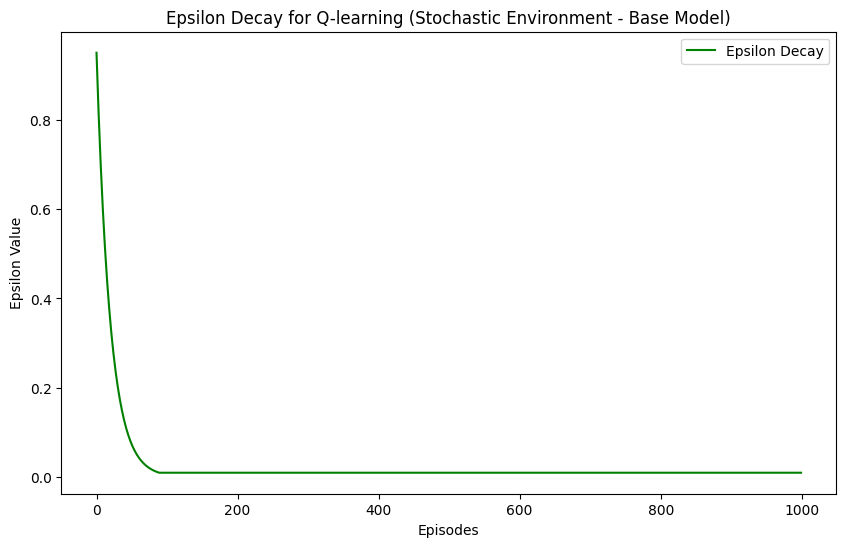

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=0.7 and epsilon_decay=0.95
Episode 1: Total Reward = -172, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -106, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -111, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -95, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -87, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -84, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -164, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -68, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -190, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -109, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -63, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -109, Epsilon = 0.540360087662636

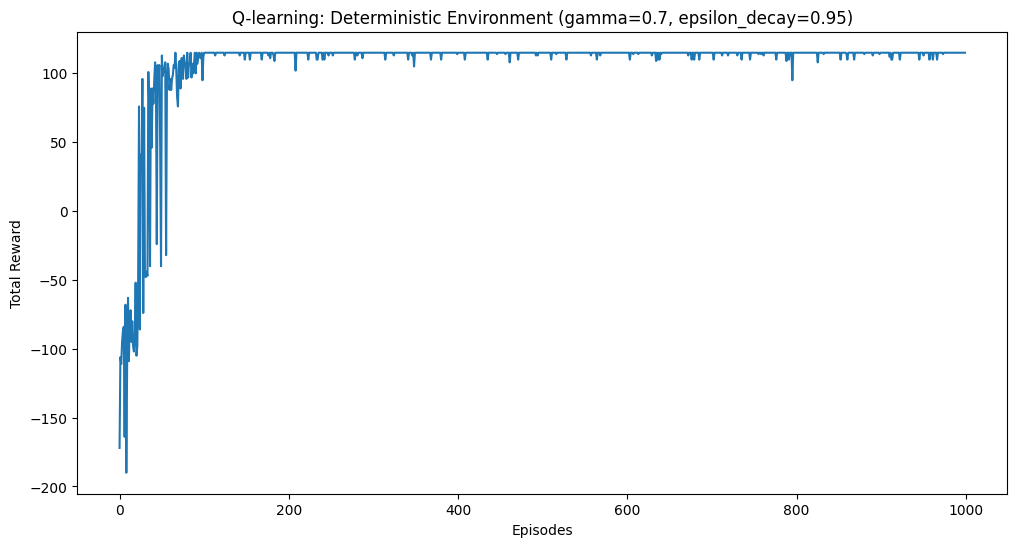

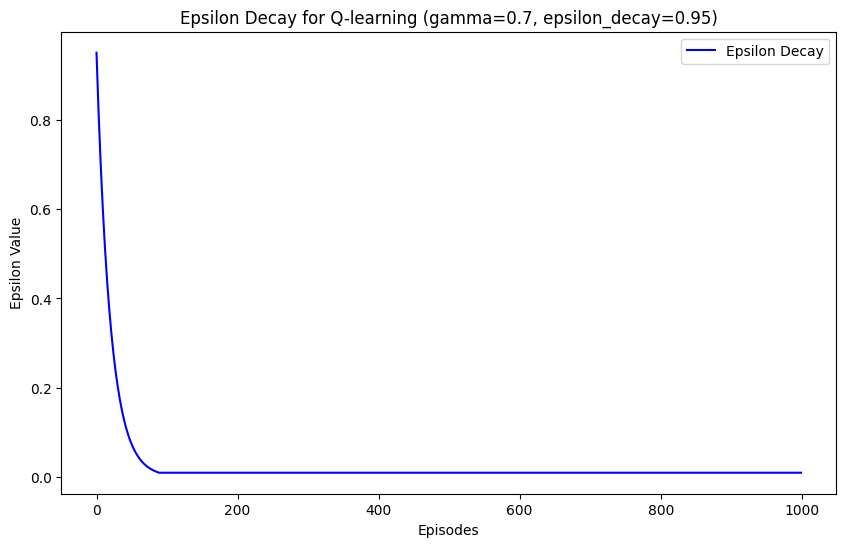

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=0.7 and epsilon_decay=0.99
Episode 1: Total Reward = -122, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -270, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -133, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -155, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -202, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -193, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -185, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -191, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -170, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -114, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -94, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -197, Epsilon = 0.8863848717161291, Ite

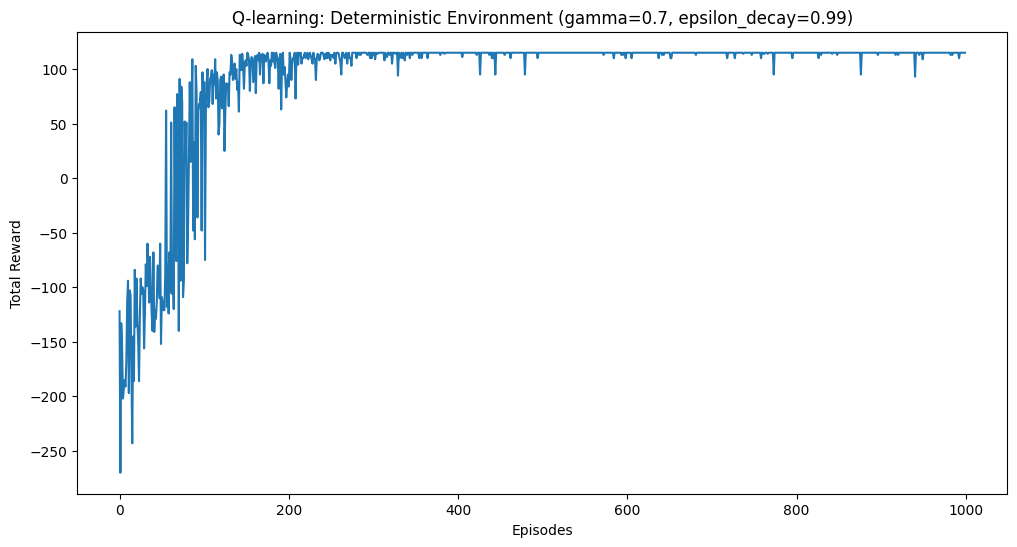

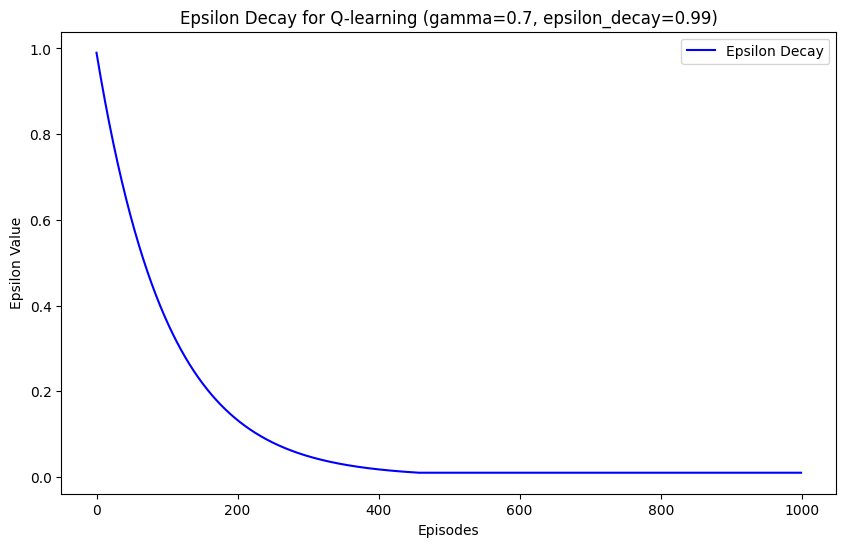

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=0.9 and epsilon_decay=0.95
Episode 1: Total Reward = -133, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -198, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -103, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -122, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -133, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -164, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -181, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -103, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -91, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -155, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -102, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -71, Epsilon = 0.540360087662

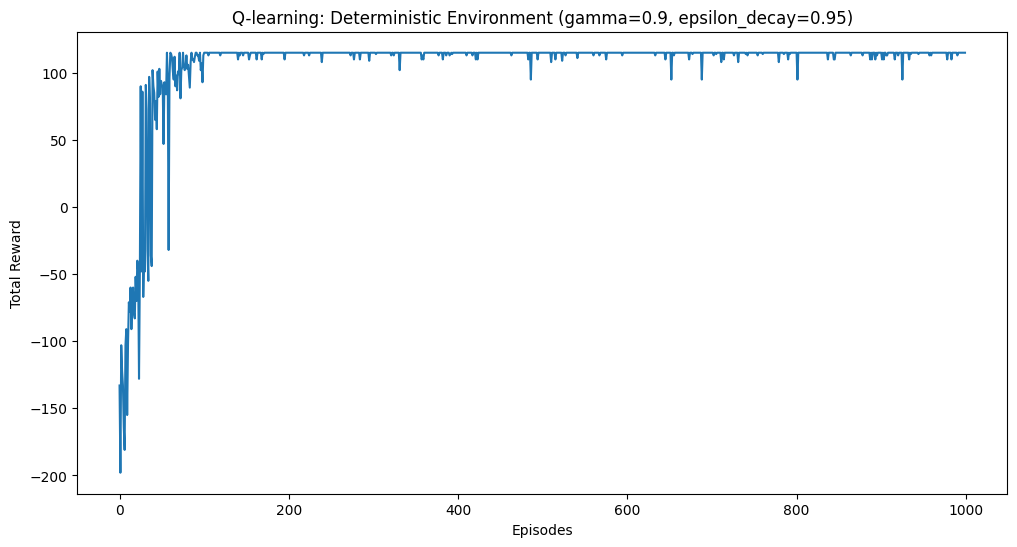

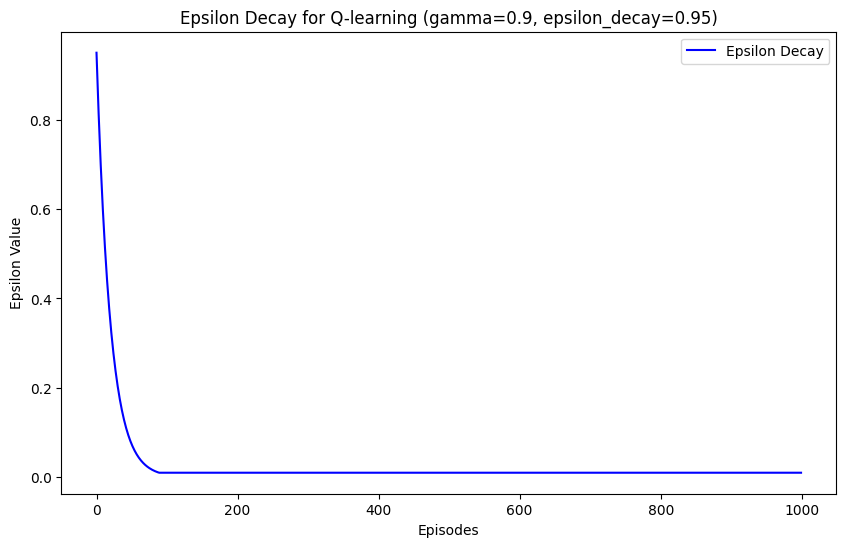

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=0.9 and epsilon_decay=0.99
Episode 1: Total Reward = -106, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -125, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -225, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -96, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -191, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -130, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -186, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -171, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -80, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -99, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -130, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -183, Epsilon = 0.8863848717161291, Itera

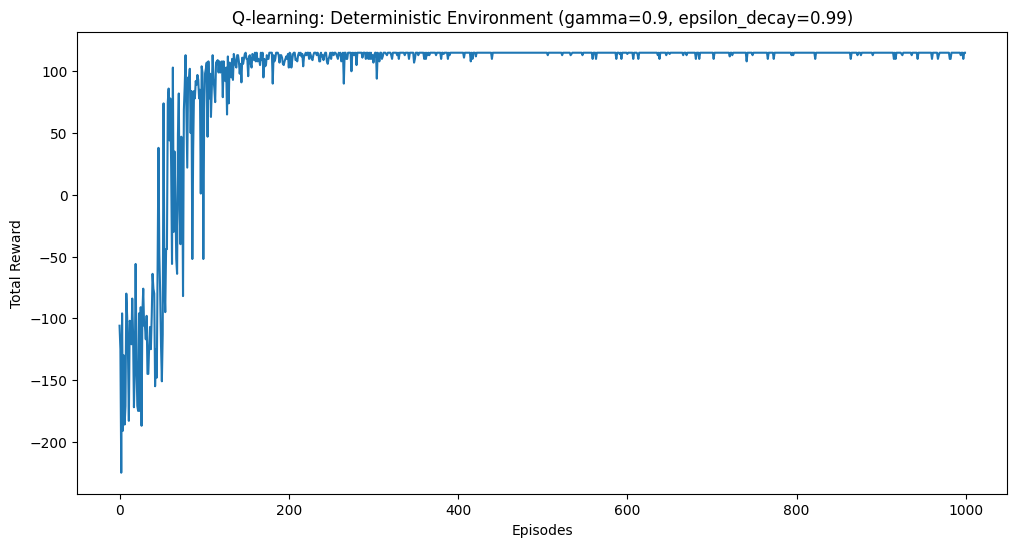

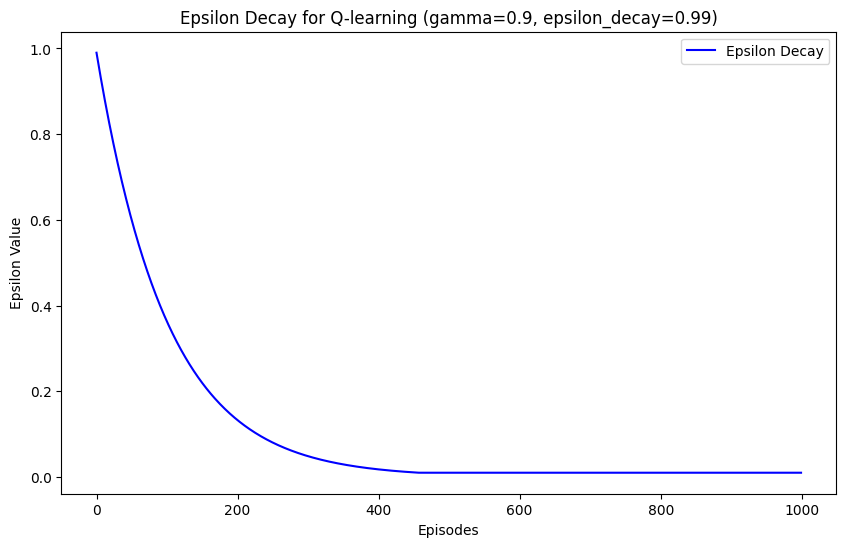

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=1.0 and epsilon_decay=0.95
Episode 1: Total Reward = -176, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -163, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -140, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -187, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -114, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -103, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -102, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -91, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -160, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -110, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -102, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -223, Epsilon = 0.54036008766

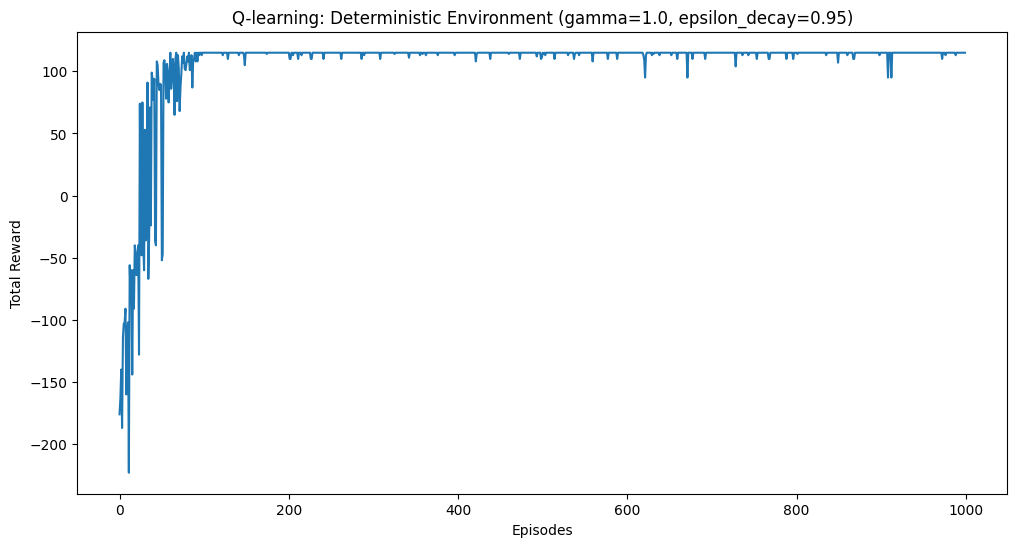

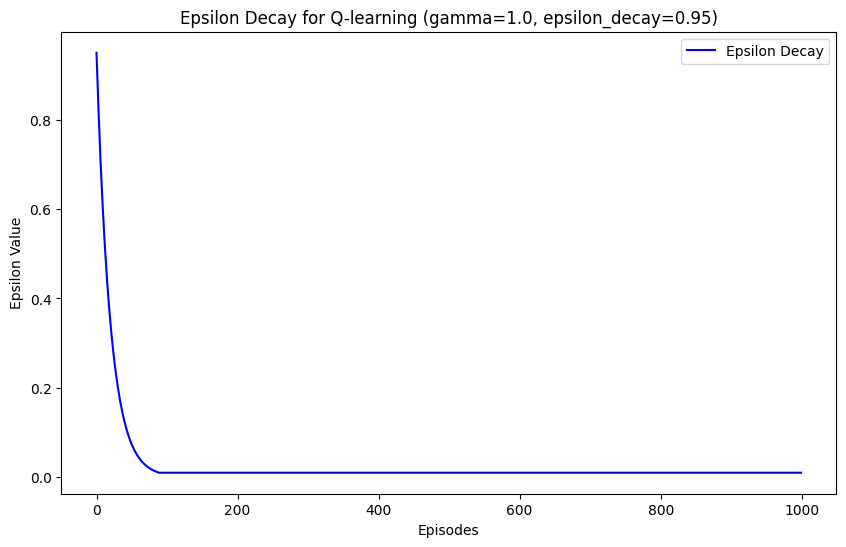

Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma=1.0 and epsilon_decay=0.99
Episode 1: Total Reward = -164, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -149, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -162, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -193, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -164, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -175, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -152, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -130, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -80, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -126, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -102, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -102, Epsilon = 0.8863848717161291, Ite

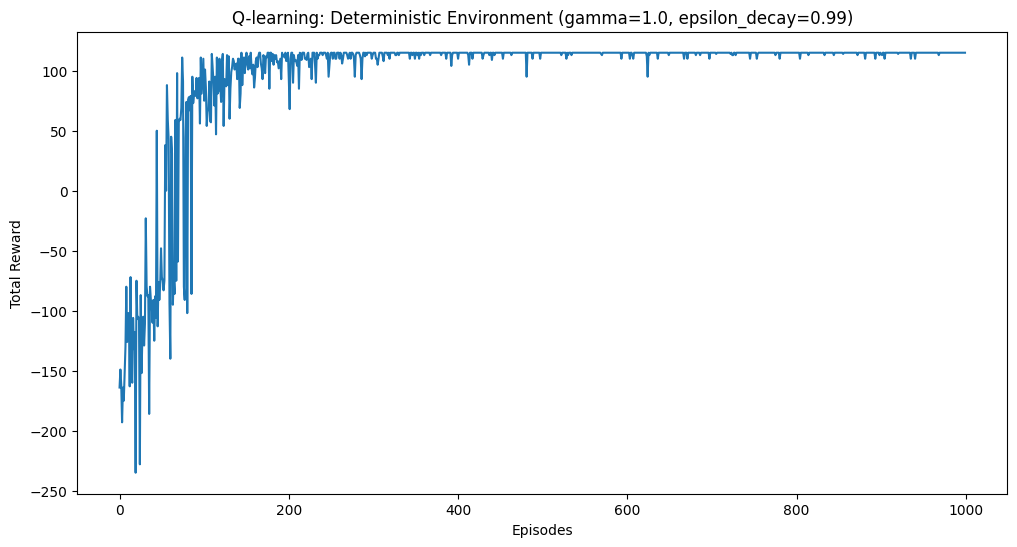

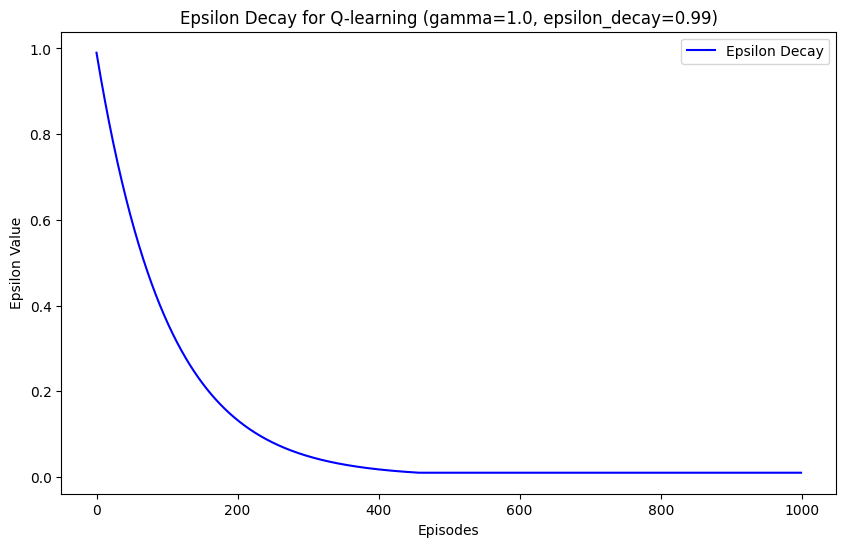

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=0.7 and epsilon_decay=0.95
Episode 1: Total Reward = -176, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -213, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -95, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -94, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -114, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -64, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -92, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -144, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -155, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -72, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -87, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -64, Epsilon = 0.5403600876626365, It

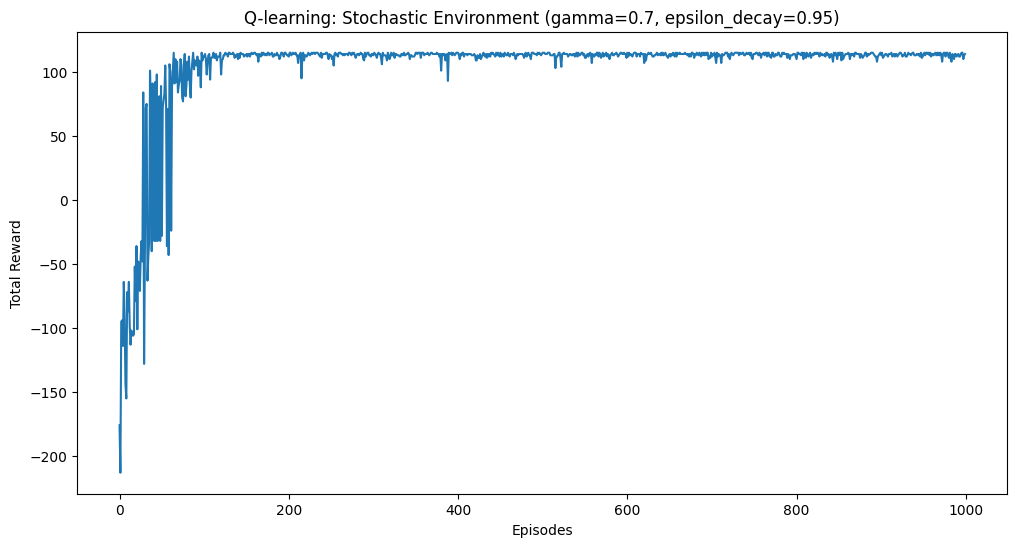

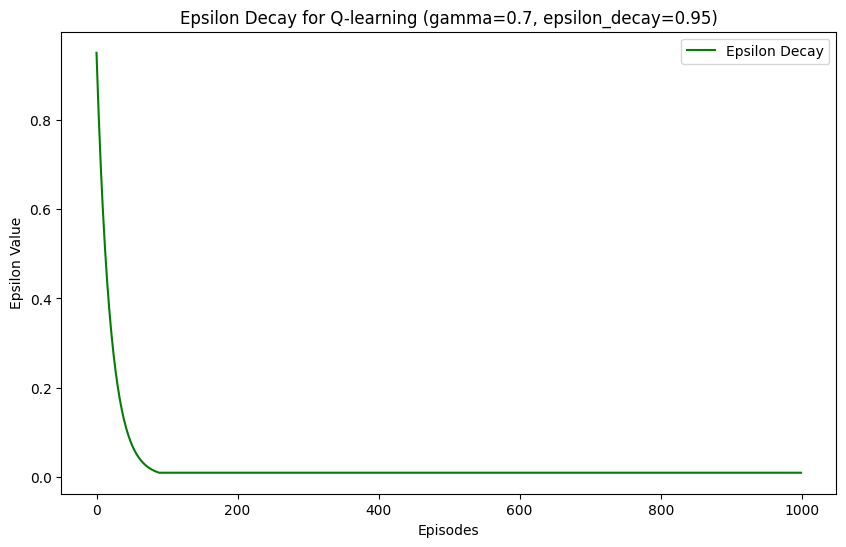

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=0.7 and epsilon_decay=0.99
Episode 1: Total Reward = -118, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -60, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -201, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -122, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -78, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -125, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -99, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -203, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -178, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -147, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -103, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -133, Epsilon = 0.8863848717161291, Iteratio

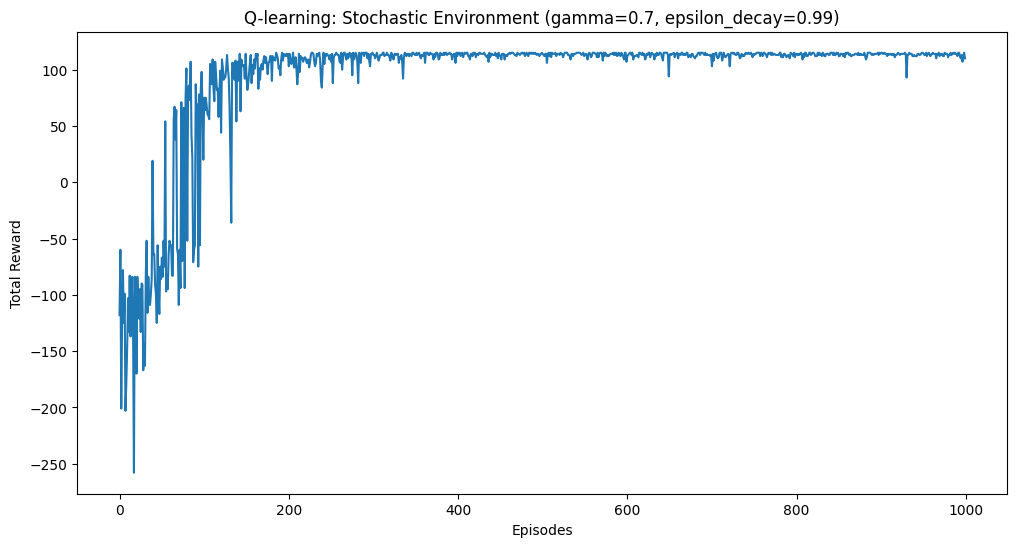

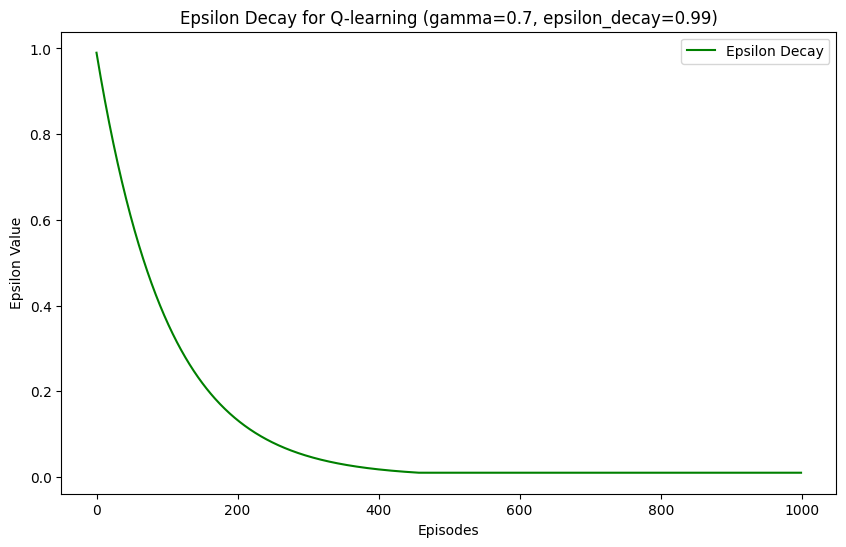

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=0.9 and epsilon_decay=0.95
Episode 1: Total Reward = -84, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -183, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -102, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -152, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -133, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -137, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -118, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -80, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -87, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -75, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -56, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -185, Epsilon = 0.5403600876626365, 

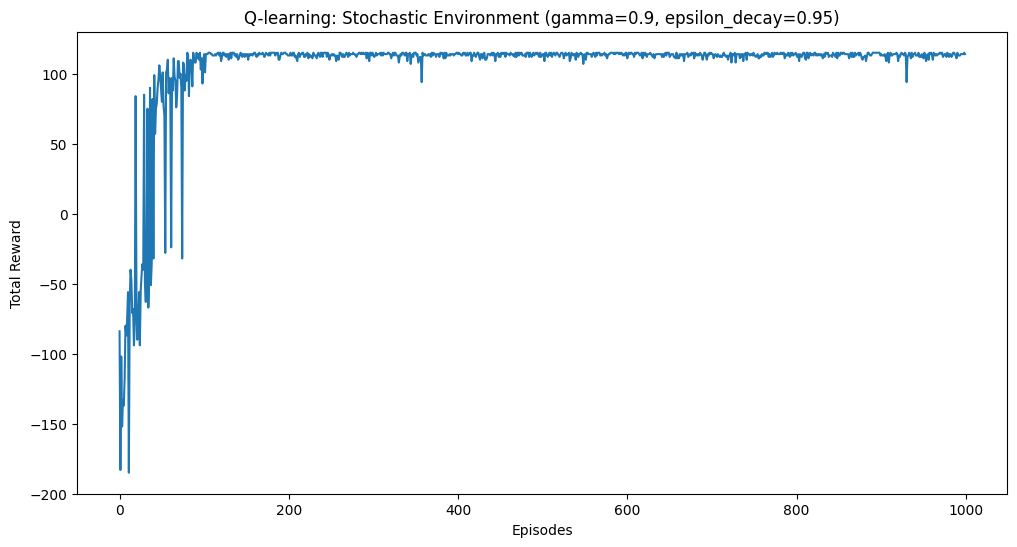

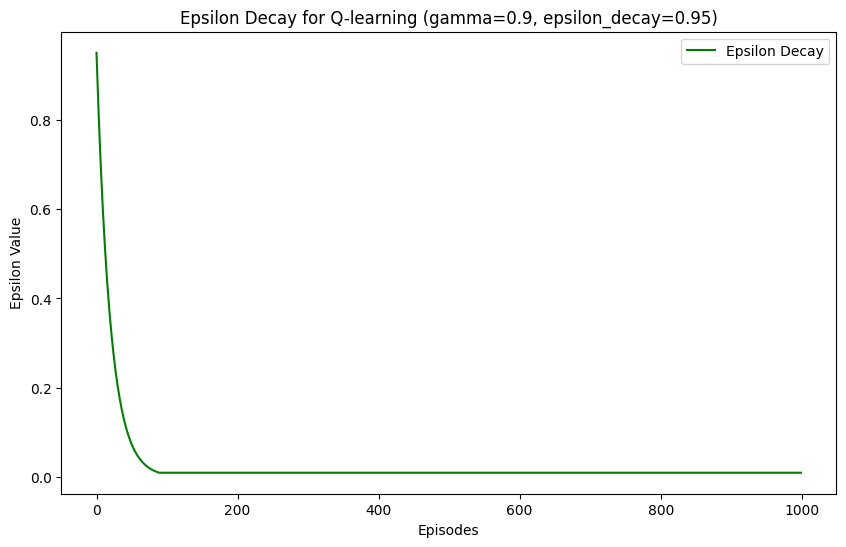

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=0.9 and epsilon_decay=0.99
Episode 1: Total Reward = -146, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -114, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -145, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -95, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -200, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -125, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -167, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -114, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -78, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -116, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -129, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -94, Epsilon = 0.8863848717161291, Iteratio

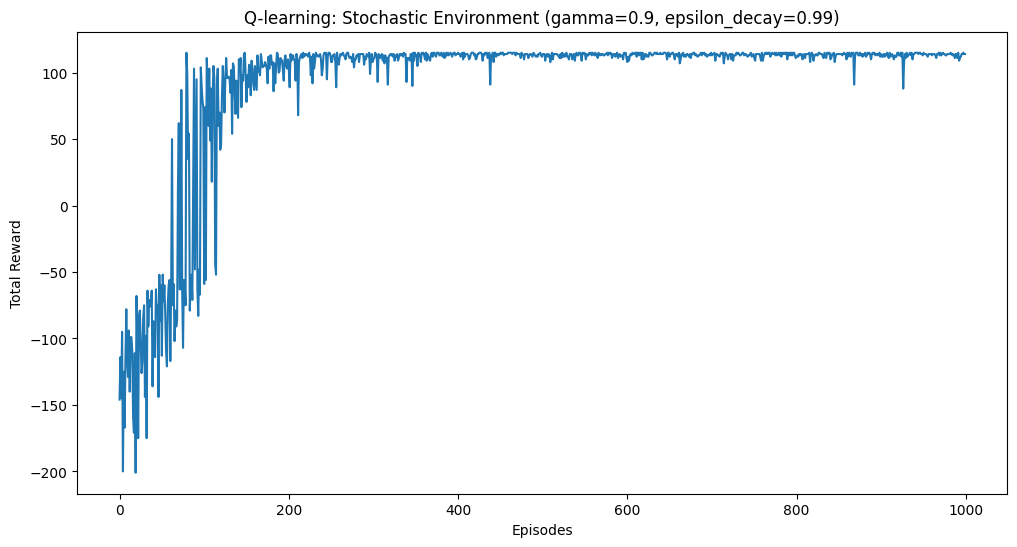

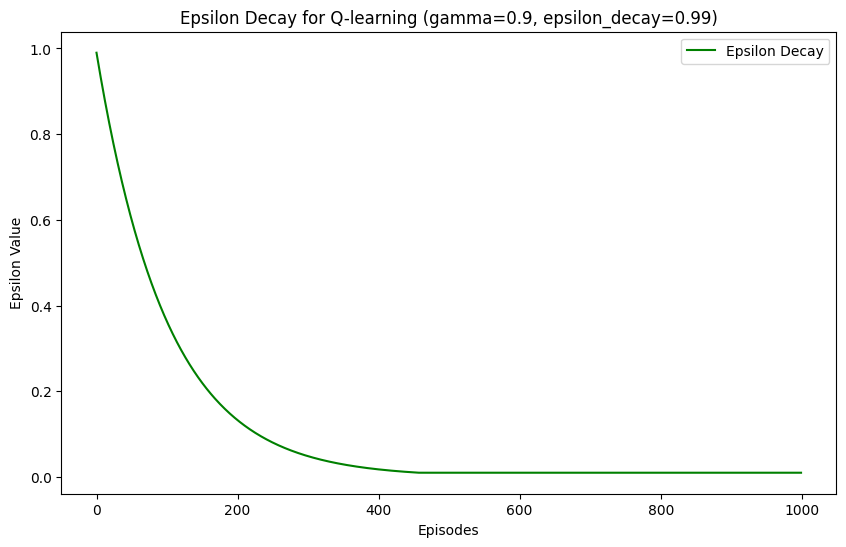

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=1.0 and epsilon_decay=0.95
Episode 1: Total Reward = -80, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -110, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -175, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -84, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -94, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -133, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -84, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -186, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -76, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -156, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -68, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -64, Epsilon = 0.5403600876626365, It

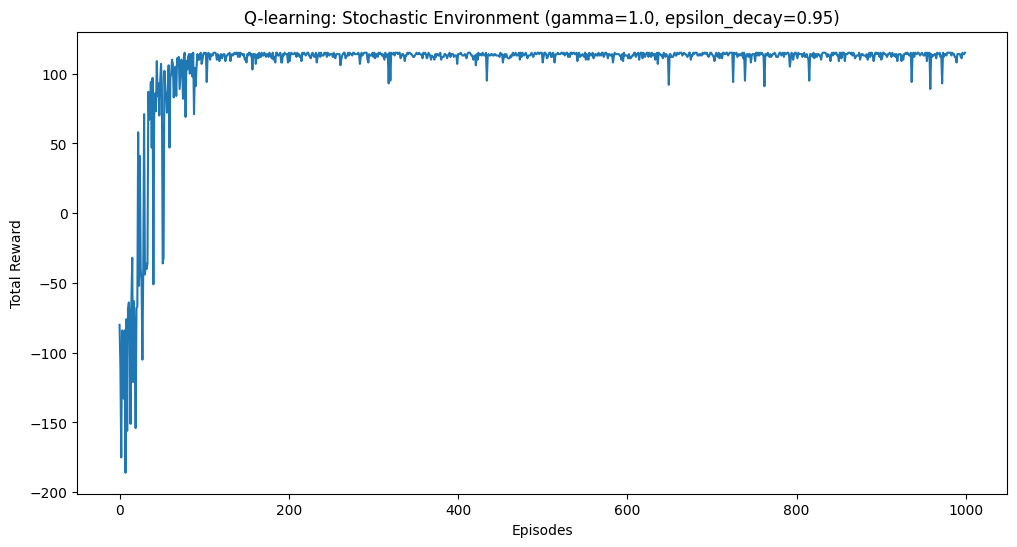

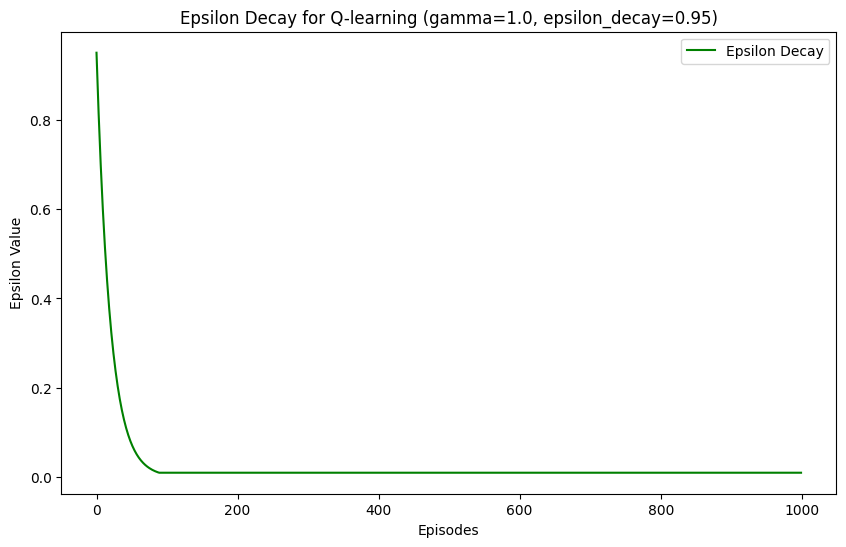

Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma=1.0 and epsilon_decay=0.99
Episode 1: Total Reward = -115, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -109, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -102, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -117, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -103, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -126, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -224, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -239, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -64, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -60, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -166, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -152, Epsilon = 0.8863848717161291, Iterati

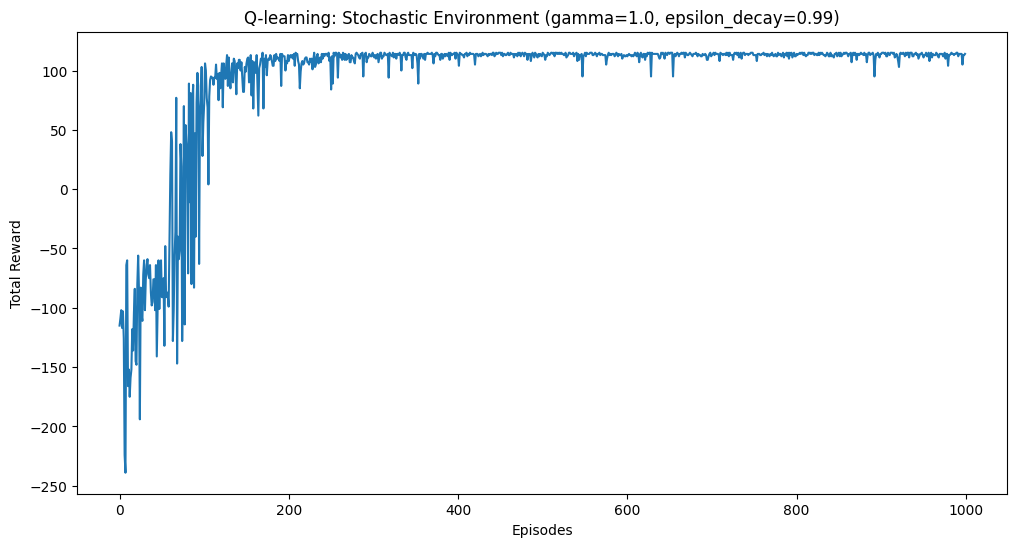

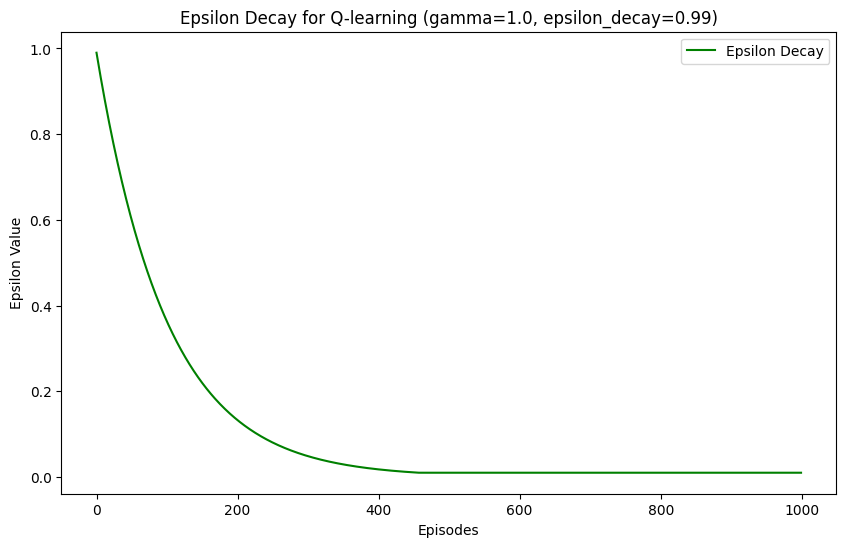

Running SARSA on Deterministic Environment with default hyperparameters
Episode 1: Total Reward = -236, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -118, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -133, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -277, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -157, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -121, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -158, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -160, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -99, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -118, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -80, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -132, Epsilon = 0.5403600876626365, Iterations = 50
Episode 13: Total

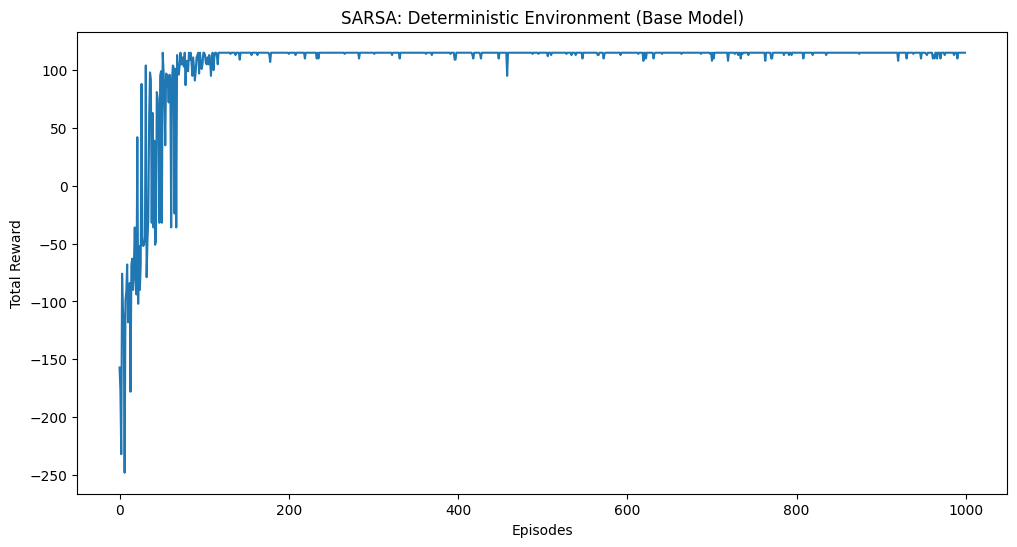

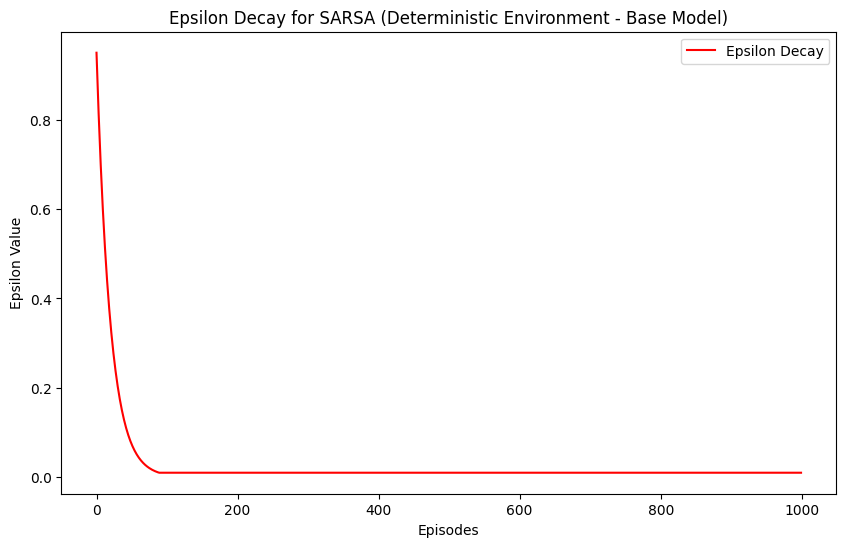

Running SARSA on Stochastic Environment with default hyperparameters
Episode 1: Total Reward = -121, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -122, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -129, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -88, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -110, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -60, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -76, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -122, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -95, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -175, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -75, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -190, Epsilon = 0.5403600876626365, Iterations = 50
Episode 13: Total Rewar

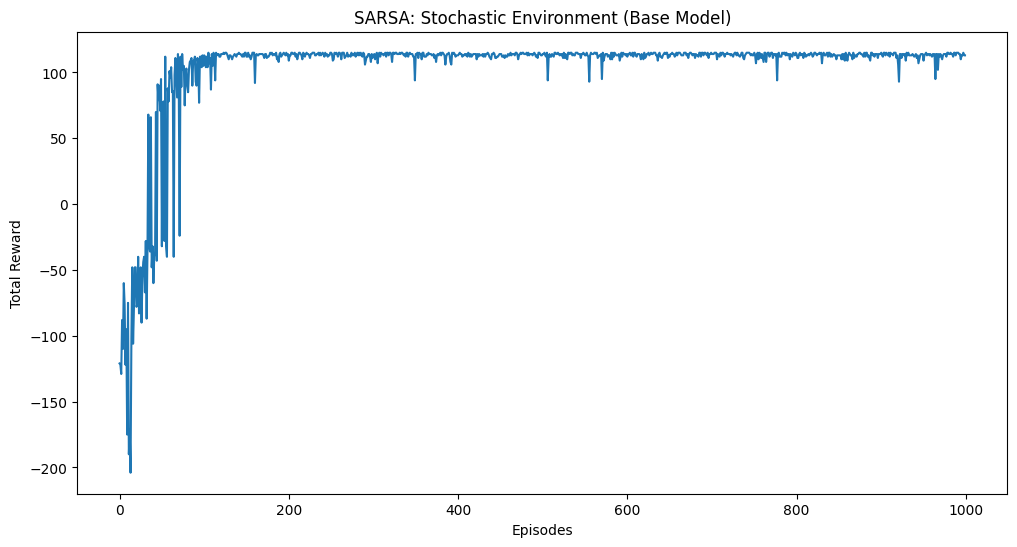

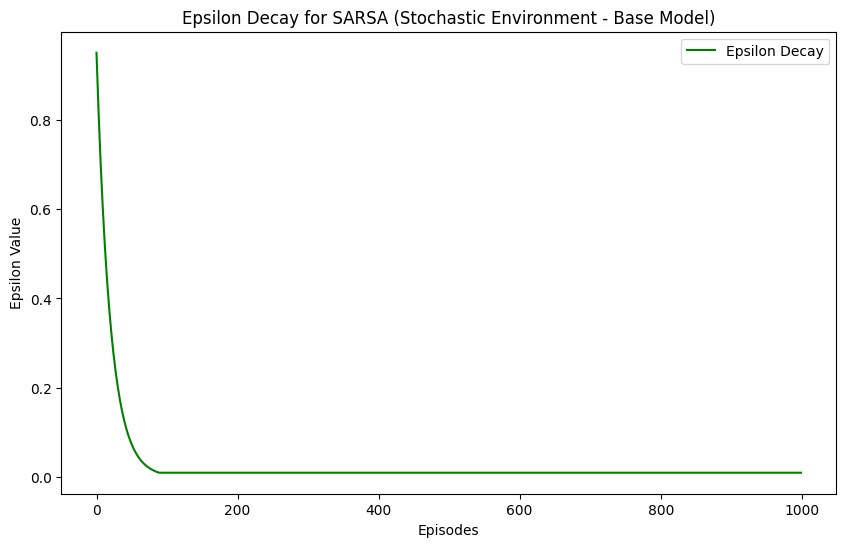

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=0.7 and epsilon_decay=0.95
Episode 1: Total Reward = -164, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -87, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -148, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -125, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -159, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -227, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -174, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -119, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -87, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -103, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -140, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -80, Epsilon = 0.5403600876626365, 

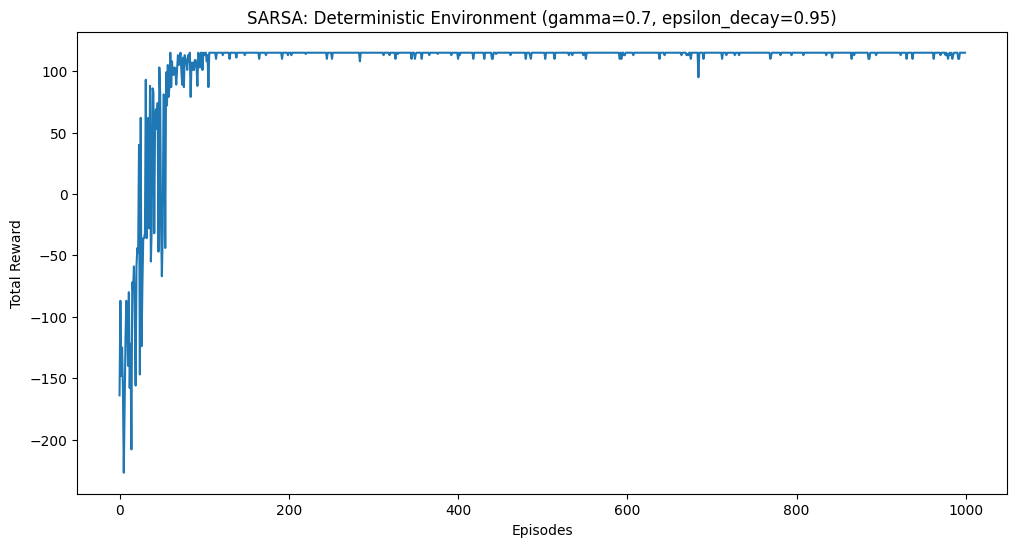

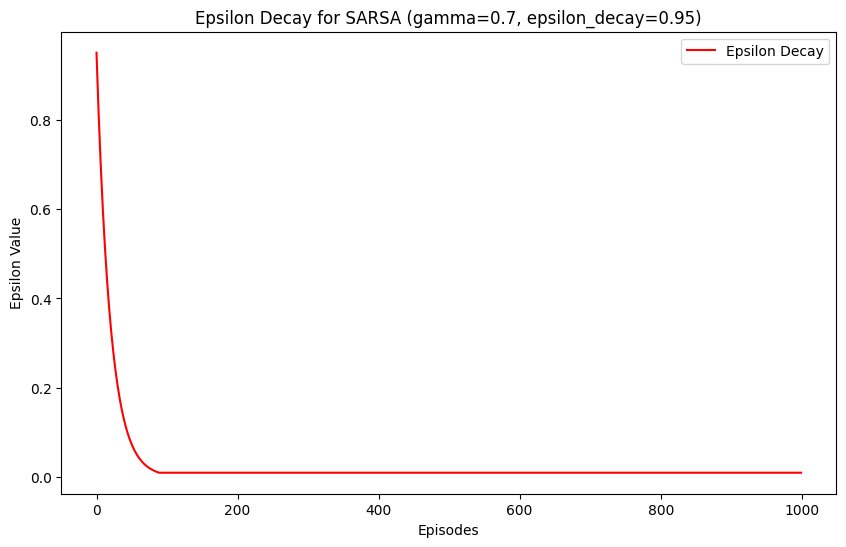

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=0.7 and epsilon_decay=0.99
Episode 1: Total Reward = -102, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -194, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -180, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -76, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -120, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -172, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -126, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -134, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -137, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -111, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -141, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -125, Epsilon = 0.8863848717161291, Iteratio

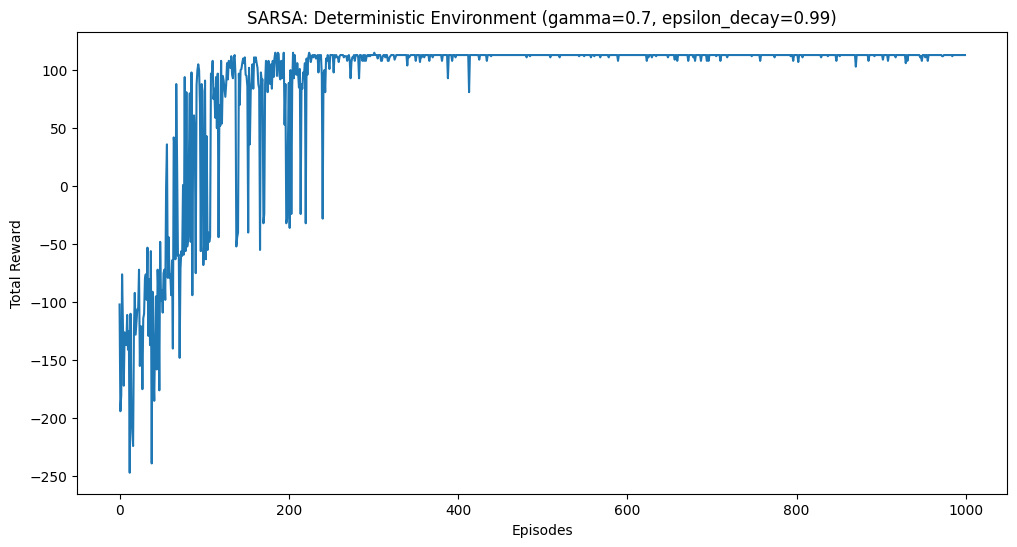

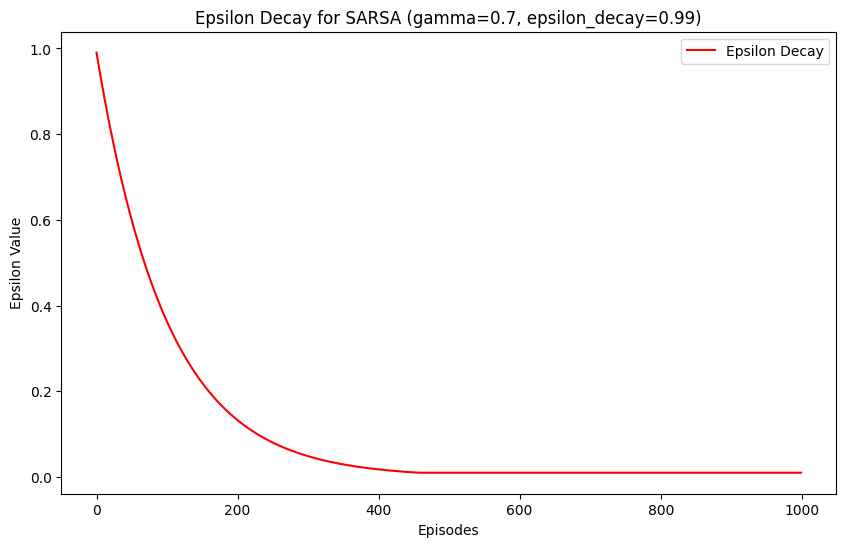

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=0.9 and epsilon_decay=0.95
Episode 1: Total Reward = -80, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -80, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -171, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -134, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -164, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -175, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -174, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -102, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -64, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -79, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -60, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -126, Epsilon = 0.5403600876626365, It

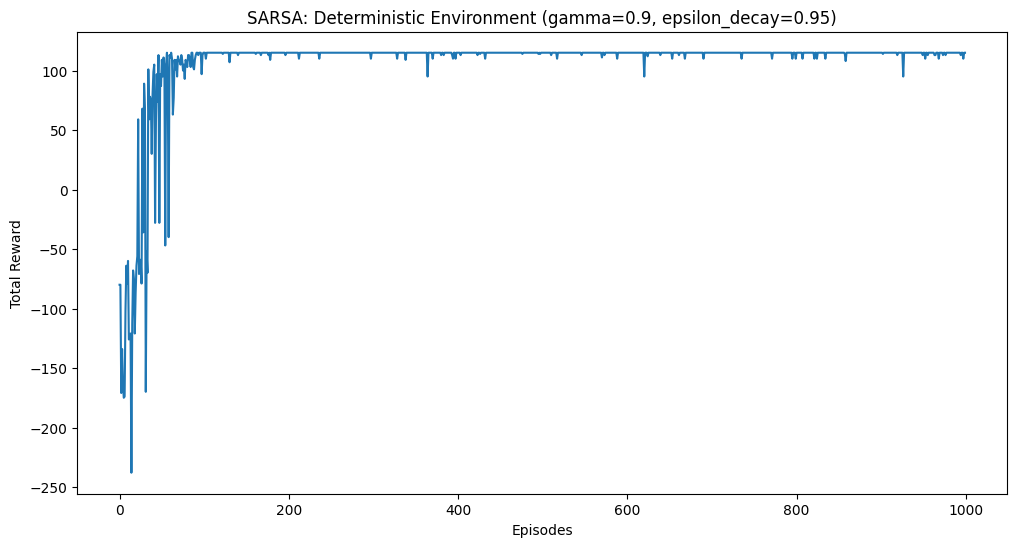

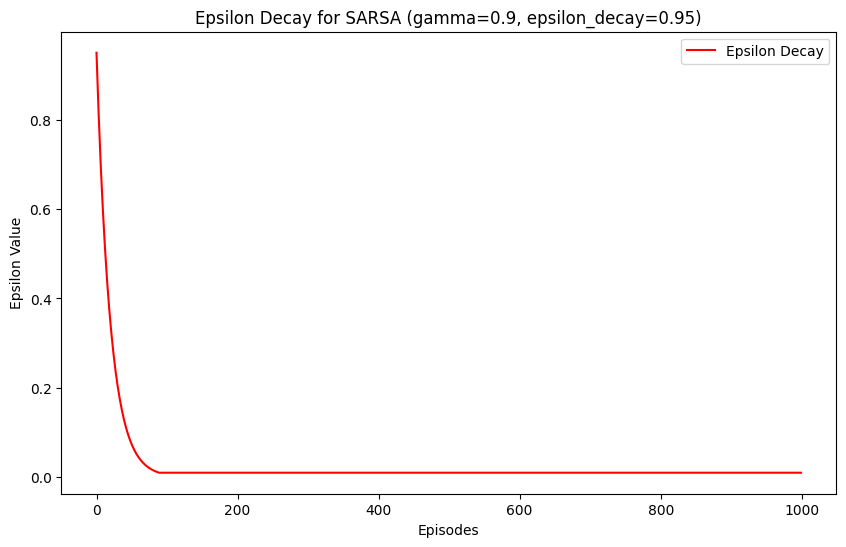

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=0.9 and epsilon_decay=0.99
Episode 1: Total Reward = -179, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -201, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -145, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -102, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -118, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -106, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -190, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -80, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -151, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -166, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -145, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -152, Epsilon = 0.8863848717161291, Iteratio

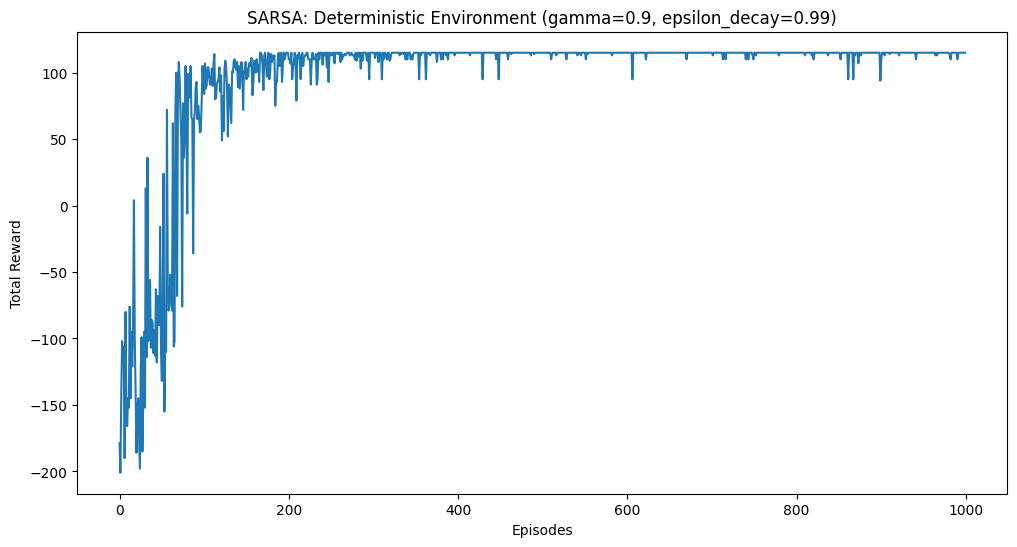

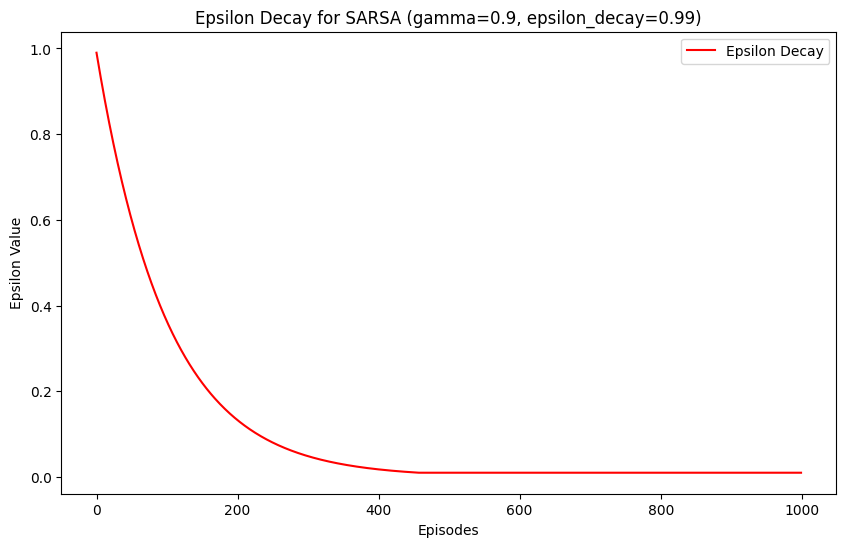

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=1.0 and epsilon_decay=0.95
Episode 1: Total Reward = -185, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -150, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -163, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -190, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -91, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -99, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -211, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -189, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -175, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -86, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -118, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -91, Epsilon = 0.5403600876626365, I

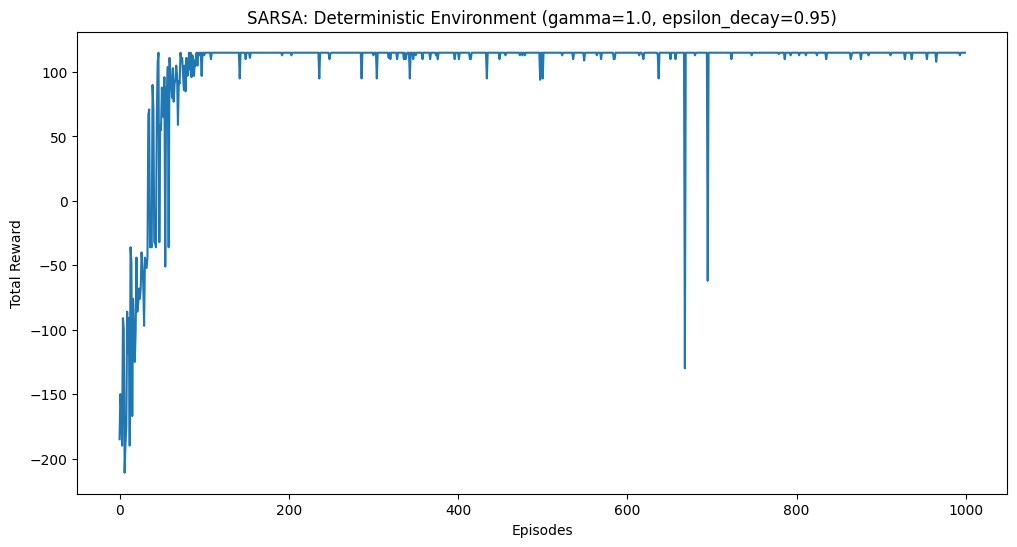

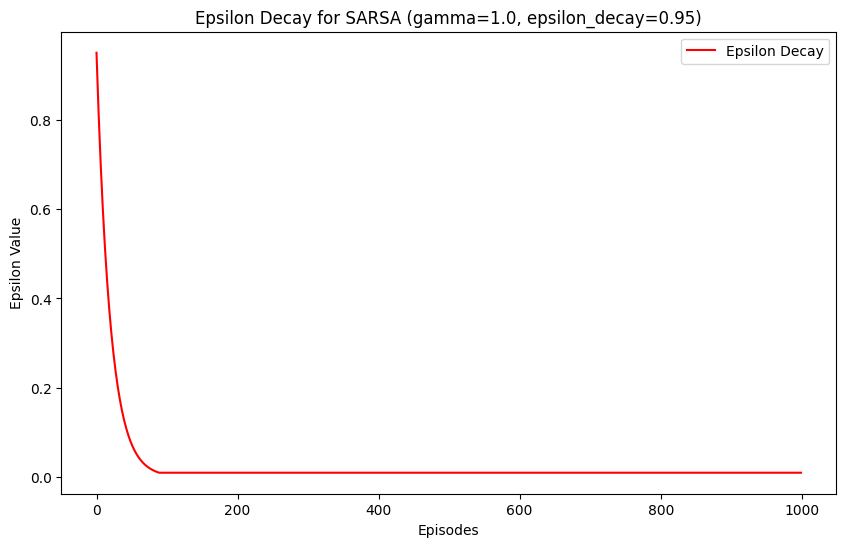

Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma=1.0 and epsilon_decay=0.99
Episode 1: Total Reward = -115, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -209, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -182, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -99, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -115, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -210, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -80, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -88, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -160, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -167, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -122, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -130, Epsilon = 0.8863848717161291, Iterations

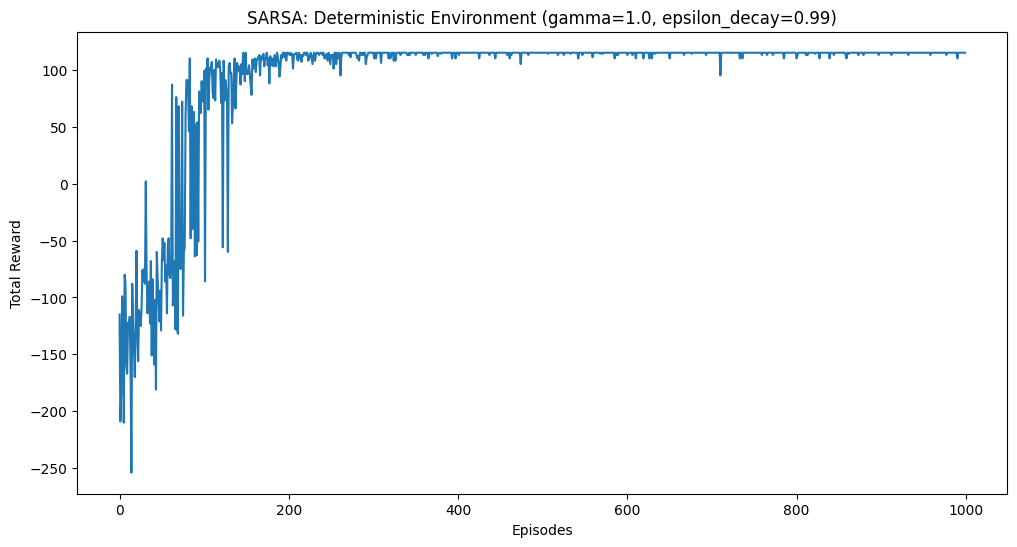

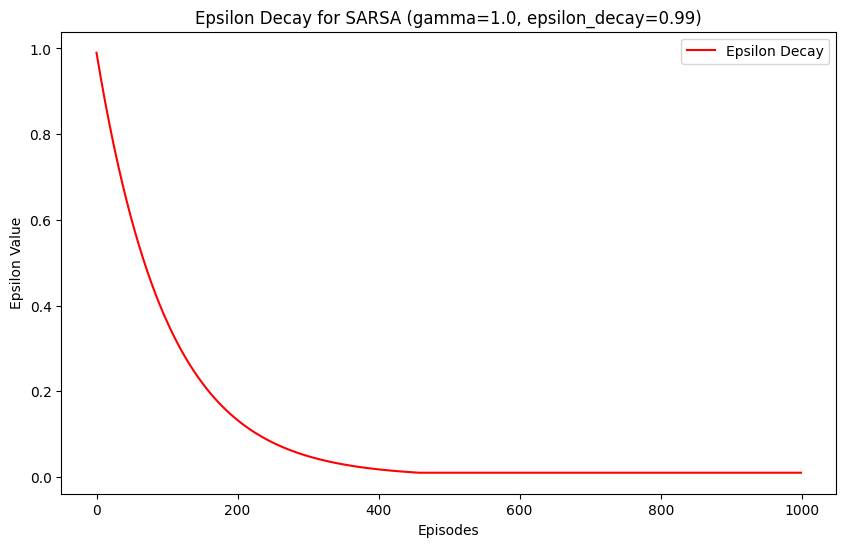

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=0.7 and epsilon_decay=0.95
Episode 1: Total Reward = -153, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -234, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -107, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -72, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -95, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -137, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -80, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -106, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -76, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -214, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -133, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -64, Epsilon = 0.5403600876626365, Itera

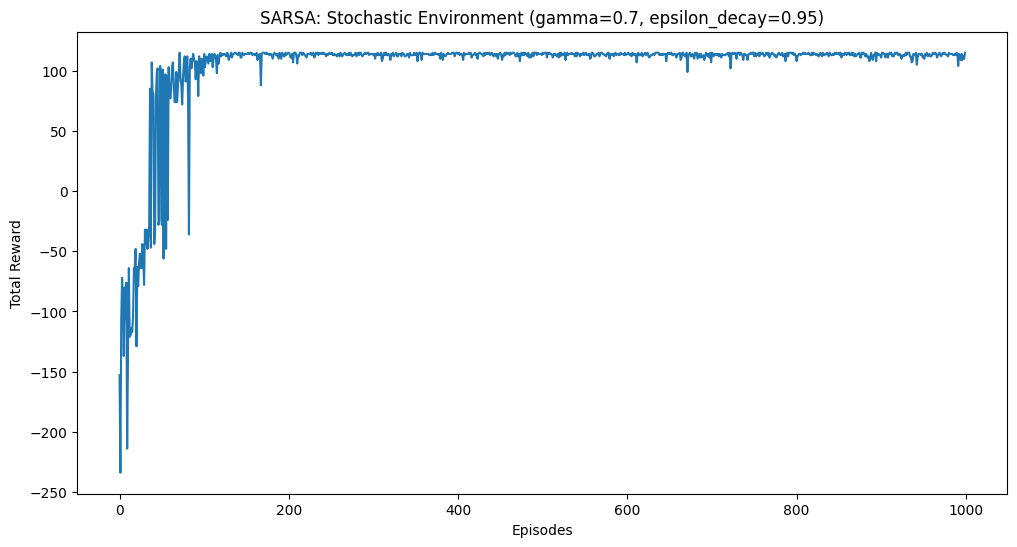

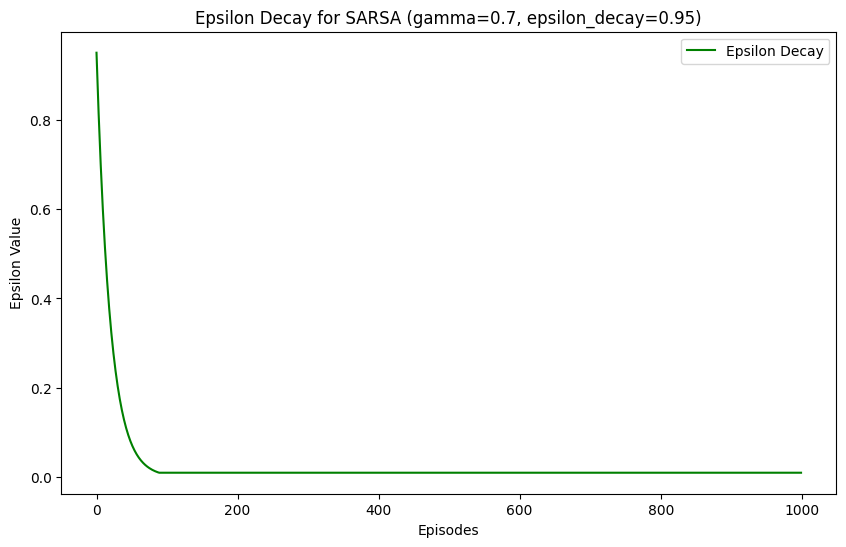

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=0.7 and epsilon_decay=0.99
Episode 1: Total Reward = -210, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -125, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -100, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -170, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -110, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -128, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -103, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -174, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -111, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -114, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -141, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -228, Epsilon = 0.8863848717161291, Iterations

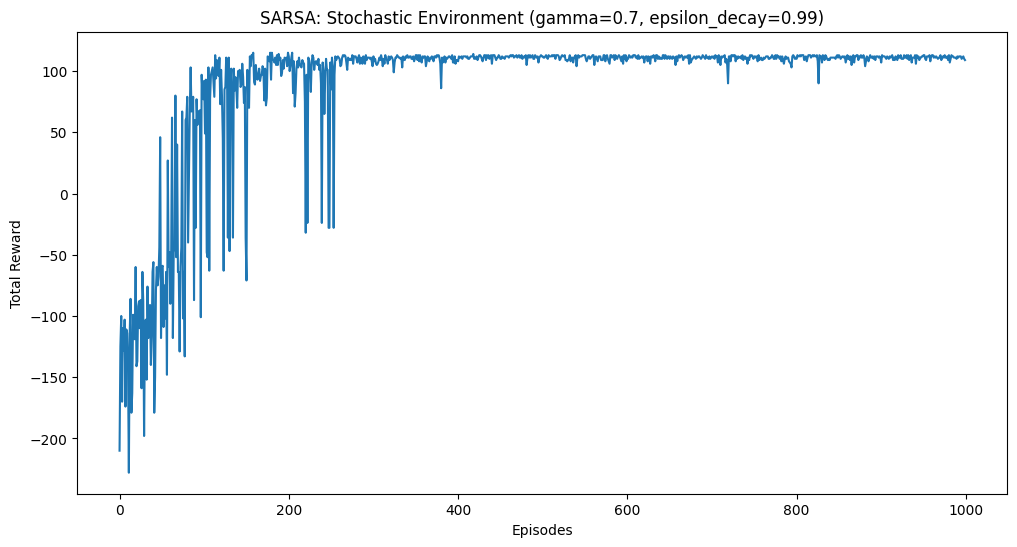

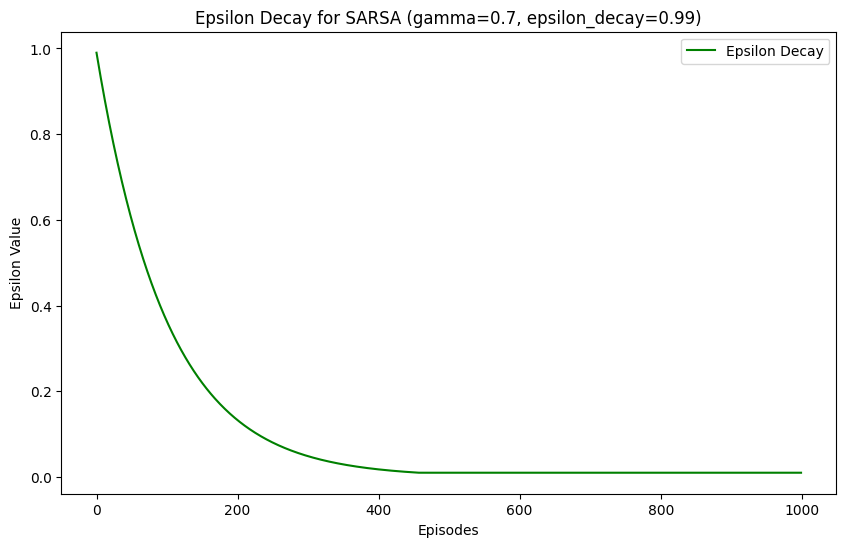

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=0.9 and epsilon_decay=0.95
Episode 1: Total Reward = -152, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -79, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -132, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -187, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -143, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -223, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -105, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -125, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -79, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -164, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -137, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -64, Epsilon = 0.5403600876626365, Ite

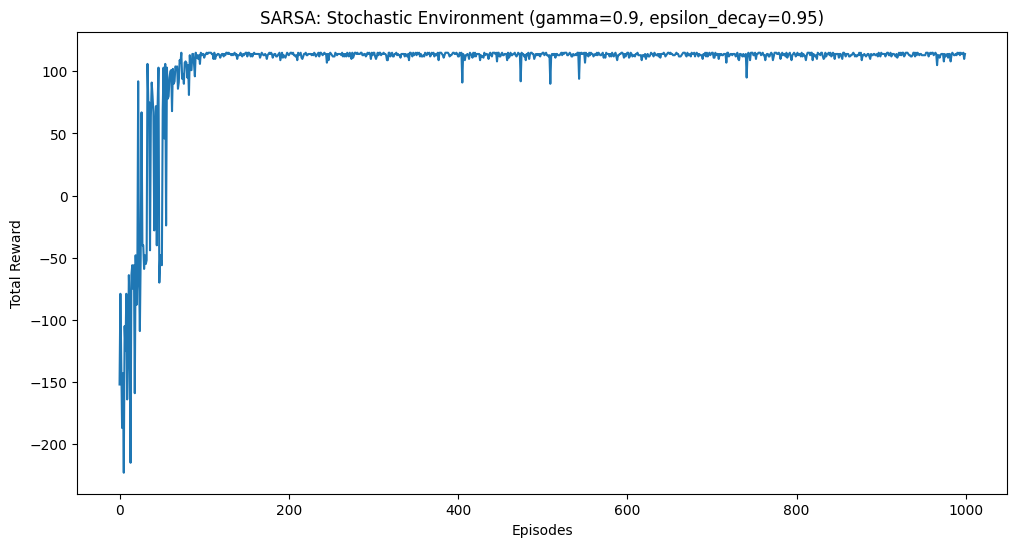

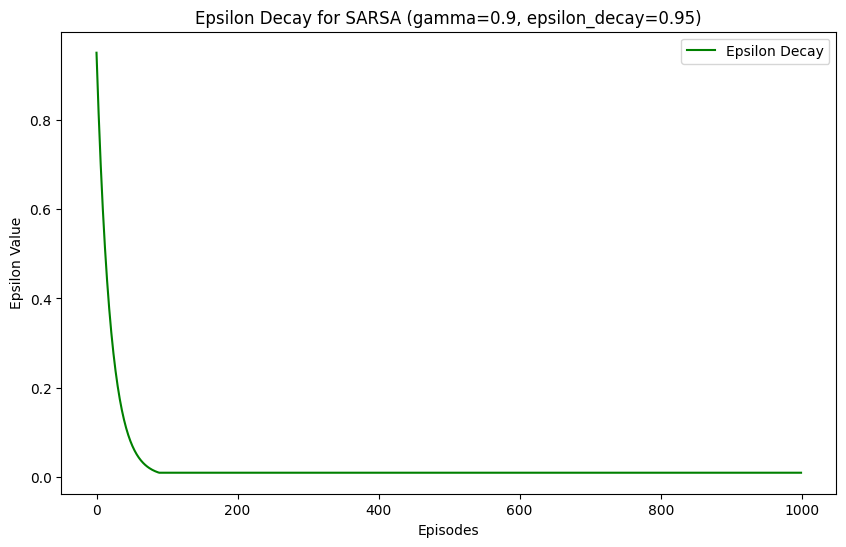

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=0.9 and epsilon_decay=0.99
Episode 1: Total Reward = -113, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -114, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -147, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -118, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -213, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -261, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -83, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -127, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -141, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -68, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -137, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -79, Epsilon = 0.8863848717161291, Iterations = 

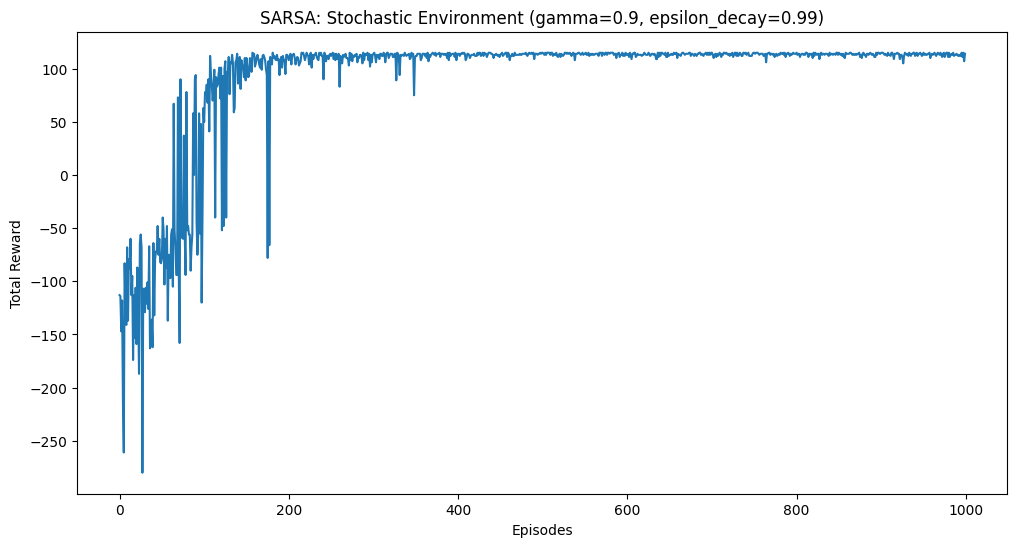

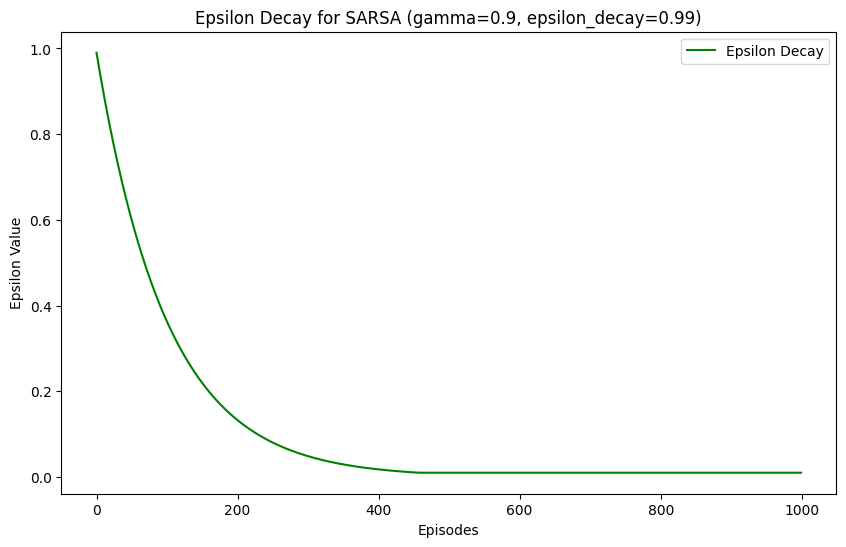

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=1.0 and epsilon_decay=0.95
Episode 1: Total Reward = -95, Epsilon = 0.95, Iterations = 50
Episode 2: Total Reward = -140, Epsilon = 0.9025, Iterations = 50
Episode 3: Total Reward = -109, Epsilon = 0.8573749999999999, Iterations = 50
Episode 4: Total Reward = -205, Epsilon = 0.8145062499999999, Iterations = 50
Episode 5: Total Reward = -94, Epsilon = 0.7737809374999999, Iterations = 50
Episode 6: Total Reward = -83, Epsilon = 0.7350918906249998, Iterations = 50
Episode 7: Total Reward = -80, Epsilon = 0.6983372960937497, Iterations = 50
Episode 8: Total Reward = -182, Epsilon = 0.6634204312890623, Iterations = 50
Episode 9: Total Reward = -94, Epsilon = 0.6302494097246091, Iterations = 50
Episode 10: Total Reward = -60, Epsilon = 0.5987369392383786, Iterations = 50
Episode 11: Total Reward = -125, Epsilon = 0.5688000922764596, Iterations = 50
Episode 12: Total Reward = -72, Epsilon = 0.5403600876626365, Iterati

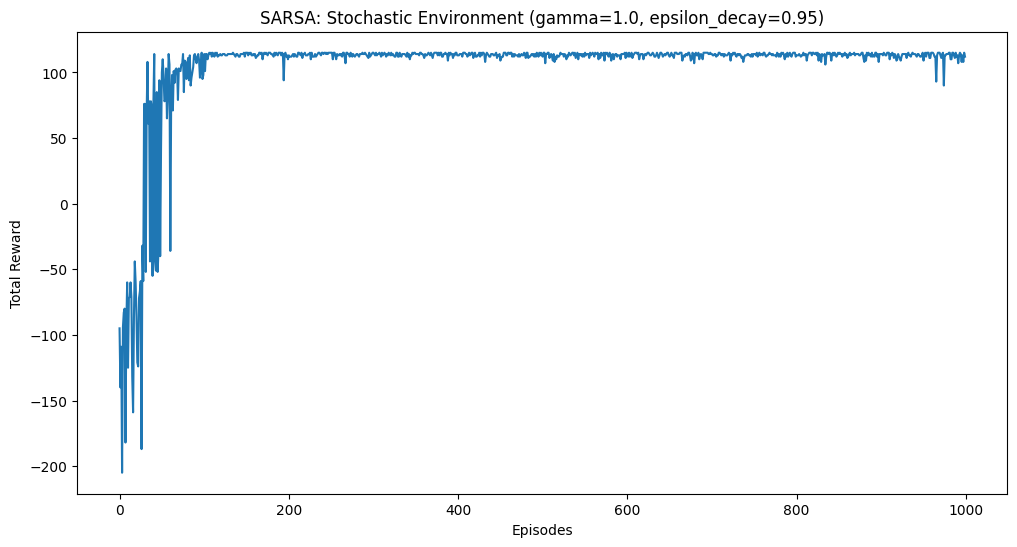

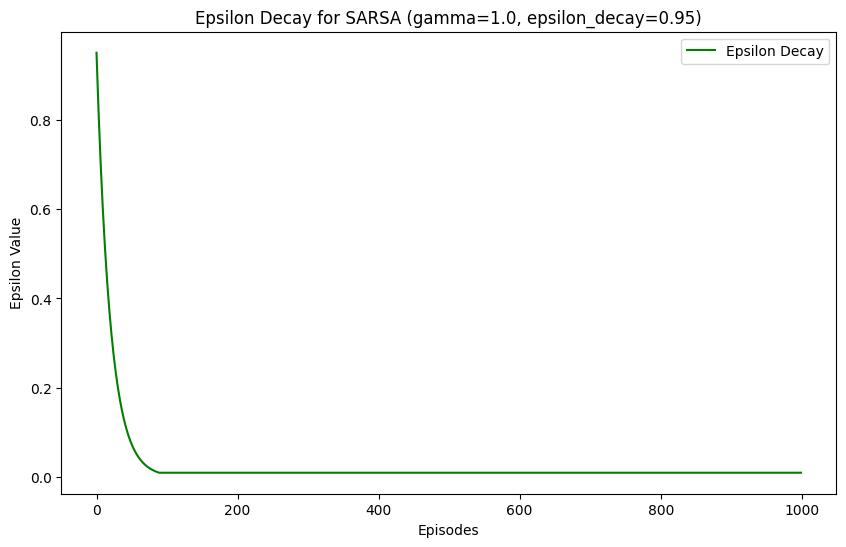

Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma=1.0 and epsilon_decay=0.99
Episode 1: Total Reward = -172, Epsilon = 0.99, Iterations = 50
Episode 2: Total Reward = -159, Epsilon = 0.9801, Iterations = 50
Episode 3: Total Reward = -149, Epsilon = 0.9702989999999999, Iterations = 50
Episode 4: Total Reward = -238, Epsilon = 0.96059601, Iterations = 50
Episode 5: Total Reward = -138, Epsilon = 0.9509900498999999, Iterations = 50
Episode 6: Total Reward = -64, Epsilon = 0.9414801494009999, Iterations = 50
Episode 7: Total Reward = -76, Epsilon = 0.9320653479069899, Iterations = 50
Episode 8: Total Reward = -92, Epsilon = 0.92274469442792, Iterations = 50
Episode 9: Total Reward = -194, Epsilon = 0.9135172474836407, Iterations = 50
Episode 10: Total Reward = -243, Epsilon = 0.9043820750088043, Iterations = 50
Episode 11: Total Reward = -159, Epsilon = 0.8953382542587163, Iterations = 50
Episode 12: Total Reward = -189, Epsilon = 0.8863848717161291, Iterations = 

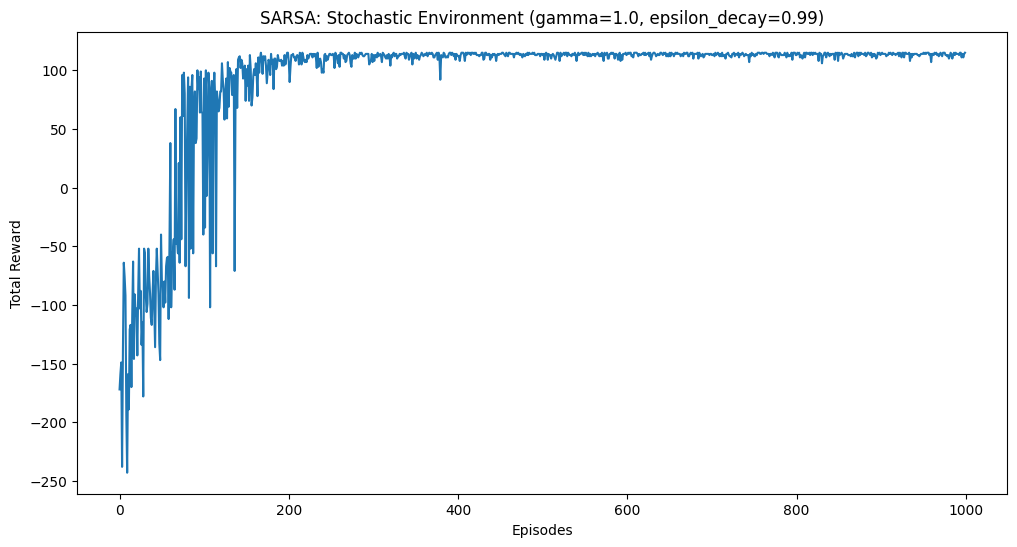

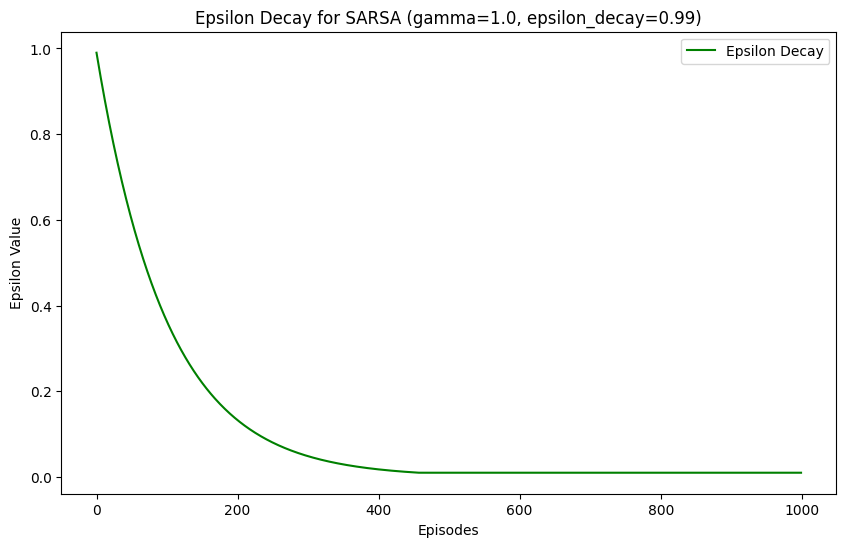

Greedy Evaluation for Deterministic Environment (Q-learning)


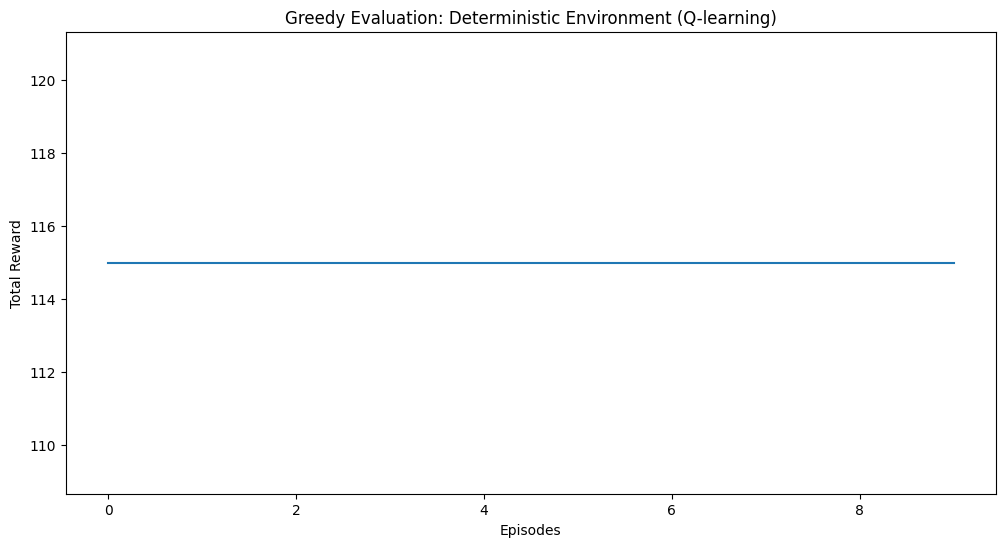

Greedy Evaluation for Stochastic Environment (Q-learning)


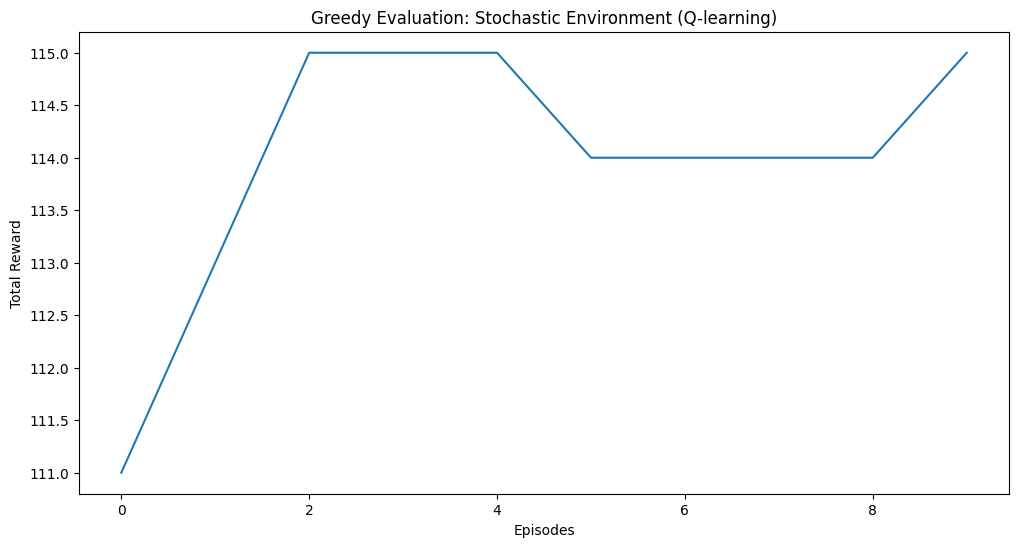

Rendering one episode for Deterministic Environment (Q-learning)


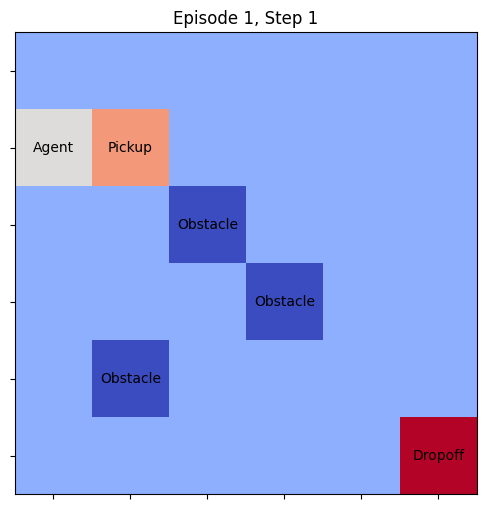

Rendering one episode for Stochastic Environment (Q-learning)


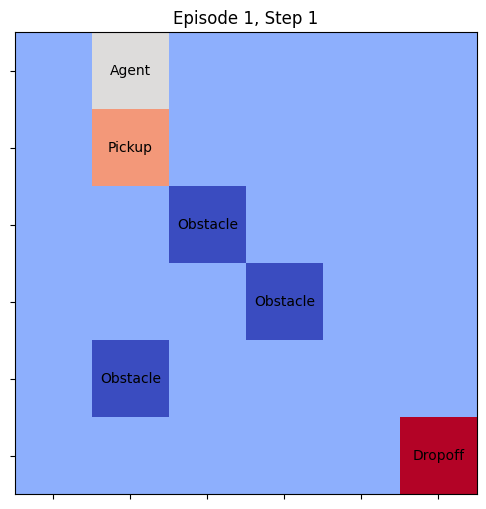

Rendering one episode for Deterministic Environment (SARSA)


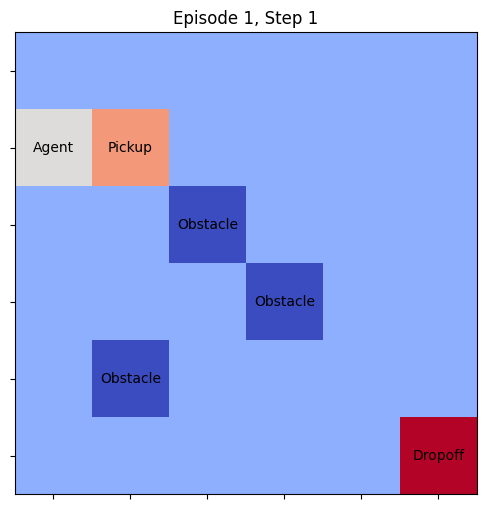

Rendering one episode for Stochastic Environment (SARSA)


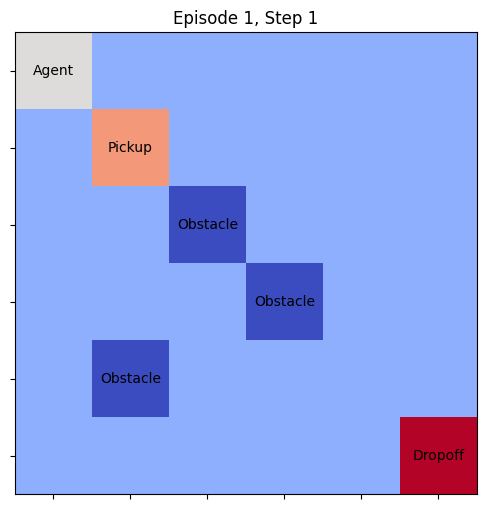


Final Trained Q-table for Deterministic Environment:
{(0, 0, 0): array([ 48.10697922,  23.64173993,  58.6518959 , 111.52      ,
        44.30971984,  43.73388383]), (0, 1, 0): array([ 7.49305726,  5.42652575,  8.73782776, 80.59230327,  8.06498568,
        9.70530192]), (0, 2, 0): array([14.28140749, -0.46990465,  0.99650649,  1.50274247, -0.32476547,
       -2.20549781]), (0, 3, 0): array([ 0.93021168, -0.271     , -0.2       , -0.15517975, -0.95225166,
       -0.95      ]), (1, 3, 0): array([ 5.67137153, -0.37167791, -0.44302798, -0.19      , -0.51598416,
       -2.51137762]), (1, 2, 0): array([51.81824987,  0.74259804, -0.42851   , -7.38041664, -0.06364466,
        0.09073316]), (1, 1, 0): array([ 51.66712648,  20.08817931,  38.30256019,  19.26054733,
       114.24      ,  43.92227026]), (1, 4, 0): array([ 0.35834439,  0.        , -0.43661   , -0.19      , -0.5       ,
       -0.49489927]), (0, 4, 0): array([-0.2       , -0.43661   , -0.1       , -0.25717703, -0.5       ,
       -0.

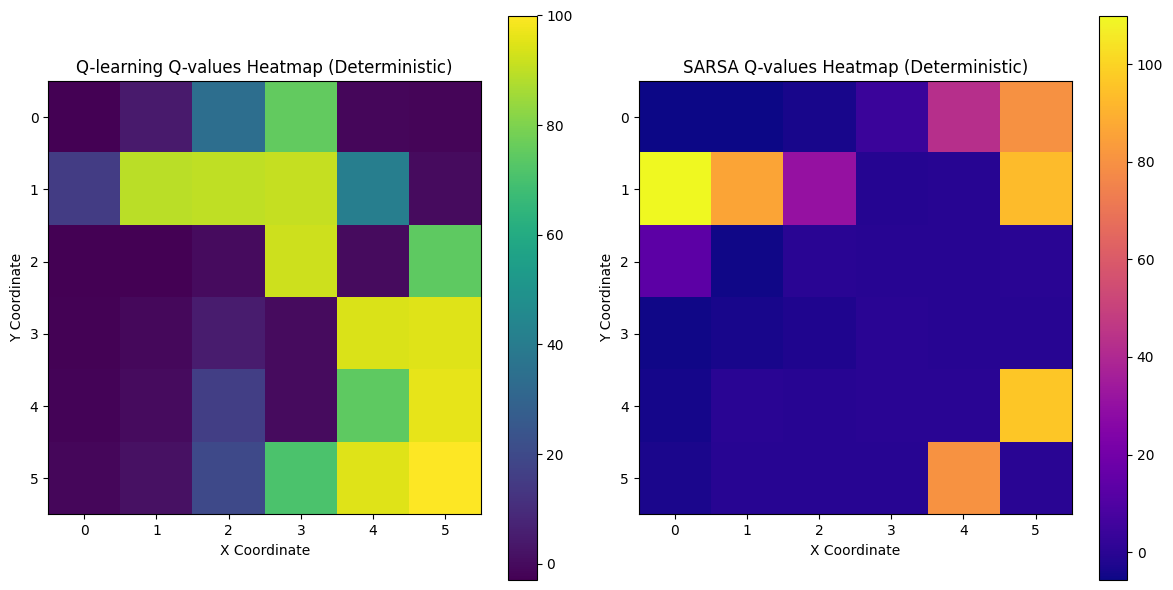

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt
import pickle
import os

# Initializing the parameters for Q-Leaning and SARSA
alpha = 0.1
epsilon_min = 0.01
episodes = 1000
max_timesteps = 50

# Initializing Q-table and SARSA table
Q_det = {}
Q_stoch = {}
SARSA_det = {}
SARSA_stoch = {}

# Q-learning update function
def update_Q(state, action, reward, next_state, done, Q_table, gamma):
    if state not in Q_table:
        Q_table[state] = np.zeros(6)
    if next_state not in Q_table:
        Q_table[next_state] = np.zeros(6)

    # Q-learning update rule
    max_future_q = np.max(Q_table[next_state]) if not done else 0
    Q_table[state][action] += alpha * (reward + gamma * max_future_q - Q_table[state][action])

# SARSA update function
def update_SARSA(state, action, reward, next_state, next_action, done, SARSA_table, gamma):
    if state not in SARSA_table:
        SARSA_table[state] = np.zeros(6)
    if next_state not in SARSA_table:
        SARSA_table[next_state] = np.zeros(6)

    # SARSA update rule
    next_q = SARSA_table[next_state][next_action] if not done else 0
    SARSA_table[state][action] += alpha * (reward + gamma * next_q - SARSA_table[state][action])


# Greedy action selection function
def choose_action(state, epsilon, Q_table):
    if random.uniform(0, 1) < epsilon:
        return random.choice([0, 1, 2, 3, 4, 5])
    else:
        if state not in Q_table:
            Q_table[state] = np.zeros(6)
        return np.argmax(Q_table[state])

# Deterministic Warehouse Environment
class DeterministicWarehouseEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.size = 6
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Tuple((spaces.Discrete(self.size), spaces.Discrete(self.size), spaces.Discrete(2)))
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.pickup = (1, 1)
        self.dropoff = (5, 5)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        self.carrying = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return (self.pos[0], self.pos[1], self.carrying)

    def step(self, action):
        x, y = self.pos
        if action == 0:
            new_pos = (x, max(0, y - 1))
        elif action == 1:
            new_pos = (x, min(self.size - 1, y + 1))
        elif action == 2:
            new_pos = (max(0, x - 1), y)
        elif action == 3:
            new_pos = (min(self.size - 1, x + 1), y)
        elif action == 4 and self.pos == self.pickup and self.carrying == 0:
            self.carrying = 1
            return self._get_obs(), 25, False, False, {}
        elif action == 5 and self.pos == self.dropoff and self.carrying == 1:
            return self._get_obs(), 100, True, False, {}
        elif action in [4, 5]:
            return self._get_obs(), -5, False, False, {}

        if new_pos in self.obstacles:
            reward = -20
        else:
            self.pos = new_pos
            reward = -1

        return self._get_obs(), reward, False, False, {}

    def render(self):
        grid = np.zeros((self.size, self.size))
        for obstacle in self.obstacles:
            grid[obstacle] = -1
        grid[self.pickup] = 2
        grid[self.dropoff] = 3
        grid[self.pos] = 1 if self.carrying == 0 else 4
        print(grid)

# Stochastic Warehouse Environment
class StochasticWarehouseEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.size = 6
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Tuple((spaces.Discrete(self.size), spaces.Discrete(self.size), spaces.Discrete(2)))
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.pickup = (1, 1)
        self.dropoff = (5, 5)
        self.reset()

    def reset(self):
        self.pos = (0, 0)
        self.carrying = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return (self.pos[0], self.pos[1], self.carrying)

    def step(self, action):
        if random.random() < 0.1:
            return self._get_obs(), -1, False, False, {}

        x, y = self.pos
        if action == 0:
            new_pos = (x, max(0, y - 1))
        elif action == 1:
            new_pos = (x, min(self.size - 1, y + 1))
        elif action == 2:
            new_pos = (max(0, x - 1), y)
        elif action == 3:
            new_pos = (min(self.size - 1, x + 1), y)
        elif action == 4 and self.pos == self.pickup and self.carrying == 0:
            self.carrying = 1
            return self._get_obs(), 25, False, False, {}
        elif action == 5 and self.pos == self.dropoff and self.carrying == 1:
            return self._get_obs(), 100, True, False, {}
        elif action in [4, 5]:
            return self._get_obs(), -5, False, False, {}

        if new_pos in self.obstacles:
            reward = -20
        else:
            self.pos = new_pos
            reward = -1

        return self._get_obs(), reward, False, False, {}

    def render(self):
        grid = np.zeros((self.size, self.size))
        for obstacle in self.obstacles:
            grid[obstacle] = -1
        grid[self.pickup] = 2
        grid[self.dropoff] = 3
        grid[self.pos] = 1 if self.carrying == 0 else 4
        print(grid)

# Running Q-learning or SARSA on the environments
def run_algorithm(env, gamma, epsilon_decay_rate, Q_table, algorithm_type="Q-learning"):
    epsilon = 1.0
    total_rewards = []
    epsilon_values = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        if algorithm_type == "SARSA":
            action = choose_action(state, epsilon, Q_table)

        for t in range(max_timesteps):
            if algorithm_type == "Q-learning":
                action = choose_action(state, epsilon, Q_table)
                next_state, reward, done, _, _ = env.step(action)
                update_Q(state, action, reward, next_state, done, Q_table, gamma)
            elif algorithm_type == "SARSA":
                next_state, reward, done, _, _ = env.step(action)
                next_action = choose_action(next_state, epsilon, Q_table)
                update_SARSA(state, action, reward, next_state, next_action, done, Q_table, gamma)
                action = next_action

            state = next_state
            total_reward += reward

            if done:
                break
        epsilon = max(epsilon_min, epsilon * epsilon_decay_rate)
        total_rewards.append(total_reward)
        epsilon_values.append(epsilon)

        # Printing total reward, epsilon value and timesteps
        print(f"Episode {episode + 1}: Total Reward = {total_reward}, Epsilon = {epsilon}, Iterations = {t+1}")
    return total_rewards, epsilon_values


    return total_rewards, epsilon_values

# Greedy evaluation function
def evaluate_greedy(env, Q_table, num_episodes=10):
    total_rewards = []
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q_table.get(state, np.zeros(6)))
            next_state, reward, done, _, _ = env.step(action)
            total_reward += reward
            state = next_state

        total_rewards.append(total_reward)

    return total_rewards
# Render one episode for Q-learning or SARSA (Greedy)
def render_one_episode(env, Q_table, SARSA_table=None, algorithm="Q-learning", gamma=0.7):
    state, _ = env.reset()
    done = False
    total_reward = 0
    step = 0

    fig, ax = plt.subplots(figsize=(6, 6))

    if algorithm == "Q-learning":
        action = np.argmax(Q_table.get(state, np.zeros(6)))
    elif algorithm == "SARSA":
        action = np.argmax(SARSA_table.get(state, np.zeros(6)))

    while not done:
        next_state, reward, done, _, _ = env.step(action)

        if algorithm == "Q-learning":
            # Update the Q-table using Q-learning update rule
            update_Q(state, action, reward, next_state, done, Q_table, gamma)
            action = np.argmax(Q_table.get(next_state, np.zeros(6)))
        elif algorithm == "SARSA":
            next_action = np.argmax(SARSA_table.get(next_state, np.zeros(6)))
            # Update the SARSA table using SARSA update rule
            update_SARSA(state, action, reward, next_state, next_action, done, SARSA_table, gamma)
            action = next_action  s

        total_reward += reward
        state = next_state

        ax.clear()

        grid = np.zeros((env.size, env.size))
        for obstacle in env.obstacles:
            grid[obstacle] = -1
            ax.text(obstacle[1], obstacle[0], 'Obstacle', ha='center', va='center', color='black')

        grid[env.pickup] = 2
        ax.text(env.pickup[1], env.pickup[0], 'Pickup', ha='center', va='center', color='black')

        grid[env.dropoff] = 3
        ax.text(env.dropoff[1], env.dropoff[0], 'Dropoff', ha='center', va='center', color='black')

        grid[env.pos] = 1 if env.carrying == 0 else 4
        ax.text(env.pos[1], env.pos[0], 'Agent', ha='center', va='center', color='black')

        # Display grid
        ax.imshow(grid, cmap='coolwarm', interpolation='nearest')
        ax.set_xticks(np.arange(0, env.size, 1))
        ax.set_yticks(np.arange(0, env.size, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_title(f"Episode 1, Step {step + 1}")
        plt.pause(0.5)
        step += 1

    plt.show()

# Initializing the environments
det_env = DeterministicWarehouseEnv()
stoch_env = StochasticWarehouseEnv()

# Base Model
print("Base Model: Running Q-learning on Deterministic Environment with default hyperparameters")
Q_det = {}
total_rewards_det_q, epsilon_values_det_q = run_algorithm(det_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=Q_det)

# Plotting total reward and epsilon decay for the Deterministic Environment
plt.figure(figsize=(12, 6))
plt.plot(total_rewards_det_q)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Q-learning: Deterministic Environment (Base Model)')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epsilon_values_det_q, label="Epsilon Decay", color='blue')
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay for Q-learning (Deterministic Environment - Base Model)")
plt.legend()
plt.show()

print("Base Model: Running Q-learning on Stochastic Environment with default hyperparameters")
Q_stoch = {}
total_rewards_stoch_q, epsilon_values_stoch_q = run_algorithm(stoch_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=Q_stoch)

# Plotting total reward and epsilon decay for the Stochastic Environment
plt.figure(figsize=(12, 6))
plt.plot(total_rewards_stoch_q)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Q-learning: Stochastic Environment (Base Model)')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epsilon_values_stoch_q, label="Epsilon Decay", color='green')
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay for Q-learning (Stochastic Environment - Base Model)")
plt.legend()
plt.show()

# Hyperparameter Tuning: Loop through all 6 configurations
tuning_configs = [(0.7, 0.95),(0.7, 0.99),(0.9, 0.95),(0.9, 0.99),(1.0, 0.95),(1.0, 0.99)]

# Hyperparameter Tuning 1: Deterministic environment
for gamma, epsilon_decay in tuning_configs:
    print(f"Hyperparameter Tuning 1: Running Q-learning on Deterministic Environment with gamma={gamma} and epsilon_decay={epsilon_decay}")
    Q_det = {}
    total_rewards_det_q, epsilon_values_det_q = run_algorithm(det_env, gamma, epsilon_decay, Q_det, algorithm_type="Q-learning")

    # Plotting graph for Deterministic Environment
    plt.figure(figsize=(12, 6))
    plt.plot(total_rewards_det_q)
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title(f'Q-learning: Deterministic Environment (gamma={gamma}, epsilon_decay={epsilon_decay})')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epsilon_values_det_q, label="Epsilon Decay", color='blue')
    plt.xlabel("Episodes")
    plt.ylabel("Epsilon Value")
    plt.title(f"Epsilon Decay for Q-learning (gamma={gamma}, epsilon_decay={epsilon_decay})")
    plt.legend()
    plt.show()

# Hyperparameter Tuning 2: Stochastic environment
for gamma, epsilon_decay in tuning_configs:
    print(f"Hyperparameter Tuning 2: Running Q-learning on Stochastic Environment with gamma={gamma} and epsilon_decay={epsilon_decay}")
    Q_stoch = {}
    total_rewards_stoch_q, epsilon_values_stoch_q = run_algorithm(stoch_env, gamma, epsilon_decay, Q_stoch, algorithm_type="Q-learning")

    # Plotting graph for Stochastic Environment
    plt.figure(figsize=(12, 6))
    plt.plot(total_rewards_stoch_q)
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title(f'Q-learning: Stochastic Environment (gamma={gamma}, epsilon_decay={epsilon_decay})')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epsilon_values_stoch_q, label="Epsilon Decay", color='green')
    plt.xlabel("Episodes")
    plt.ylabel("Epsilon Value")
    plt.title(f"Epsilon Decay for Q-learning (gamma={gamma}, epsilon_decay={epsilon_decay})")
    plt.legend()
    plt.show()

# Implementing SARSA
print("Running SARSA on Deterministic Environment with default hyperparameters")
SARSA_det = {}
total_rewards_det_sarsa, epsilon_values_det_sarsa = run_algorithm(det_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=SARSA_det, algorithm_type="SARSA")

print("Running SARSA on Stochastic Environment with default hyperparameters")
SARSA_stoch = {}
total_rewards_stoch_sarsa, epsilon_values_stoch_sarsa = run_algorithm(stoch_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=SARSA_stoch, algorithm_type="SARSA")

# SARSA Base Model Implementation

# Running SARSA on Deterministic Environment
print("Running SARSA on Deterministic Environment with default hyperparameters")
SARSA_det = {}
total_rewards_det_sarsa, epsilon_values_det_sarsa = run_algorithm(det_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=SARSA_det, algorithm_type="SARSA")

# Plotting total reward for Deterministic Environment (SARSA)
plt.figure(figsize=(12, 6))
plt.plot(total_rewards_det_sarsa)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('SARSA: Deterministic Environment (Base Model)')
plt.show()

# Plotting epsilon decay for Deterministic Environment (SARSA)
plt.figure(figsize=(10, 6))
plt.plot(epsilon_values_det_sarsa, label="Epsilon Decay", color='red')
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay for SARSA (Deterministic Environment - Base Model)")
plt.legend()
plt.show()

# Running SARSA on Stochastic Environment
print("Running SARSA on Stochastic Environment with default hyperparameters")
SARSA_stoch = {}
total_rewards_stoch_sarsa, epsilon_values_stoch_sarsa = run_algorithm(stoch_env, gamma=0.7, epsilon_decay_rate=0.95, Q_table=SARSA_stoch, algorithm_type="SARSA")

# Plotting total reward for Stochastic Environment (SARSA)
plt.figure(figsize=(12, 6))
plt.plot(total_rewards_stoch_sarsa)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('SARSA: Stochastic Environment (Base Model)')
plt.show()

# Plotting epsilon decay for Stochastic Environment (SARSA)
plt.figure(figsize=(10, 6))
plt.plot(epsilon_values_stoch_sarsa, label="Epsilon Decay", color='green')
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay for SARSA (Stochastic Environment - Base Model)")
plt.legend()
plt.show()

# Hyperparameter tuning for SARSA
tuning_configs = [(0.7, 0.95),(0.7, 0.99),(0.9, 0.95),(0.9, 0.99),(1.0, 0.95),(1.0, 0.99)]

# Hyperparameter Tuning 1: Deterministic environment
for gamma, epsilon_decay in tuning_configs:
    print(f"Hyperparameter Tuning 1: Running SARSA on Deterministic Environment with gamma={gamma} and epsilon_decay={epsilon_decay}")
    SARSA_det = {}
    total_rewards_det_sarsa, epsilon_values_det_sarsa = run_algorithm(det_env, gamma, epsilon_decay, SARSA_det, algorithm_type="SARSA")
    # Plotting for Deterministic Environment (SARSA)
    plt.figure(figsize=(12, 6))
    plt.plot(total_rewards_det_sarsa)
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title(f'SARSA: Deterministic Environment (gamma={gamma}, epsilon_decay={epsilon_decay})')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epsilon_values_det_sarsa, label="Epsilon Decay", color='red')
    plt.xlabel("Episodes")
    plt.ylabel("Epsilon Value")
    plt.title(f"Epsilon Decay for SARSA (gamma={gamma}, epsilon_decay={epsilon_decay})")
    plt.legend()
    plt.show()

# Hyperparameter Tuning 2: Stochastic environment
for gamma, epsilon_decay in tuning_configs:
    print(f"Hyperparameter Tuning 2: Running SARSA on Stochastic Environment with gamma={gamma} and epsilon_decay={epsilon_decay}")
    SARSA_stoch = {}
    total_rewards_stoch_sarsa, epsilon_values_stoch_sarsa = run_algorithm(stoch_env, gamma, epsilon_decay, SARSA_stoch, algorithm_type="SARSA")

    # Plotting for Stochastic Environment (SARSA)
    plt.figure(figsize=(12, 6))
    plt.plot(total_rewards_stoch_sarsa)
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title(f'SARSA: Stochastic Environment (gamma={gamma}, epsilon_decay={epsilon_decay})')
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epsilon_values_stoch_sarsa, label="Epsilon Decay", color='green')
    plt.xlabel("Episodes")
    plt.ylabel("Epsilon Value")
    plt.title(f"Epsilon Decay for SARSA (gamma={gamma}, epsilon_decay={epsilon_decay})")
    plt.legend()
    plt.show()


# Greedy Evaluation
print("Greedy Evaluation for Deterministic Environment (Q-learning)")
greedy_rewards_det_q = evaluate_greedy(det_env, Q_det)
plt.figure(figsize=(12, 6))
plt.plot(greedy_rewards_det_q)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Greedy Evaluation: Deterministic Environment (Q-learning)')
plt.show()

print("Greedy Evaluation for Stochastic Environment (Q-learning)")
greedy_rewards_stoch_q = evaluate_greedy(stoch_env, Q_stoch)
plt.figure(figsize=(12, 6))
plt.plot(greedy_rewards_stoch_q)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Greedy Evaluation: Stochastic Environment (Q-learning)')
plt.show()

print("Rendering one episode for Deterministic Environment (Q-learning)")
render_one_episode(det_env, Q_det, algorithm="Q-learning", gamma=0.7)
print("Rendering one episode for Stochastic Environment (Q-learning)")
render_one_episode(stoch_env, Q_stoch, algorithm="Q-learning", gamma=0.7)
print("Rendering one episode for Deterministic Environment (SARSA)")
render_one_episode(det_env, Q_det, SARSA_table=SARSA_det, algorithm="SARSA", gamma=0.7)
print("Rendering one episode for Stochastic Environment (SARSA)")
render_one_episode(stoch_env, Q_stoch, SARSA_table=SARSA_stoch, algorithm="SARSA", gamma=0.7)

# Save Q-tables
q_table_det_path = "./saved_q_tables/best_q_table_det.pkl"
q_table_stoch_path = "./saved_q_tables/best_q_table_stoch.pkl"
sarsa_det_path = "./saved_q_tables/best_sarsa_det.pkl"
sarsa_stoch_path = "./saved_q_tables/best_sarsa_stoch.pkl"
os.makedirs(os.path.dirname(q_table_det_path), exist_ok=True)

with open(q_table_det_path, "wb") as f:
    pickle.dump(Q_det, f)

with open(q_table_stoch_path, "wb") as f:
    pickle.dump(Q_stoch, f)

with open(sarsa_det_path, "wb") as f:
    pickle.dump(SARSA_det, f)

with open(sarsa_stoch_path, "wb") as f:
    pickle.dump(SARSA_stoch, f)

# Print final Q-tables and SARSA-tables
print("\nFinal Trained Q-table for Deterministic Environment:")
print(Q_det)
print("\nFinal Trained Q-table for Stochastic Environment:")
print(Q_stoch)
print("\nFinal Trained SARSA-table for Deterministic Environment:")
print(SARSA_det)
print("\nFinal Trained SARSA-table for Stochastic Environment:")
print(SARSA_stoch)
q_values_det = np.array([Q_det.get(state, np.zeros(6)) for state in Q_det.keys()])
sarsa_values_det = np.array([SARSA_det.get(state, np.zeros(6)) for state in SARSA_det.keys()])
num_states = len(Q_det)
grid_size = 6
q_values_grid = np.zeros((grid_size, grid_size))
sarsa_values_grid = np.zeros((grid_size, grid_size))

for state, q_values in Q_det.items():
    x, y, carrying = state
    if 0 <= x < grid_size and 0 <= y < grid_size:
        q_values_grid[x, y] = np.max(q_values)

for state, sarsa_values in SARSA_det.items():
    x, y, carrying = state
    if 0 <= x < grid_size and 0 <= y < grid_size:
        sarsa_values_grid[x, y] = np.max(sarsa_values)

# Heatmap for comparison between both the algorithms
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(q_values_grid, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Q-learning Q-values Heatmap (Deterministic)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.subplot(1, 2, 2)
plt.imshow(sarsa_values_grid, cmap='plasma', interpolation='nearest')
plt.colorbar()
plt.title('SARSA Q-values Heatmap (Deterministic)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.tight_layout()
plt.show()
